# ASSIGNMENT 5 (Policy Gradient and Actor Critic Methods)
# Submission Deadline: 02-04-2026, 11:59 PM
# Submission Link: [https://forms.gle/UYb1Lu6jiSiCiWVs8](https://forms.gle/UYb1Lu6jiSiCiWVs8)

# Table of Contents

1. [Provide Information](#Provide-Information)
2. [Instructions](#Instructions)
3. [Environment](#Environment)
4. [Hyperparameters](#Hyperparameters)
5. [Helper Functions](#helper)
6. [DDPG](#ddpg)
7. [TD3](#td3)
8. [SAC](#SAC)
9. [PPO](#ppo)
10. [Experiments to Run](#experiments)

# Provide Information
<a id="Provide-Information"></a>

Name: **Aryan Arora**

Roll No.: **251110016**

IITK EMail: **aryana25@iitk.ac.in**

# Instructions
<a id="Instructions"></a>


**Read all the instructions below carefully before you start working on the assignment.**
- The purpose of this course is that you learn RL and the best way to do that is by implementation and experimentation.
- The assignment requires your to implement some algorithms and you are required report your findings after experimenting with those algorithms.
- **You are required to submit a Jupyter notebook (.ipynb). The notebook would include the code, graphs/plots of the experiments you run and your findings/observations.**
- In case you use any maths in your explanations, render it using latex in the Jupyter notebook.
- You are expected to implement algorithms on your own and not copy it from other sources/class mates. Of course, you can refer to lecture slides.
- If you use any reference or material (including code), please cite the source, else it will be considered plagiarism. But referring to other sources that directly solve the problems given in the assignment is not allowed. There is a limit to which you can refer to outside material.
- This is an individual assignment.
- In case your solution is found to have an overlap with solution by someone else (including external sources), all the parties involved will get zero in this and all future assignments plus further more penalties in the overall grade. We will check not just for lexical but also semantic overlap. Same applies for the code as well. Even an iota of cheating would NOT be tolerated. If you cheat one line or cheat one page the penalty would be same.
- Be a smart agent, think long term, if you cheat we will discover it somehow, the price you would be paying is not worth it.
- In case you are struggling with the assignment, seek help from TAs. Cheating is not an option! I respect honesty and would be lenient if you are not able to solve some questions due to difficulty in understanding. Remember we are there to help you out, seek help if something is difficult to understand.
- The deadline for the submission is given above. Submit at least 30 minutes before the deadline, lot can happen at the last moment, your internet can fail, there can be a power failure, you can be abducted by aliens, etc.
- You have to submit your assignment via the Google Form (link above)
- The form would close after the deadline and we will not accept any solution. No reason what-so-ever would be accepted for not being able to submit before the deadline.
- Since the assignment involves experimentation, reporting your results and observations, there is a lot of scope for creativity and innovation and presenting new perspectives. Such efforts would be highly appreciated and accordingly well rewarded. Be an exploratory agent!
- Your code should be very well documented, there are marks for that.
- In your plots, have a clear legend and clear lines, etc. Of course you would generating the plots in your code but you must also put these plots in your notebook. Generate high resolution pdf/svg version of the plots so that it doesn't pixilate on zooming.
- For all experiments, report about the seed used in the code documentation, write about the seed used.
- In your notebook write about all things that are not obvious from the code e.g., if you have made any assumptions, references/sources, running time, etc.
-  **DO NOT Forget to write name, roll no and email details above**
- **In addition to checking your code, we will be conducting one-on-one viva for the evaluation. So please make sure that you do not cheat!**
- For each of the sub-part in the question create a new cell below the question and put your answer in there. This includes the plots as well


# LLM Usage Policy

It is **OK** to use LLM or other sources (websites, blogs, books, etc) for:
* Coding ancillary parts of the algorithm such as plotting graphs, etc.
* To develop understanding of the algorithm in the case it is not clear to you

It is **NOT OK** to use LLM or other sources (websites, blogs, books, etc) for:
* Writing the code for the main parts of the algorithm especially given that I have already provided pseudo-code in the lectures. (You can use pseudo code as it is from the lecture slides)
* For doing hyper-parameter tuning of the algorithm.
* For doing analysis of the results and drawing conclusions about it

Since RL is specialized domain, it is very straight forward to detect when someone (especially a newbie) is taking code from LLM or other sources. In case you are found to do so (even for a small part of assignment), there will be no questions asked direct zero will be awarded to you along with further penalties which will affect your final grade.

Be a smart agent (remember Honesty is the best Policy), it is ok to loose a few marks than getting a zero + penalties. It is OK if you don't do all questions in the assignment which will cost you a few marks vs getting 0.

**Remember that grading is relative and you are not the only one who is finding it tough!**


# LLM Usage Declaration

It is permitted to use Large Language Models (LLMs) **only for understanding concepts, ideation, and creating initial code stubs**.  
Using an LLM to **completely solve the assignment is not allowed**.  

Even if an LLM is used for the permitted purposes, you **must be able to clearly explain the solution without any LLM assistance during the viva**, if called.

---

### Q1. **Which Large Language Model (LLM) did you use to complete this assignment?**

> CLAUDE

---

### Q2. **In which questions did you use the LLM, and how did it help you?**  
(You may extend this table by adding more rows if needed.)

| Question Number / Sub-part | Used LLM? (Yes/No) | Purpose of Using LLM (e.g., ideation, explanation, code stub, grammar) | Brief Description of LLM Contribution |
|----------------------------|--------------------|------------------------------------------------------------------------|-------------------------------------|
| PLOTTING|         Yes           |   Code Stub                                                                     |      Plotting Function                               |
| A2C, A3C, PPO Implementation              |  Yes                  |        Explanation + Stub                                                                |    I didn't know how to use multiprogramming on jupyter notebook, therefore took help from LLM to port the code I implemented on my own using lecture slides, Also took help in handling categorical data to make my functions generic across action spaces.                               |
| Q3                         |                    |                                                                        |                                     |
| Q4                         |                    |                                                                        |                                     |

---

### Q3. **Did you refer to any other sources or websites apart from the LLM and lecture slides?**  

If yes, please mention the source(s) clearly:
> [A3C](https://arxiv.org/abs/1602.01783) , [DDPG](https://arxiv.org/abs/1509.02971)

---

### Q4. **Apart from using any LLM, what was your own contribution while solving this assignment?**  

Briefly describe:
- Your understanding of the concepts  
- The reasoning you applied  
- Any implementation or analysis done independently  

> All implementations, (except the ones mentioned earlier as used help from LLM) were done completely by me referring to the lecture slides. All theoretical questions and analysis part was done without any help from LLM. 

---


# OpenAI Gym Environments [10 marks]
<a id="Environment"></a>

In [1]:
# all imports go in here
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import time
import random
from itertools import count, cycle
from collections import deque, namedtuple


In this assignment we will be exploring Deep RL algorithms and for this we will be using environmentd provided by OpenAI Gym. In particular we will be exploring "Pendulum-v1" , "Hopper-v4", and "Half-Cheetah" environments (https://gymnasium.farama.org/environments/classic_control/ ). The code to instantiate the environments are given in the cells below. Run these cells and play with the environments to learn more details about the environments.

**We are restricting 1 env per algorithm, so total 9 environments.**

**It will be like this:**
**REINFORCE, VPG: Pendulum**

**A2C, A3C, GAE: Hopper**

**DDPG, TD3, SAC, PPO: Half Cheetah**

In [ ]:
# Create Inverted Pendulum environment
env = gym.make('Pendulum-v1', render_mode="rgb_array")
s = env.reset(seed = 34)
print("Observation Space = ")
print(env.observation_space)
print("Action Space = ")
print(env.action_space)
done = False
for episode in range(5):
    print("In episode {}".format(episode))
    for i in range(100):
        env.render()
        print(s)
        a = env.action_space.sample()
        s, r, done, truncated, _ = env.step(a)
        if done:
            print("Finished after {} timestep".format(i+1))
env.close()

In [ ]:
!pip install gymnasium
!pip install swig
!pip install "gymnasium[box2d]"
!pip install "gymnasium[mujoco]"

# Create Hopper environment
# https://gymnasium.farama.org/environments/mujoco/hopper/


import gymnasium as gym
env = gym.make("Hopper-v4", render_mode = "rgb_array")
s = env.reset(seed = 34)
print("Observation Space = ")
print(env.observation_space)
print("Action Space = ")
print(env.action_space)
done = False
for episode in range(1):
    print("In episode {}".format(episode))
    for i in range(100):

        print(s)
        a = env.action_space.sample()
        s, r, done, truncated, _ = env.step(a)
        if done:
            print("Finished after {} timestep".format(i+1))
env.close()


In [ ]:

!pip install gymnasium
!pip install swig
!pip install "gymnasium[box2d]"
!pip install "gymnasium[mujoco]"

# Create Half-Cheetah environment
# https://gymnasium.farama.org/environments/mujoco/hopper/


import gymnasium as gym
env = gym.make("HalfCheetah-v4", render_mode = "rgb_array")
s = env.reset(seed = 34)
print("Observation Space = ")
print(env.observation_space)
print("Action Space = ")
print(env.action_space)
done = False
for episode in range(1):
    print("In episode {}".format(episode))
    for i in range(100):
        env.render()
        print(s)
        a = env.action_space.sample()
        s, r, done, truncated, _ = env.step(a)
        if done:
            print("Finished after {} timestep".format(i+1))
env.close()


# Hyperparameters [10 marks]
<a id="Hyperparameters"></a>

All your hyperparameters should be stated here. We will change their value here and your code should work  accordingly.

In [ ]:
# mention the values of all the hyperparameters (you can add more hyper-paramters as well) to be used in the entire notebook, put the values that gave the best
# performance and were finally used for the agent

gamma = 0.99
noiseScaleRatio = 0.1
minSamples = 
epocs =
tau =



MAX_TRAIN_EPISODES = 150
MAX_EVAL_EPISODES = 1
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [343]:
LOG_EVERY = 10

agents = {
    'REINFORCE': {
        'env': 'Pendulum-v1',
        'seed': 101,
        'gamma': 0.99,
        'optimizerFn': torch.optim.Adam,
        'optimizerLR': 0.001,
        'MAX_TRAIN_EPISODES': 500,
        'MAX_EVAL_EPISODES': 1,
        'hDim': [32, 32],
        'activation': F.relu
    },
    'VPG': {
        'env': 'Pendulum-v1',
        'seed': 101,
        'gamma': 0.99,
        'beta': 0.001,
        'optimizerFn': torch.optim.Adam,
        'optimizerLR': 7e-4,
        'vOptimizerFn': torch.optim.RMSprop,
        'MAX_TRAIN_EPISODES': 500,
        'MAX_EVAL_EPISODES': 1,
        'hDim': [64, 64],
        'activation': F.relu
    },
    'DDPG': {
        'env': 'HalfCheetah-v4',
        'seed': 101,
        'gamma': 0.99,
        'tau': 0.005,
        'bufferSize': 50000,
        'batch_size': 256,
        'updateFrequency': 10,
        'noiseScaleRatio': 0.1,
        'minSamples': 1000,
        'policyOptimizerFn': torch.optim.Adam,
        'valueOptimizerFn': torch.optim.Adam,
        'policyOptimizerLR': 0.007,
        'valueOptimizerLR': 0.007,
        'MAX_TRAIN_EPISODES': 150,
        'MAX_EVAL_EPISODES': 1,
        'hDim': [256, 256],
        'activation': F.relu
    },
    'TD3': {
        'env': 'HalfCheetah-v4',
        'seed': 101,
        'gamma': 0.99,
        'tau': 0.005,
        'bufferSize': 50000,
        'batch_size': 256,
        'updateFrequencyValue': 10,
        'updateFrequencyPolicy': 20,
        'trainPolicyFrequency': 2,
        'noiseScaleRatio': 0.1,
        'minSamples': 1000,
        'policyOptimizerFn': torch.optim.Adam,
        'valueOptimizerFn': torch.optim.Adam,
        'policyOptimizerLR': 0.007,
        'valueOptimizerLR': 0.007,
        'MAX_TRAIN_EPISODES': 150,
        'MAX_EVAL_EPISODE': 1,
        'hDim': [256, 256],
        'activation': F.relu
    },
    
}


In [193]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [329]:
agent_results = {'REINFORCE': {}, 'VPG': {}, 'DDPG': {}, 'TD3': {}, 'SAC': {}, 'PPO':{}, 'A2C' : {}, 'A3C': {}, 'GAE' : {} }

# Helper Functions [20 marks]

<a id="helper"></a>

Write all the helper functions that will be used for value-based and policy based algorithms below. In case you want to add more helper functions, please feel free to add.

In [195]:
#Value Network
def createValueNetwork(inDim, outDim, action_size, hDim = [32,32], activation = F.relu):
    #this creates a Feed Forward Neural Network class and instantiates it and returns the class
    #the class should be derived from torch nn.Module and it should have init and forward method at the very least
    #the forward function should return q-value for each possible action

    #Your code goes in here
    class ValueNet(nn.Module):
        def __init__(self, inDim, outDim, action_size, hDim = [32,32], activation=F.relu):
            super().__init__()
            l0 = nn.Linear(inDim+action_size, hDim[0])
            ln = nn.Linear(hDim[-1], outDim)
            l = [nn.Linear(hDim[i], hDim[i+1]) for i in range(len(hDim)-1)]
            self.layers = nn.ModuleList([l0] + l + [ln])
            self.activation = activation
            self.n = 2 + len(l)
            
        def forward(self, state, action):
            x = torch.cat([state,action], dim=1)
            for i in range(self.n - 1):
                x = self.layers[i](x)
                x = self.activation(x)
            x = self.layers[-1](x)
            return x
    valueNetwork = ValueNet(inDim, outDim, action_size, hDim, activation).to(device)
    return valueNetwork

In [196]:
#Policy Network
def createPolicyNetwork(inDim, outDim, hDim = [32,32], activation = F.relu):
    #this creates a Feed Forward Neural Network class and instantiates it and returns the class
    #the class should be derived from torch nn.Module and it should have init and forward method at the very least
    #the forward function should return action logit vector
    #Your code goes in here
    class PolicyNet(nn.Module):
        def __init__(self, inDim, outDim, hDim = [32,32], activation=F.relu):
            super().__init__()
            l0 = nn.Linear(inDim, hDim[0])
            ln = nn.Linear(hDim[-1], outDim)
            l = [nn.Linear(hDim[i], hDim[i+1]) for i in range(len(hDim)-1)]
            self.layers = nn.ModuleList([l0] + l + [ln])
            self.activation = activation
            self.n = 2 + len(l)
            
        def forward(self, x):
            for i in range(self.n - 1):
                x = self.layers[i](x)
                x = self.activation(x)
            x = self.layers[-1](x)
            mu = F.tanh(x[:, :outDim//2])
            sigma = torch.exp(torch.clamp(x[:, outDim//2:], -20, 2))
            return mu, sigma

        def selectAction(self, state, scale=1, ent = False):
            state = torch.FloatTensor(state).reshape(1, -1).to(device)
            mu, sigma = self.forward(state)
            mu = mu * scale
            d = torch.distributions.Normal(mu, sigma)
            action = d.rsample()
            log_p = d.log_prob(action).sum(dim=-1, keepdim=True)
            if ent:
                entropy = d.entropy().sum(dim=-1, keepdim=True)
                return action.detach().cpu().numpy().reshape(-1), log_p, entropy
            return action.detach().cpu().numpy().reshape(-1), log_p

        def selectGreedyAction(self, state, scale=1):
            with torch.no_grad():
                state = torch.FloatTensor(state).reshape(1, -1).to(device)
                mu, _ = self.forward(state)
                return (mu * scale).detach().cpu().numpy().reshape(-1)

    policyNetwork = PolicyNet(inDim, outDim, hDim, activation).to(device)
    return policyNetwork

In [197]:
def createStateValueNetwork(inDim, hDim = [32,32], activation = F.relu):
    class StateValueNet(nn.Module):
        def __init__(self, inDim, hDim = [32,32], activation=F.relu):
            super().__init__()
            l0 = nn.Linear(inDim, hDim[0])
            ln = nn.Linear(hDim[-1], 1)
            l = [nn.Linear(hDim[i], hDim[i+1]) for i in range(len(hDim)-1)]
            self.layers = nn.ModuleList([l0] + l + [ln])
            self.activation = activation
            self.n = 2 + len(l)
            
        def forward(self, x):
            for i in range(self.n - 1):
                x = self.layers[i](x)
                x = self.activation(x)
            x = self.layers[-1](x)
            return x
    svNetwork = StateValueNet(inDim, hDim, activation).to(device)
    return svNetwork

In [198]:
def getStepWiseReturnsAndDiscounts(gamma, rewards): 
    gammas = np.array([gamma**t for t in range(len(rewards))])
    returns = np.zeros(len(rewards))
    returns[-1] = rewards[-1]
    for i in range(len(rewards)-2, -1,-1): 
        returns[i] = returns[i+1]*gamma + rewards[i]
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return torch.FloatTensor(returns).unsqueeze(1).to(device), torch.FloatTensor(gammas).unsqueeze(1).to(device)
        

In [199]:
def plotAgents(agent_results, keys, qty_idx, colors, title='image', y_label='label'):
    fig, ax = plt.subplots(figsize=(10, 6))
    for agent_name, color in zip(keys, colors):
        runs = agent_results[agent_name]
        Qty_y = np.array([runs[run][qty_idx] for run in range(len(runs))])
        mean = Qty_y.mean(axis=0)
        spread = Qty_y.std(axis=0)
        episodes = list(range(len(mean)))
        ax.plot(episodes, mean, color=color, label=agent_name)
        ax.fill_between(episodes, mean - spread, mean + spread, color=color, alpha=0.2)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.set_xlabel('Episodes')
    ax.set_ylabel(y_label)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## ReplayBuffer [40 marks]

In next few cells, you will implement replaybuffer class.

This class creates a buffer for storing and retrieving experiences. This is a generic class and can be used
for different agents like NFQ, DQN, DDQN, PER_DDQN, etc.
Following are the methods for this class which are implemented in subsequent cells

```
class ReplayBuffer():
    def __init__(self, bufferSize, batch_size, seed)
    def store(self, state, action, reward, next_state, done)
    def sample(self, batchSize)
    def length(self)
```   

In [493]:
class ReplayBuffer():
    def __init__(self, buffer_size, batch_size, seed):
        self.buffer = [None]*buffer_size
        self.max_size = buffer_size
        self.idx = 0
        self.size = 0
        self.batch_size = batch_size
        np.random.seed(seed)
        return

In [494]:
class ReplayBuffer(ReplayBuffer):
    def store(self, state, action, reward, next_state, done):
        #stores the experiences, based on parameters in init
        #
        #this function does not return anything
        #
        #Your code goes in here
        self.buffer[self.idx] = ((state,action,reward,next_state,done))
        self.idx = (self.idx + 1) % self.max_size
        self.size = min(self.size+1, self.max_size)
        return

In [495]:
class ReplayBuffer(ReplayBuffer):
    def sample(self, batchSize):
        samples = np.random.choice(range(self.size),size=batchSize)
        experiencesList= [self.buffer[i] for i in samples]   
        return experiencesList

In [496]:
class ReplayBuffer(ReplayBuffer):
    def length(self):
        bufferSize = self.size
        return bufferSize

# Deep Policy Based RL agents.
<a id="deep-policy-based"></a>

**The purpose of this part is to learn about different Deep Policy Based RL agents.**

In this part of the assignment you will be implementing Deep Policy based RL algorithms we learnt in Lectures. Namely, we will be implementing REINFORCE and VPG.

For all the algorithms below, this time we will not be specifying the hyper-parameters, please play with the hyper-params to come up with the best values. This way you will learn to tune the model. Some of the values were specified in the lecture, that would be a good starting point.

#REINFORCE [40 marks]


Implement the REINFORCE algorithm. We have studied about REINFORCE algorithm in the Lecture. Use the function definitions (given below).

This class implements the REINFORCE Agent, you are required to implement the various methods of this class
as outlined below. Note this class is generic and should work with any permissible Gym environment

```
class REINFORCE():
    def __init__(env, seed, gamma,
                 optimizerFn,
                 optimizerLR,
                 MAX_TRAIN_EPISODES, MAX_EVAL_EPISODES,
                 explorationStrategyTrainFn,
                 explorationStrategyEvalFn)
    def initBookKeeping(self)
    def performBookKeeping(self, train = True)
    def runREINFORCE(self)
    def trainAgent(self)
    def trainPolicyNetwork(self, experiences)
    def evaluateAgent(self)
```

### Implement the methods for the REINFORCE class below

In [344]:
# def __init__
class REINFORCE():
    def __init__(self,env, seed, gamma, optimizerFn, optimizerLR, MAX_TRAIN_EPISODES, MAX_EVAL_EPISODES, hDim=[32,32], activation=F.relu):
        self.env = env
        self.gamma = gamma
        self.env.reset(seed = seed)
        self.optimizerLR = optimizerLR
        self.max_train_ep = MAX_TRAIN_EPISODES
        self.max_eval_ep = MAX_EVAL_EPISODES
        inDim = env.observation_space.shape[0]
        outDim = env.action_space.shape[0] * 2
        self.scale = float(self.env.action_space.high[0])
        self.pNet = createPolicyNetwork(inDim, outDim, hDim = hDim, activation = activation)
        self.optimizer= optimizerFn(self.pNet.parameters(), lr =optimizerLR)
        self.initBookKeeping()
        
        
    

In [345]:
class REINFORCE(REINFORCE): 
    def initBookKeeping(self): 
        self.trainRewardList = []
        self.evalRewardList = []
        self.stepList = []
        self.totalSteps = 0
        self.trainTimeList = []
        self.wallTimeList = []
        self.currentTrainReward = 0
        self.currentEvalReward =  0
        self.currentTrainTime = 0
        self.currentWallTime = 0

In [346]:
class REINFORCE(REINFORCE): 
    def performBookKeeping(self, train=True): 
        if not train: 
            self.evalRewardList.append(self.currentEvalReward)
            return
        self.stepList.append(self.totalSteps)
        self.trainTimeList.append(self.currentTrainTime)
        self.wallTimeList.append(self.currentWallTime)
        self.trainRewardList.append(self.currentTrainReward)

In [347]:
# def runREINFORCE
class REINFORCE(REINFORCE): 
    def runREINFORCE(self):
        self.trainAgent()
        return self.trainRewardList, self.evalRewardList, self.stepList, self.trainTimeList, self.wallTimeList

In [348]:
class REINFORCE(REINFORCE):
    def trainAgent(self): 
        for e in range(self.max_train_ep): 
            w_start = time.time()
            s, _ = self.env.reset()
            rewards= []
            log_probs = []
            t_start = time.time()
            done = False
            while not done: 
                a, log_p = self.pNet.selectAction(s, self.scale)
                s, r, term, trunc, _  = self.env.step(a)
                done = term or trunc
                rewards.append(r)
                log_probs.append(log_p)
                self.totalSteps+=1
            self.trainPolicyNetwork((rewards,log_probs))
            t_end = time.time()
            self.currentTrainTime+=(t_end - t_start)
            self.evaluateAgent()
            w_end = time.time()
            self.currentTrainReward = np.sum(rewards)
            self.currentWallTime += (w_end- w_start)
            self.performBookKeeping()
            if (e+1) % LOG_EVERY == 0: 
                print(f"Episode: {e+1}, Eval Reward: {self.currentEvalReward}, Train Reward: {self.currentTrainReward}")

In [349]:
class REINFORCE(REINFORCE): 
    def trainPolicyNetwork(self, experiences):
        rewards = experiences[0]
        log_probs = experiences[1]
        log_probs = torch.cat(log_probs,dim=0)
        returns, gammas = getStepWiseReturnsAndDiscounts(self.gamma, rewards)
        loss = torch.mean(-1.0 * gammas * returns * log_probs)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.pNet.parameters(), 1.0)
        self.optimizer.step()
        
        

In [350]:
class REINFORCE(REINFORCE):
    def evaluateAgent(self): 
        rewards = []
        for e in range(self.max_eval_ep): 
            rs = 0
            state , _ = self.env.reset()
            done = False
            while not done: 
                a = self.pNet.selectGreedyAction(state, self.scale)
                state, r, term, trunc, _ = self.env.step(a)
                rs+=r
                done = term or trunc
            rewards.append(rs)
        self.currentEvalReward = np.mean(rewards)
        self.performBookKeeping(train=False)
                

# Vanilla Policy Gradient (VPG) [40 marks]

Implement the VPG algorithm. We have studied about VPG algorithm in the Lecture. Use the function definitions (given below).

This class implements the VPG Agent, you are required to implement the various methods of this class
as outlined below. Note this class is generic and should work with any permissible Gym environment.
Run one environment: 'Pendulum-v1'


```
class VPG():
    def __init__(env, seed, gamma, beta,
                 optimizerFn,
                 optimizerLR,
                 MAX_TRAIN_EPISODES, MAX_EVAL_EPISODES,
                 explorationStrategyTrainFn,
                 explorationStrategyEvalFn)
    def initBookKeeping(self)
    def performBookKeeping(self, train = True)
    def runVPG(self)
    def trainAgent(self)
    def trainPolicyNetwork(self, experiences)
    def evaluateAgent(self)
```

In [381]:
class VPG(): 
    def __init__(self, env, seed, gamma, beta, optimizerFn, optimizerLR, MAX_TRAIN_EPISODES, 
                 MAX_EVAL_EPISODES, vOptimizerFn, hDim=[32,32], activation = F.relu):
        
        self.env = env
        self.env.reset(seed=seed)
        self.gamma = gamma
        self.beta = beta
        self.max_train_ep = MAX_TRAIN_EPISODES
        self.max_eval_ep = MAX_EVAL_EPISODES
        inDim = env.observation_space.shape[0]
        outDim = env.action_space.shape[0] * 2
        self.scale = float(env.action_space.high[0])
        self.pNet = createPolicyNetwork(inDim, outDim, hDim=hDim, activation=activation)
        self.vNet = createStateValueNetwork(inDim, hDim=hDim, activation=activation)
        self.optimizer = optimizerFn(self.pNet.parameters(), lr=optimizerLR)
        self.vOptimizer = vOptimizerFn(self.vNet.parameters(), lr=optimizerLR)
        self.initBookKeeping()

In [382]:
class VPG(VPG): 
    def initBookKeeping(self):
        self.trainRewardList = []
        self.evalRewardList = []
        self.stepList = []
        self.totalSteps = 0
        self.trainTimeList = []
        self.wallTimeList = []
        self.currentTrainReward = 0
        self.currentEvalReward = 0
        self.currentTrainTime = 0
        self.currentWallTime = 0

In [383]:
class VPG(VPG): 
    def performBookKeeping(self, train = True):
        if not train: 
            self.evalRewardList.append(self.currentEvalReward)
            return
        self.stepList.append(self.totalSteps)
        self.trainTimeList.append(self.currentTrainTime)
        self.wallTimeList.append(self.currentWallTime)
        self.trainRewardList.append(self.currentTrainReward)
        

In [384]:
class VPG(VPG):
    def runVPG(self): 
        self.trainAgent()
        return self.trainRewardList, self.evalRewardList, self.stepList, self.trainTimeList, self.wallTimeList

In [385]:
class VPG(VPG):
    def trainAgent(self):
        for e in range(self.max_train_ep): 
            w_start = time.time()
            state, _ = self.env.reset()
            rewards, log_probs, entropies, values= [], [], [], []
            done = False
            t_start = time.time()
            while not done: 
                action, log_p, entropy = self.pNet.selectAction(state, scale = self.scale, ent=True)
                state_t = torch.FloatTensor(state).reshape(1,-1).to(device)
                value = self.vNet(state_t)
                state, reward, term, trunc, _ = self.env.step(action)
                done = term or trunc 
                rewards.append(reward)
                log_probs.append(log_p)
                entropies.append(entropy)
                values.append(value)
                self.totalSteps += 1
            self.trainPolicyNetwork((rewards, log_probs, entropies, values))
            t_end = time.time()
            self.currentTrainTime += (t_end - t_start)
            self.currentTrainReward = np.sum(rewards)
            self.evaluateAgent()
            w_end = time.time()
            self.currentWallTime += (w_end - w_start)
            self.performBookKeeping()
            if (e+1) % LOG_EVERY == 0: 
                print(f"Episode: {e+1}, Eval Reward: {self.currentEvalReward}, Train Reward: {self.currentTrainReward}")


In [386]:
# def trainPolicyNetwork
class VPG(VPG):
    def trainPolicyNetwork(self, experiences):
        rewards, log_probs, entropies, values = experiences
        log_probs = torch.cat(log_probs, dim=0)
        entropies = torch.cat(entropies, dim=0)
        values = torch.cat(values, dim=0)
        returns, gammas = getStepWiseReturnsAndDiscounts(self.gamma, rewards)
        deltas = returns - values
        loss = - (torch.mean(gammas * log_probs * deltas.detach()) + self.beta * torch.mean(entropies))
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.pNet.parameters(), 1.0)
        self.optimizer.step()
        vLoss = torch.mean(0.5 * (deltas**2))
        self.vOptimizer.zero_grad()
        vLoss.backward()
        torch.nn.utils.clip_grad_norm_(self.vNet.parameters(), 1.0)
        self.vOptimizer.step()


In [387]:
# def evaluateAgent
class VPG(VPG):
    def evaluateAgent(self):
        rewards = []
        for e in range(self.max_eval_ep):
            tr = 0
            state, _ = self.env.reset()
            done = False
            while not done: 
                a = self.pNet.selectGreedyAction(state, self.scale)
                state, reward, term, trunc, _ = self.env.step(a)
                tr+= reward
                done = term or trunc
            rewards.append(tr)
        self.currentEvalReward = np.mean(rewards)
        self.performBookKeeping(train=False)


# Asynchronous Advantange Actor-Critic (A3C) [50 marks]
<a id="a3c"></a>

A3C (Mnih et al., 2016) was one of the first successful deep RL algorithms to train on CPU using parallel workers. Each worker maintains its own copy of the environment and policy, collects experience independently, and asynchronously pushes gradient updates to a shared global network.

**Key ideas:**
- Multiple worker processes each interact with their own environment copy.
- Each worker computes gradients locally and applies them to a **shared global network** asynchronously (no waiting for other workers).
- The asynchronous updates provide natural exploration diversity (different workers explore different parts of the state space).
- Uses n-step returns and advantage estimation similar to A2C.

**Update rule per worker:**
$$\theta \leftarrow \theta + \alpha \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot A(s_t, a_t)$$

where the gradient is computed by the worker and applied to the shared $\theta$.

**Note:** True A3C requires `multiprocessing` with shared memory. Below we implement it using `torch.multiprocessing` with shared parameters.

```
class SharedAdam(optim.Adam)   # Adam optimizer with shared state
class A3CAgent(nn.Module)      # Same architecture as A2C
def a3c_worker(...)            # Worker process
def train_a3c(...)             # Main launcher
```

In [532]:
# ======================================================================
# A3C Implementation
# ======================================================================

import torch.multiprocessing as mp

# A3C Hyperparameters
a3c_gym_id = "Hopper-v4"
a3c_learning_rate = 7e-4
a3c_gamma = 0.99
a3c_num_workers = 4             # Number of asynchronous worker processes
a3c_num_steps = 100               # n-step return length per worker
a3c_max_episodes_per_worker = 150
a3c_ent_coef = 0.01
a3c_vf_coef = 0.5
a3c_max_grad_norm = 8

In [533]:
# ======================================================================
# SharedAdam: Adam optimizer with shared state across processes
# ======================================================================
# Standard Adam stores its internal state (moment estimates) per-process.
# For A3C, we need the optimizer state to be in shared memory so that
# all worker processes update the same momentum buffers.

class SharedAdam(optim.Adam):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        super().__init__(params, lr=lr, betas=betas, eps=eps)
        for group in self.param_groups:
            for param in group['params']:
                state = self.state[param]
                state['step'] = torch.zeros(1).share_memory_()
                state['exp_avg'] = torch.zeros_like(param.data).share_memory_()
                state['exp_avg_sq'] = torch.zeros_like(param.data).share_memory_()

    def step(self, closure=None):
        for group in self.param_groups:
            for param in group['params']:
                if param.grad is None:
                    continue
                state = self.state[param]
                state['steps']=state['step'].item()
                state['step']+= 1
        super().step(closure)

In [534]:
# ==============================================================
# A3C Agent
# ==============================================================

class A3CAgent(nn.Module):

    def __init__(self, obs_dim, act_dim, is_discrete=False):
        super().__init__()
        self.is_discrete = is_discrete
        hDim = [128, 128]

        layers = [nn.Linear(obs_dim, hDim[0]), nn.ReLU()]
        for i in range(len(hDim) - 1):
            layers += [nn.Linear(hDim[i], hDim[i+1]), nn.ReLU()]
        layers += [nn.Linear(hDim[-1], 1)]
        self.critic = nn.Sequential(*layers)

        act_layers = [nn.Linear(obs_dim, hDim[0]), nn.ReLU()]
        for i in range(len(hDim) - 1):
            act_layers += [nn.Linear(hDim[i], hDim[i+1]), nn.ReLU()]
        if is_discrete:
            act_layers += [nn.Linear(hDim[-1], act_dim)]
        else:
            act_layers += [nn.Linear(hDim[-1], act_dim * 2)]
        self.actor = nn.Sequential(*act_layers)

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        
        if self.is_discrete:
            logits = self.actor(x)
            dist = torch.distributions.Categorical(logits=logits)
            if action is None:
                action = dist.sample()
            return action, dist.log_prob(action), dist.entropy(), self.critic(x)
        else:
            out = self.actor(x)
            act_dim = out.shape[-1] // 2
            mu = torch.tanh(out[..., :act_dim])
            logstd = torch.clamp(out[..., act_dim:], -20, 2)
            sigma = torch.exp(logstd)
            dist = torch.distributions.Normal(mu, sigma)
            if action is None:
                action = dist.rsample()
            log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)
            entropy = dist.entropy().sum(dim=-1, keepdim=True)
            return action, log_prob, entropy, self.critic(x)

In [535]:

# A3C Worker (truly parallel via torch.multiprocessing)

def a3c_worker(worker_id, global_agent, global_optimizer, grad_lock,
               env_id, seed, num_episodes,
               gamma, num_steps, ent_coef, vf_coef, max_grad_norm,
               result_queue):
    """
    A3C worker — runs as a separate OS process.

    Each worker independently:
      1. Syncs local weights from the shared global network.
      2. Collects a rollout of num_steps transitions.
      3. Computes n-step returns and advantage.
      4. Computes gradients on its LOCAL network copy.
      5. Pushes those gradients to the GLOBAL network (under lock).
      6. Sends episode reward to main process via result_queue.

    The grad_lock serialises gradient push + optimizer.step() to prevent
    two workers from corrupting each other's gradients.
    """
    torch.manual_seed(seed + worker_id)
    env = gym.make(env_id)
    env.reset(seed=seed + worker_id)
    is_discrete = isinstance(env.action_space, gym.spaces.Discrete)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n if is_discrete else env.action_space.shape[0]

    local_agent = A3CAgent(obs_dim, act_dim, is_discrete)
    local_agent.load_state_dict(global_agent.state_dict())

    episode_count = 0
    while episode_count < num_episodes:
        local_agent.load_state_dict(global_agent.state_dict())

        rewards, log_probs, entropies, values = [], [], [], []
        s, _ = env.reset()
        done = False
        tr = 0
        steps = 0
        n_steps = 0

        while not done:
            steps += 1
            s_t = torch.FloatTensor(s).reshape(1, -1)
            action, log_p, entropy, value = local_agent.get_action_and_value(s_t)
            a = np.clip(action.detach().cpu().numpy().reshape(-1), env.action_space.low, env.action_space.high)
            s, r, term, trunc, _ = env.step(a)
            done = term or trunc
            tr += r
            rewards.append(r)
            log_probs.append(log_p)
            entropies.append(entropy)
            values.append(value)

            if (steps - n_steps) == num_steps or done:
                if done:
                    reward_bt = 0.0
                    v_bt = torch.zeros(1, 1)
                else:
                    s_t = torch.FloatTensor(s).reshape(1, -1)
                    v_bt = local_agent.get_value(s_t).detach()
                    reward_bt = v_bt.item()

                rewards_f = rewards + [reward_bt]
                returns, gammas = getStepWiseReturnsAndDiscounts(gamma, rewards_f)
                returns = returns[:len(rewards)]
                gammas = gammas[:len(rewards)]

                values = torch.cat(values, dim=0)           
                log_probs = torch.cat(log_probs, dim=0)     
                entropies = torch.cat(entropies, dim=0)  
                deltas = returns - values
                pLoss = torch.mean(-1.0 * gammas * deltas.detach() * log_probs)
                entropyLoss = -1.0 * torch.mean(entropies)
                vLoss = torch.mean(0.5 * deltas**2)
                loss = pLoss + ent_coef * entropyLoss + vf_coef * vLoss

                local_agent.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(local_agent.parameters(), max_grad_norm)

                with grad_lock:
                    for p_local, p_global in zip(local_agent.parameters(), global_agent.parameters()):
                        p_global._grad = p_local.grad
                    global_optimizer.step()
                    global_optimizer.zero_grad()
                    local_agent.zero_grad()
    
                local_agent.load_state_dict(global_agent.state_dict())
                rewards, log_probs, entropies, values = [], [], [], []
                n_steps = steps
                
        episode_count += 1
        result_queue.put((worker_id, tr))

    env.close()


In [536]:
a3c_module_code = '''
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gymnasium as gym
import time

def getStepWiseReturnsAndDiscounts(gamma, rewards):
    gammas = np.array([gamma**t for t in range(len(rewards))])
    returns = np.zeros(len(rewards))
    returns[-1] = rewards[-1]
    for i in range(len(rewards)-2, -1, -1):
        returns[i] = returns[i+1]*gamma + rewards[i]
    returns = torch.FloatTensor(returns).unsqueeze(1)
    gammas = torch.FloatTensor(gammas).unsqueeze(1)
    return returns, gammas

def evaluate_a3c_worker(local_agent, env_id, seed):
    env = gym.make(env_id)
    s, _ = env.reset(seed=seed)
    done = False
    tr = 0
    while not done:
        s_t = torch.FloatTensor(s).reshape(1, -1)
        with torch.no_grad():
            if local_agent.is_discrete:
                logits = local_agent.actor(s_t)
                action = torch.argmax(logits, dim=-1)
            else:
                out = local_agent.actor(s_t)
                act_dim = out.shape[-1] // 2
                action = torch.tanh(out[..., :act_dim])
        a = np.clip(action.detach().cpu().numpy().reshape(-1), env.action_space.low, env.action_space.high)
        s, r, term, trunc, _ = env.step(a)
        done = term or trunc
        tr += r
    env.close()
    return tr

class SharedAdam(optim.Adam):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        super().__init__(params, lr=lr, betas=betas, eps=eps)
        for group in self.param_groups:
            for param in group["params"]:
                state = self.state[param]
                state["step"] = torch.zeros(1).share_memory_()
                state["exp_avg"]= torch.zeros_like(param.data).share_memory_()
                state["exp_avg_sq"] = torch.zeros_like(param.data).share_memory_()

    def step(self, closure=None):
        for group in self.param_groups:
            for param in group["params"]:
                if param.grad is None:
                    continue
                state = self.state[param]
                state["steps"] = state["step"].item()
                state["step"]+= 1
        super().step(closure)

class A3CAgent(nn.Module):
    def __init__(self, obs_dim, act_dim, is_discrete=False):
        super().__init__()
        self.is_discrete = is_discrete
        hDim = [128, 128]

        layers = [nn.Linear(obs_dim, hDim[0]), nn.ReLU()]
        for i in range(len(hDim)-1):
            layers += [nn.Linear(hDim[i], hDim[i+1]), nn.ReLU()]
        layers += [nn.Linear(hDim[-1], 1)]
        self.critic = nn.Sequential(*layers)

        act_layers = [nn.Linear(obs_dim, hDim[0]), nn.ReLU()]
        for i in range(len(hDim)-1):
            act_layers += [nn.Linear(hDim[i], hDim[i+1]), nn.ReLU()]
        if is_discrete:
            act_layers += [nn.Linear(hDim[-1], act_dim)]
        else:
            act_layers += [nn.Linear(hDim[-1], act_dim*2)]
        self.actor = nn.Sequential(*act_layers)

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        if self.is_discrete:
            logits = self.actor(x)
            dist = torch.distributions.Categorical(logits=logits)
            if action is None:
                action = dist.sample()
            return action, dist.log_prob(action), dist.entropy(), self.critic(x)
        else:
            out = self.actor(x)
            act_dim = out.shape[-1] // 2
            mu = torch.tanh(out[..., :act_dim])
            logstd = torch.clamp(out[..., act_dim:], -20, 2)
            sigma = torch.exp(logstd)
            dist = torch.distributions.Normal(mu, sigma)
            if action is None:
                action = dist.rsample()
            log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)
            entropy = dist.entropy().sum(dim=-1, keepdim=True)
            return action, log_prob, entropy, self.critic(x)

def a3c_worker(worker_id, global_agent, global_optimizer, grad_lock,
               env_id, seed, num_episodes,
               gamma, num_steps, ent_coef, vf_coef, max_grad_norm,
               result_queue):
    torch.manual_seed(seed + worker_id)
    env = gym.make(env_id)
    env.reset(seed=seed + worker_id)
    is_discrete = isinstance(env.action_space, gym.spaces.Discrete)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n if is_discrete else env.action_space.shape[0]

    local_agent = A3CAgent(obs_dim, act_dim, is_discrete)
    local_agent.load_state_dict(global_agent.state_dict())

    episode_count = 0
    total_steps = 0
    while episode_count < num_episodes:
        local_agent.load_state_dict(global_agent.state_dict())

        rewards, log_probs, entropies, values = [], [], [], []
        s, _ = env.reset()
        done = False
        tr = 0
        steps = 0
        n_steps = 0
        ep_train_time = 0.0
        w_start = time.time()

        while not done:
            steps += 1
            total_steps += 1
            s_t = torch.FloatTensor(s).reshape(1, -1)
            action, log_p, entropy, value = local_agent.get_action_and_value(s_t)
            a = np.clip(action.detach().cpu().numpy().reshape(-1), env.action_space.low, env.action_space.high)            
            s, r, term, trunc, _ = env.step(a)
            done = term or trunc
            tr += r
            rewards.append(r)
            log_probs.append(log_p)
            entropies.append(entropy)
            values.append(value)

            if (steps - n_steps) == num_steps or done:
                if done:
                    bootstrap_r = 0.0
                else:
                    s_t = torch.FloatTensor(s).reshape(1, -1)
                    bootstrap_v = local_agent.get_value(s_t).detach()
                    bootstrap_r = bootstrap_v.item()

                rewards_with_boot = rewards + [bootstrap_r]
                returns, gammas = getStepWiseReturnsAndDiscounts(gamma, rewards_with_boot)
                returns = returns[:len(rewards)]
                gammas = gammas[:len(rewards)]

                values_t = torch.cat(values, dim=0)
                log_probs_t = torch.cat(log_probs, dim=0)
                entropies_t = torch.cat(entropies, dim=0)

                deltas = returns - values_t
                pLoss = torch.mean(-1.0 * gammas * deltas.detach() * log_probs_t)
                entropyLoss = -1.0 * torch.mean(entropies_t)
                vLoss = torch.mean(0.5 * deltas**2)
                loss = pLoss + ent_coef * entropyLoss + vf_coef * vLoss

                local_agent.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(local_agent.parameters(), max_grad_norm)

                t_start = time.time()
                with grad_lock:
                    for p_local, p_global in zip(local_agent.parameters(), global_agent.parameters()):
                        p_global._grad = p_local.grad
                    global_optimizer.step()
                    global_optimizer.zero_grad()
                    local_agent.zero_grad()
                
                ep_train_time += time.time() - t_start

                local_agent.load_state_dict(global_agent.state_dict())

                rewards, log_probs, entropies, values = [], [], [], []
                n_steps = steps

        w_end = time.time()
        ep_wall_time = w_end - w_start
        eval_reward = evaluate_a3c_worker(local_agent, env_id, seed + worker_id)
        episode_count += 1
        result_queue.put((worker_id, episode_count, tr, eval_reward, total_steps, ep_train_time, ep_wall_time))

    env.close()
'''

with open('a3c_worker_module.py', 'w', encoding='utf-8') as f:
    f.write(a3c_module_code)
print("a3c_worker_module.py written to:", __import__('os').getcwd())

a3c_worker_module.py written to: /Users/aryanarora/Desktop/rl/assign5


In [537]:
import torch.multiprocessing as mp
try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass

from a3c_worker_module import A3CAgent, SharedAdam, a3c_worker

def train_a3c(env_id=a3c_gym_id, seed=101, num_workers=a3c_num_workers,
              episodes_per_worker=a3c_max_episodes_per_worker,
              gamma=a3c_gamma, num_steps=a3c_num_steps, lr=a3c_learning_rate,
              ent_coef=a3c_ent_coef, vf_coef=a3c_vf_coef,
              max_grad_norm=a3c_max_grad_norm):
    env = gym.make(env_id)
    is_discrete = isinstance(env.action_space, gym.spaces.Discrete)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n if is_discrete else env.action_space.shape[0]
    env.close()

    global_agent = A3CAgent(obs_dim, act_dim, is_discrete)
    global_agent.share_memory()
    global_optimizer = SharedAdam(global_agent.parameters(), lr=lr)
    grad_lock = mp.Lock()
    result_queue = mp.Queue()

    workers = []
    for worker_id in range(num_workers):
        p = mp.Process(
            target=a3c_worker,
            args=(worker_id, global_agent, global_optimizer, grad_lock,
                  env_id, seed, episodes_per_worker,
                  gamma, num_steps, ent_coef, vf_coef, max_grad_norm,
                  result_queue)
        )
        p.start()
        workers.append(p)

    worker_data = {w: {"trainRewardList": [], "evalRewardList": [],
                       "stepList": [], "trainTimeList": [], "wallTimeList": [],
                       "cumSteps": 0, "cumTrainTime": 0.0, "cumWallTime": 0.0}
                   for w in range(num_workers)}

    total_episodes = num_workers * episodes_per_worker
    received = 0
    while received < total_episodes:
        worker_id, ep_num, tr, eval_reward, ep_steps, ep_train_time, ep_wall_time = result_queue.get()
        d = worker_data[worker_id]
        d["cumSteps"] += ep_steps
        d["cumTrainTime"] += ep_train_time
        d["cumWallTime"] += ep_wall_time
        d["trainRewardList"].append(tr)
        d["evalRewardList"].append(eval_reward)
        d["stepList"].append(d["cumSteps"])
        d["trainTimeList"].append(d["cumTrainTime"])
        d["wallTimeList"].append(d["cumWallTime"])
        received += 1
        if ep_num % 30 == 0:
            print(f"Worker {worker_id} | Episode {ep_num}/{episodes_per_worker} | "
                  f"Train Reward: {tr:.2f} | Eval Reward: {eval_reward:.2f}")

    for p in workers:
        p.join()

    return worker_data, global_agent

In [538]:
for run in range(5):
    print(f"Run {run+1} ")
    worker_data, a3c_agent = train_a3c(seed=101+run)
    trainRewardList = np.mean(np.array([worker_data[w]["trainRewardList"] for w in range(a3c_num_workers)]), axis=0).tolist()
    evalRewardList = np.mean(np.array([worker_data[w]["evalRewardList"] for w in range(a3c_num_workers)]), axis=0).tolist()
    stepList = np.mean(np.array([worker_data[w]["stepList"] for w in range(a3c_num_workers)]), axis=0).tolist()
    trainTimeList = np.mean(np.array([worker_data[w]["trainTimeList"] for w in range(a3c_num_workers)]), axis=0).tolist()
    wallTimeList = np.mean(np.array([worker_data[w]["wallTimeList"] for w in range(a3c_num_workers)]), axis=0).tolist()
    agent_results["A3C"][run] = (trainRewardList, evalRewardList, stepList, trainTimeList, wallTimeList)
    print(f"Run {run+1} done")



Run 1 


/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

Worker 0 | Episode 30/150 | Train Reward: 7.49 | Eval Reward: 7.53
Worker 1 | Episode 30/150 | Train Reward: 6.99 | Eval Reward: 7.55
Worker 3 | Episode 30/150 | Train Reward: 6.23 | Eval Reward: 7.59
Worker 2 | Episode 30/150 | Train Reward: 8.52 | Eval Reward: 7.43
Worker 0 | Episode 60/150 | Train Reward: 6.77 | Eval Reward: 8.33
Worker 1 | Episode 60/150 | Train Reward: 8.66 | Eval Reward: 8.39
Worker 3 | Episode 60/150 | Train Reward: 9.13 | Eval Reward: 8.42
Worker 2 | Episode 60/150 | Train Reward: 8.85 | Eval Reward: 8.27
Worker 0 | Episode 90/150 | Train Reward: 7.47 | Eval Reward: 9.19
Worker 1 | Episode 90/150 | Train Reward: 10.06 | Eval Reward: 9.20
Worker 3 | Episode 90/150 | Train Reward: 7.28 | Eval Reward: 9.21
Worker 2 | Episode 90/150 | Train Reward: 15.37 | Eval Reward: 9.12
Worker 2 | Episode 120/150 | Train Reward: 10.62 | Eval Reward: 9.57
Worker 1 | Episode 120/150 | Train Reward: 11.06 | Eval Reward: 9.66
Worker 3 | Episode 120/150 | Train Reward: 12.21 | Eval 

/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

Worker 0 | Episode 30/150 | Train Reward: 40.17 | Eval Reward: 38.63
Worker 1 | Episode 30/150 | Train Reward: 41.84 | Eval Reward: 40.60
Worker 2 | Episode 30/150 | Train Reward: 38.58 | Eval Reward: 40.56
Worker 3 | Episode 30/150 | Train Reward: 38.48 | Eval Reward: 40.16
Worker 1 | Episode 60/150 | Train Reward: 49.25 | Eval Reward: 42.54
Worker 0 | Episode 60/150 | Train Reward: 48.22 | Eval Reward: 40.73
Worker 2 | Episode 60/150 | Train Reward: 64.01 | Eval Reward: 42.40
Worker 3 | Episode 60/150 | Train Reward: 64.83 | Eval Reward: 44.13
Worker 0 | Episode 90/150 | Train Reward: 40.28 | Eval Reward: 40.71
Worker 1 | Episode 90/150 | Train Reward: 69.67 | Eval Reward: 42.55
Worker 2 | Episode 90/150 | Train Reward: 40.28 | Eval Reward: 42.41
Worker 3 | Episode 90/150 | Train Reward: 89.76 | Eval Reward: 43.97
Worker 2 | Episode 120/150 | Train Reward: 49.34 | Eval Reward: 40.45
Worker 0 | Episode 120/150 | Train Reward: 68.35 | Eval Reward: 38.70
Worker 1 | Episode 120/150 | Tra

...

Worker 3 | Episode 30/150 | Train Reward: 4.79 | Eval Reward: 4.18
Worker 2 | Episode 30/150 | Train Reward: 4.55 | Eval Reward: 4.36
Worker 0 | Episode 30/150 | Train Reward: 4.40 | Eval Reward: 4.12
Worker 1 | Episode 30/150 | Train Reward: 4.13 | Eval Reward: 4.30
Worker 2 | Episode 60/150 | Train Reward: 4.46 | Eval Reward: 4.80
Worker 3 | Episode 60/150 | Train Reward: 4.77 | Eval Reward: 4.64
Worker 1 | Episode 60/150 | Train Reward: 5.31 | Eval Reward: 4.81
Worker 0 | Episode 60/150 | Train Reward: 4.40 | Eval Reward: 4.72
Worker 2 | Episode 90/150 | Train Reward: 4.84 | Eval Reward: 5.78
Worker 1 | Episode 90/150 | Train Reward: 7.79 | Eval Reward: 5.75
Worker 3 | Episode 90/150 | Train Reward: 5.40 | Eval Reward: 5.55
Worker 0 | Episode 90/150 | Train Reward: 5.74 | Eval Reward: 5.39
Worker 2 | Episode 120/150 | Train Reward: 4.44 | Eval Reward: 4.79
Worker 3 | Episode 120/150 | Train Reward: 3.60 | Eval Reward: 4.70
Worker 1 | Episode 120/150 | Train Reward: 4.62 | Eval Rewar

/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

Worker 1 | Episode 30/150 | Train Reward: 12.25 | Eval Reward: 12.30
Worker 3 | Episode 30/150 | Train Reward: 12.31 | Eval Reward: 12.31
Worker 0 | Episode 30/150 | Train Reward: 12.32 | Eval Reward: 12.35
Worker 2 | Episode 30/150 | Train Reward: 12.29 | Eval Reward: 12.42
Worker 3 | Episode 60/150 | Train Reward: 11.81 | Eval Reward: 11.67
Worker 1 | Episode 60/150 | Train Reward: 11.81 | Eval Reward: 11.66
Worker 0 | Episode 60/150 | Train Reward: 11.74 | Eval Reward: 11.73
Worker 2 | Episode 60/150 | Train Reward: 11.82 | Eval Reward: 11.82
Worker 3 | Episode 90/150 | Train Reward: 11.68 | Eval Reward: 11.67
Worker 0 | Episode 90/150 | Train Reward: 11.64 | Eval Reward: 11.73
Worker 1 | Episode 90/150 | Train Reward: 11.55 | Eval Reward: 11.65
Worker 2 | Episode 90/150 | Train Reward: 11.64 | Eval Reward: 11.81
Worker 3 | Episode 120/150 | Train Reward: 11.85 | Eval Reward: 11.67
Worker 0 | Episode 120/150 | Train Reward: 11.70 | Eval Reward: 11.73
Worker 2 | Episode 120/150 | Tra

/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

Worker 0 | Episode 30/150 | Train Reward: 9.04 | Eval Reward: 8.02
Worker 1 | Episode 30/150 | Train Reward: 8.95 | Eval Reward: 8.03
Worker 2 | Episode 30/150 | Train Reward: 8.05 | Eval Reward: 9.03
Worker 3 | Episode 30/150 | Train Reward: 9.00 | Eval Reward: 9.11
Worker 1 | Episode 60/150 | Train Reward: 9.09 | Eval Reward: 8.05
Worker 0 | Episode 60/150 | Train Reward: 9.19 | Eval Reward: 8.03
Worker 2 | Episode 60/150 | Train Reward: 9.16 | Eval Reward: 9.05
Worker 3 | Episode 60/150 | Train Reward: 9.12 | Eval Reward: 9.11
Worker 1 | Episode 90/150 | Train Reward: 10.13 | Eval Reward: 10.16
Worker 0 | Episode 90/150 | Train Reward: 9.96 | Eval Reward: 10.06
Worker 2 | Episode 90/150 | Train Reward: 9.02 | Eval Reward: 8.95
Worker 3 | Episode 90/150 | Train Reward: 9.05 | Eval Reward: 8.96
Worker 1 | Episode 120/150 | Train Reward: 8.76 | Eval Reward: 8.94
Worker 0 | Episode 120/150 | Train Reward: 8.98 | Eval Reward: 8.89
Worker 3 | Episode 120/150 | Train Reward: 8.78 | Eval Re

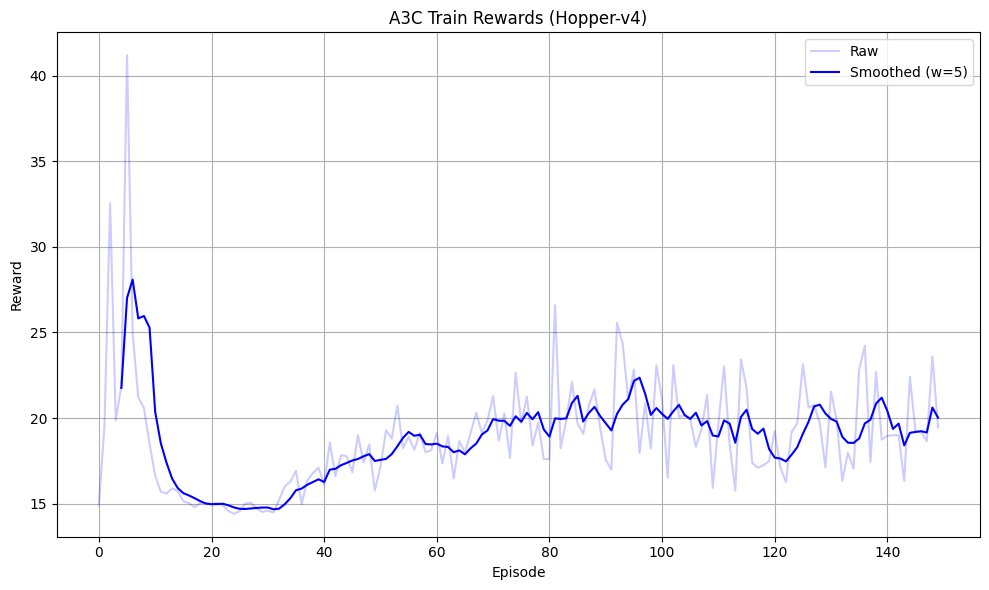

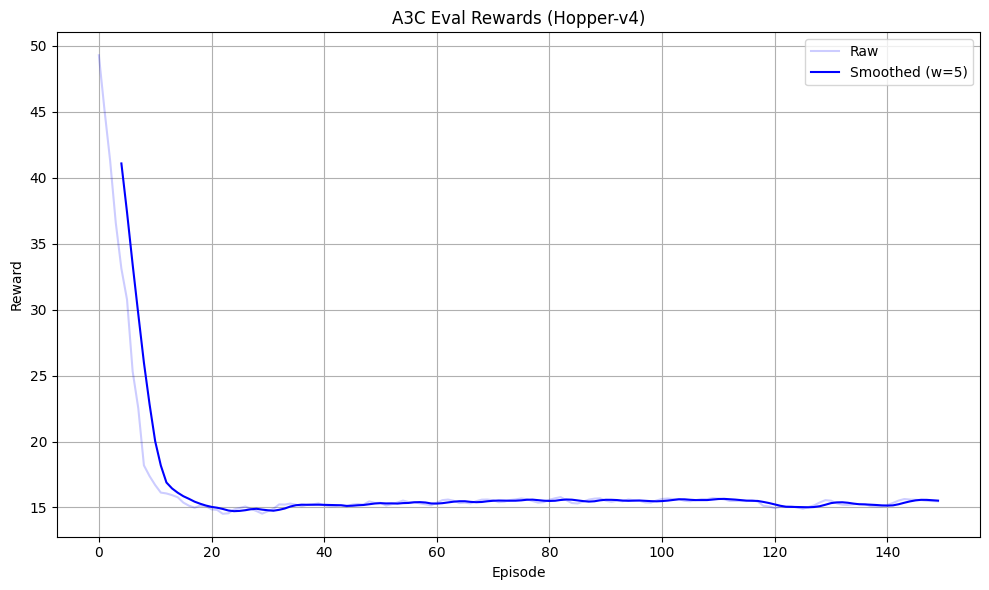

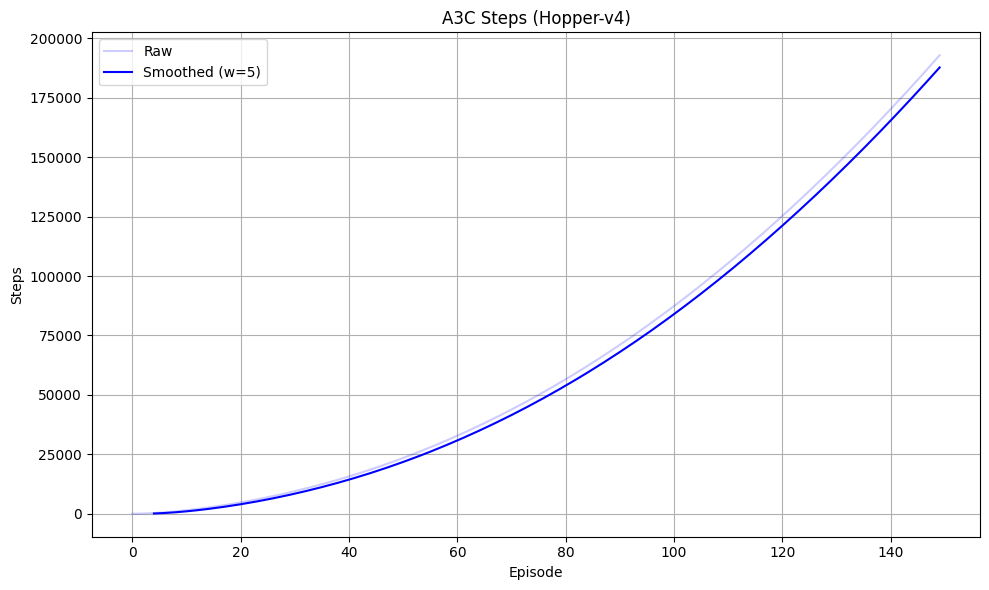

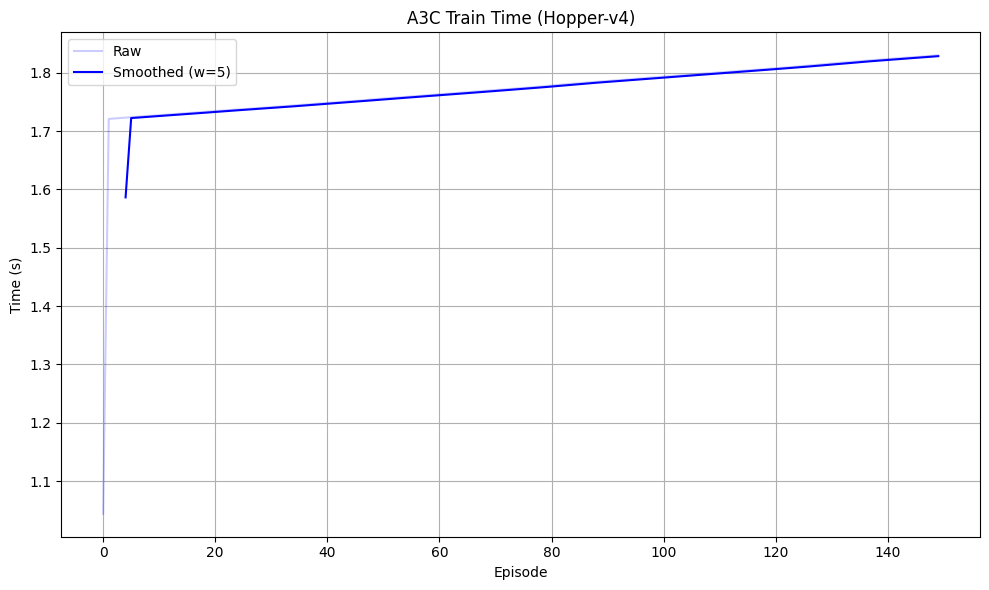

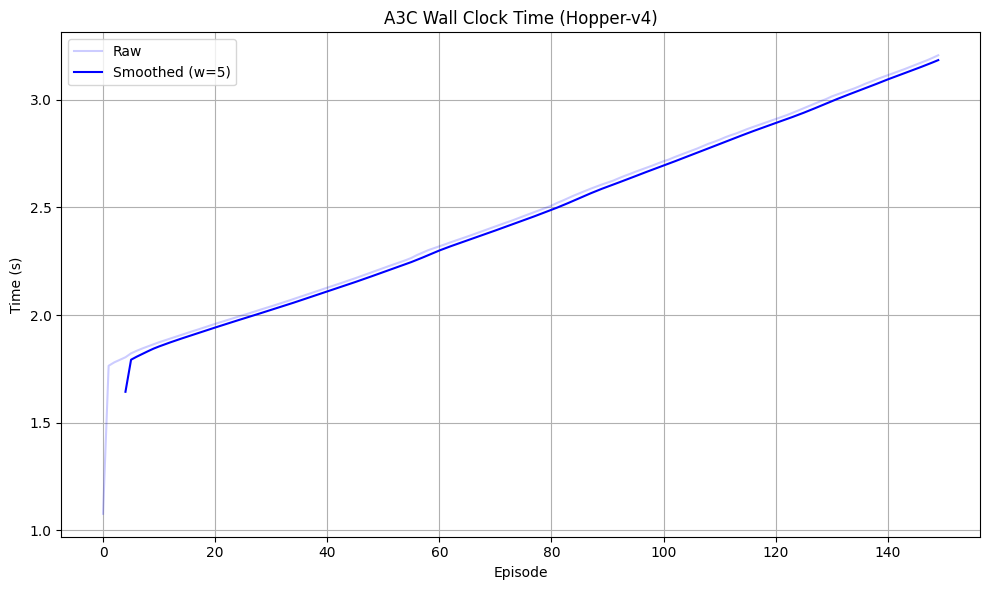

In [539]:
window = 5

for qty_idx, (title, ylabel) in enumerate([
    ('A3C Train Rewards (Hopper-v4)', 'Reward'),
    ('A3C Eval Rewards (Hopper-v4)', 'Reward'),
    ('A3C Steps (Hopper-v4)', 'Steps'),
    ('A3C Train Time (Hopper-v4)', 'Time (s)'),
    ('A3C Wall Clock Time (Hopper-v4)', 'Time (s)')
]):
    fig, ax = plt.subplots(figsize=(10, 6))
    raw = np.mean(np.array([agent_results['A3C'][run][qty_idx] for run in range(5)]), axis=0)
    smoothed = np.convolve(raw, np.ones(window)/window, mode='valid')
    ax.plot(raw, alpha=0.2, color='blue', label='Raw')
    ax.plot(range(window-1, len(raw)), smoothed, color='blue', label=f'Smoothed (w={window})')
    ax.set_title(title)
    ax.set_xlabel('Episode')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## A3C Questions [$10 \times 3 = 30$ marks]

### Q1. Why does A3C use asynchronous updates, and what benefit does this provide over synchronous (A2C) updates?


### Q2. What is the "stale gradient" problem in A3C and how does it affect learning?


### Q3. Compare A3C with DQN in terms of memory requirements and training paradigm.




- A1: A3C uses asynchronous update to overcome the idle time wasted by A2C workers. Also asynchronous architecture make it more exploratory than A2C. The original paper mentions that the asynchronous nature, provide a stabilizing effect on training.
- A2: The stale gradient problem is an outcome of the asynchronous nature, a worker may push an older gradient update, thus injecting noise/bias in the current state, which is changed.
- A3: A3C requires less memory in comparison to DQN as DQN uses a large replay buffer. In terms of training time, it is much faster than DQN. A3C is an actor-critic, on policy method whereas DQN is a value based, off policy method 

# Advantange Actor-Critic (A2C) [50 marks]
<a id="a2c"></a>

A2C is the synchronous, deterministic variant of A3C. Instead of using asynchronous workers, A2C waits for all parallel workers to finish their rollouts before performing a single gradient update. This makes it simpler to implement and often equally effective.

**Key ideas:**
- Uses an Actor-Critic architecture: the actor outputs a policy $\pi(a|s)$ and the critic estimates $V(s)$.
- The advantage $A(s,a) = R_t - V(s_t)$ (or using GAE) is used to reduce variance in the policy gradient.
- Multiple environments run in parallel (vectorized) and all updates are synchronous.
- The loss combines: policy gradient loss, value loss, and an entropy bonus for exploration.

**Policy Gradient with Advantage:**
$$\nabla_\theta J(\theta) = \mathbb{E}\left[\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot A(s_t, a_t)\right]$$

Implement the A2C agent using the class structure below.

```
class A2CAgent(nn.Module):
    def __init__(self, envs)
    def get_value(self, x)
    def get_action_and_value(self, x, action=None)

def train_a2c(env_id, seed, ...)
```


In [ ]:
# Import all the required libraries

In [523]:
# ======================================================================
# A2C Hyperparameters
# ======================================================================

a2c_gym_id = "Hopper-v4"     # Environment name
a2c_learning_rate = 3e-4
a2c_seed = 101

a2c_total_timesteps = 750000
a2c_num_envs = 4
a2c_num_steps = 128

a2c_gamma = 0.99
a2c_gae_lambda = 0.97
a2c_use_gae = True

a2c_ent_coef = 0.01
a2c_vf_coef = 0.5
a2c_max_grad_norm = 1
a2c_norm_adv = True

# Derived parameter
a2c_batch_size = a2c_num_envs * a2c_num_steps

OPTIMIZER_A2C = torch.optim.RMSprop
print(
    f"A2C: {a2c_total_timesteps//a2c_batch_size} gradient updates on {a2c_gym_id}"
)

A2C: 1464 gradient updates on Hopper-v4


In [447]:

class A2CAgent(nn.Module):
    def __init__(self, envs):
        super().__init__()
        env = envs[0]
        obs_dim = env.observation_space.shape[0]
        self.is_discrete = isinstance(env.action_space, gym.spaces.Discrete)
        act_dim = env.action_space.n if self.is_discrete else env.action_space.shape[0]
        hDim = [128, 128]

        critic_layers = [nn.Linear(obs_dim, hDim[0]), nn.ReLU()]
        for i in range(len(hDim)-1):
            critic_layers += [nn.Linear(hDim[i], hDim[i+1]), nn.ReLU()]
        critic_layers += [nn.Linear(hDim[-1], 1)]
        self.critic = nn.Sequential(*critic_layers)

        actor_layers = [nn.Linear(obs_dim, hDim[0]), nn.ReLU()]
        for i in range(len(hDim)-1):
            actor_layers += [nn.Linear(hDim[i], hDim[i+1]), nn.ReLU()]
        if self.is_discrete:
            actor_layers += [nn.Linear(hDim[-1], act_dim)]
        else:
            actor_layers += [nn.Linear(hDim[-1], act_dim*2)]
        self.actor = nn.Sequential(*actor_layers)

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        if self.is_discrete:
            logits = self.actor(x)
            dist = torch.distributions.Categorical(logits=logits)
            if action is None:
                action = dist.sample()
            return action, dist.log_prob(action), dist.entropy(), self.critic(x)
        else:
            out = self.actor(x)
            act_dim = out.shape[-1] // 2
            mu = torch.tanh(out[..., :act_dim])
            logstd = torch.clamp(out[..., act_dim:], -20, 2)
            sigma = torch.exp(logstd)
            dist = torch.distributions.Normal(mu, sigma)
            if action is None:
                action = dist.rsample()
            log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)
            entropy = dist.entropy().sum(dim=-1, keepdim=True)
            return action, log_prob, entropy, self.critic(x)

In [451]:
# ======================================================================
# A2C Worker + Training Loop (multiprocessing version)
# ======================================================================
# A2C is the SYNCHRONOUS counterpart to A3C:
#   - Worker processes each run their own environment and collect rollouts.
#   - After each rollout, workers WAIT at a barrier (synchronous).
#   - The main process computes GAE and does a SINGLE gradient update.
#   - A second barrier signals workers that weights have been updated.
# This barrier-based synchronisation is the key difference from A3C.
# ======================================================================

def a2c_worker(worker_id, global_agent,
               env_id, seed, num_steps, num_updates,
               shared_obs, shared_actions, shared_logprobs,
               shared_rewards, shared_dones, shared_values,
               shared_next_obs, shared_next_done,
               collect_barrier, update_barrier, ep_queue):
    """
    A2C worker process. Collects rollouts into shared memory buffers,
    then waits at a barrier for the main process to do a centralised update.

    Unlike A3C, this worker NEVER computes gradients or calls optimizer.step().
    The main process owns the gradient update exclusively.
    """
    torch.manual_seed(seed + worker_id)
    env = gym.make(env_id)
    env.reset(seed=seed + worker_id)
    is_discrete = isinstance(env.action_space, gym.spaces.Discrete)

    s, _ = env.reset()
    done = False
    ep_reward = 0.0
    ep_steps = 0

    for update in range(num_updates):
        for step in range(num_steps):
            s_t = torch.FloatTensor(s).reshape(1, -1)
            with torch.no_grad():
                action, log_p, _, value = global_agent.get_action_and_value(s_t)
            a = np.clip(action.detach().cpu().numpy().reshape(-1), env.action_space.low, env.action_space.high)
            s_next, r, term, trunc, _ = env.step(a)
            done = term or trunc
            ep_reward += r
            ep_steps += 1

            shared_obs[worker_id, step] = torch.FloatTensor(s)
            shared_actions[worker_id, step] = action.squeeze(0).detach()
            shared_logprobs[worker_id, step] = log_p.squeeze().detach()
            shared_rewards[worker_id, step] = r
            shared_dones[worker_id, step] = float(done)
            shared_values[worker_id, step] = value.squeeze().detach()

            s = s_next
            if done:
                ep_queue.put((worker_id, ep_reward, ep_steps))
                s, _ = env.reset()
                ep_reward = 0.0
                ep_steps = 0
                done = False
        shared_next_obs[worker_id] = torch.FloatTensor(s)
        shared_next_done[worker_id] = float(done)

        collect_barrier.wait()
        update_barrier.wait()

    env.close()


def train_a2c(env_id=a2c_gym_id, seed=a2c_seed, total_timesteps=a2c_total_timesteps,
              num_envs=a2c_num_envs, num_steps=a2c_num_steps, lr=a2c_learning_rate,
              gamma=a2c_gamma, gae_lambda=a2c_gae_lambda, use_gae=a2c_use_gae,
              ent_coef=a2c_ent_coef, vf_coef=a2c_vf_coef,  max_grad_norm=a2c_max_grad_norm, norm_adv=a2c_norm_adv): 

    envs = [gym.make(env_id) for _ in range(num_envs)]
    obs_dim = envs[0].observation_space.shape[0]
    is_discrete = isinstance(envs[0].action_space, gym.spaces.Discrete)
    act_dim = envs[0].action_space.n if is_discrete else envs[0].action_space.shape[0]
    for e in envs:
        e.close()

    global_agent = A2CAgent(envs)
    global_agent.share_memory()
    optimizer = OPTIMIZER_A2C(global_agent.parameters(), lr=lr)

    num_updates = total_timesteps // (num_envs * num_steps)

    shared_obs = torch.zeros(num_envs, num_steps, obs_dim).share_memory_()
    shared_actions = torch.zeros(num_envs, num_steps, act_dim).share_memory_()
    shared_logprobs = torch.zeros(num_envs, num_steps).share_memory_()
    shared_rewards = torch.zeros(num_envs, num_steps).share_memory_()
    shared_dones = torch.zeros(num_envs, num_steps).share_memory_()
    shared_values = torch.zeros(num_envs, num_steps).share_memory_()
    shared_next_obs = torch.zeros(num_envs, obs_dim).share_memory_()
    shared_next_done = torch.zeros(num_envs).share_memory_()

    collect_barrier = mp.Barrier(num_envs + 1)  
    update_barrier = mp.Barrier(num_envs + 1)
    ep_queue = mp.Queue()

    workers = []
    for worker_id in range(num_envs):
        p = mp.Process(
            target=a2c_worker,
            args=(worker_id, global_agent, env_id, seed, num_steps, num_updates, shared_obs, shared_actions, shared_logprobs,
                  shared_rewards, shared_dones, shared_values, shared_next_obs, shared_next_done, collect_barrier, update_barrier, ep_queue))
        p.start()
        workers.append(p)

    trainRewardList = []
    evalRewardList  = []
    stepList = []
    trainTimeList = []
    wallTimeList = []
    totalSteps = 0
    cumTrainTime = 0.0
    cumWallTime = 0.0
    ep_rewards_buffer = {w: [] for w in range(num_envs)}

    for update in range(num_updates):
        w_start = time.time()
        collect_barrier.wait()
        t_start = time.time()
        obs = shared_obs.reshape(-1, obs_dim)
        actions = shared_actions.reshape(-1, act_dim)
        logps_b = shared_logprobs.reshape(-1)
        rewards= shared_rewards.reshape(-1)
        dones = shared_dones.reshape(-1)
        values = shared_values.reshape(-1)
        with torch.no_grad():
            next_values = global_agent.get_value(shared_next_obs).squeeze(-1)

        if use_gae:
            advantages, returns = compute_gae(
                shared_rewards.T,
                shared_values.T,
                shared_dones.T,
                next_values.unsqueeze(0),
                gamma, gae_lambda
            )
            advantages = advantages.T.reshape(-1)
            returns = returns.T.reshape(-1)
        else:
            returns_list = []
            for w in range(num_envs):
                r_w, _ = getStepWiseReturnsAndDiscounts(gamma, shared_rewards[w].tolist())
                returns_list.append(r_w.squeeze())
            returns = torch.cat(returns_list)
            advantages = returns - values

        if norm_adv:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        _, new_logps, entropy, new_values = global_agent.get_action_and_value(obs, actions)
        new_logps = new_logps.squeeze()
        new_values= new_values.squeeze()
        entropy = entropy.squeeze()

        pLoss = torch.mean(-advantages.detach() * new_logps)
        vLoss = torch.mean(0.5 * (returns - new_values)**2)
        entropyLoss = -torch.mean(entropy)
        totalLoss = pLoss + vf_coef * vLoss + ent_coef * entropyLoss

        optimizer.zero_grad()
        totalLoss.backward()
        torch.nn.utils.clip_grad_norm_(global_agent.parameters(), max_grad_norm)
        optimizer.step()

        t_end = time.time()
        cumTrainTime += t_end - t_start
        totalSteps   += num_envs * num_steps
        update_barrier.wait()

        while not ep_queue.empty():
            worker_id, ep_r, ep_s = ep_queue.get()
            ep_rewards_buffer[worker_id].append(ep_r)

        w_end = time.time()
        cumWallTime += w_end - w_start

        if (update+1) % 30 == 0:
            all_rewards = [r for rs in ep_rewards_buffer.values() for r in rs]
            mean_r = np.mean(all_rewards) if all_rewards else 0.0
            print(f"Update {update+1}/{num_updates} | Steps: {totalSteps} | Mean Train Reward: {mean_r:.2f}")

    for p in workers:
        p.join()

    while not ep_queue.empty():
        worker_id, ep_r, ep_s = ep_queue.get()
        ep_rewards_buffer[worker_id].append(ep_r)

    max_eps = max(len(v) for v in ep_rewards_buffer.values())
    for ep in range(max_eps):
        ep_rs = [ep_rewards_buffer[w][ep] for w in range(num_envs) if ep < len(ep_rewards_buffer[w])]
        trainRewardList.append(np.mean(ep_rs))
        stepList.append(totalSteps)
        trainTimeList.append(cumTrainTime)
        wallTimeList.append(cumWallTime)

    return global_agent, trainRewardList, evalRewardList, stepList, trainTimeList, wallTimeList

In [524]:
a2c_module_code = '''
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gymnasium as gym
import time

def getStepWiseReturnsAndDiscounts(gamma, rewards):
    gammas = np.array([gamma**t for t in range(len(rewards))])
    returns = np.zeros(len(rewards))
    returns[-1] = rewards[-1]
    for i in range(len(rewards)-2, -1, -1):
        returns[i] = returns[i+1]*gamma + rewards[i]
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    returns = torch.FloatTensor(returns).unsqueeze(1)
    gammas = torch.FloatTensor(gammas).unsqueeze(1)
    return returns, gammas

def compute_gae(rewards, values, dones, next_value, gamma, gae_lambda):
    T = rewards.shape[0]
    advantages = torch.zeros_like(rewards)
    last_gae = torch.zeros_like(next_value)
    for t in reversed(range(T)):
        next_non_terminal = 1.0 - dones[t]
        next_val = next_value if t == T-1 else values[t+1]
        delta = rewards[t] + gamma * next_val * next_non_terminal - values[t]
        last_gae = delta + gamma * gae_lambda * next_non_terminal * last_gae
        advantages[t] = last_gae
    returns = advantages + values
    return advantages, returns

def evaluate_a2c_worker(local_agent, env_id, seed):
    env = gym.make(env_id)
    s, _ = env.reset(seed=seed)
    done = False
    tr = 0
    while not done:
        s_t = torch.FloatTensor(s).reshape(1, -1)
        with torch.no_grad():
            if local_agent.is_discrete:
                logits = local_agent.actor(s_t)
                action = torch.argmax(logits, dim=-1)
            else:
                out = local_agent.actor(s_t)
                act_dim = out.shape[-1] // 2
                action = torch.tanh(out[..., :act_dim])
        a = np.clip(action.detach().cpu().numpy().reshape(-1), env.action_space.low, env.action_space.high)
        s, r, term, trunc, _ = env.step(a)
        done = term or trunc
        tr += r
    env.close()
    return tr

class A2CAgent(nn.Module):
    def __init__(self, envs):
        super().__init__()
        env = envs[0]
        obs_dim = env.observation_space.shape[0]
        self.is_discrete = isinstance(env.action_space, gym.spaces.Discrete)
        act_dim = env.action_space.n if self.is_discrete else env.action_space.shape[0]
        hDim = [128, 128]

        critic_layers = [nn.Linear(obs_dim, hDim[0]), nn.ReLU()]
        for i in range(len(hDim)-1):
            critic_layers += [nn.Linear(hDim[i], hDim[i+1]), nn.ReLU()]
        critic_layers += [nn.Linear(hDim[-1], 1)]
        self.critic = nn.Sequential(*critic_layers)

        actor_layers = [nn.Linear(obs_dim, hDim[0]), nn.ReLU()]
        for i in range(len(hDim)-1):
            actor_layers += [nn.Linear(hDim[i], hDim[i+1]), nn.ReLU()]
        if self.is_discrete:
            actor_layers += [nn.Linear(hDim[-1], act_dim)]
        else:
            actor_layers += [nn.Linear(hDim[-1], act_dim*2)]
        self.actor = nn.Sequential(*actor_layers)

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        if self.is_discrete:
            logits = self.actor(x)
            dist = torch.distributions.Categorical(logits=logits)
            if action is None:
                action = dist.sample()
            return action, dist.log_prob(action), dist.entropy(), self.critic(x)
        else:
            out = self.actor(x)
            act_dim = out.shape[-1] // 2
            mu = torch.tanh(out[..., :act_dim])
            logstd = torch.clamp(out[..., act_dim:], -20, 2)
            sigma = torch.exp(logstd)
            dist = torch.distributions.Normal(mu, sigma)
            if action is None:
                action = dist.rsample()
            log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)
            entropy = dist.entropy().sum(dim=-1, keepdim=True)
            return action, log_prob, entropy, self.critic(x)

def a2c_worker(worker_id, global_agent,
               env_id, seed, num_steps, num_updates,
               shared_obs, shared_actions, shared_logprobs,
               shared_rewards, shared_dones, shared_values,
               shared_next_obs, shared_next_done,
               collect_barrier, update_barrier, ep_queue):
    torch.manual_seed(seed + worker_id)
    env = gym.make(env_id)
    env.reset(seed=seed + worker_id)

    s, _ = env.reset()
    done = False
    ep_reward = 0.0
    ep_steps = 0
    ep_train_time = 0.0
    ep_wall_time = 0.0
    w_start = time.time()
    episode_count = 0
    total_steps = 0

    for update in range(num_updates):
        for step in range(num_steps):
            s_t = torch.FloatTensor(s).reshape(1, -1)
            with torch.no_grad():
                action, log_p, _, value = global_agent.get_action_and_value(s_t)
            a = np.clip(action.detach().cpu().numpy().reshape(-1), env.action_space.low, env.action_space.high)
            s_next, r, term, trunc, _ = env.step(a)
            done = term or trunc
            ep_reward += r
            ep_steps += 1
            total_steps += 1

            shared_obs[worker_id, step] = torch.FloatTensor(s)
            shared_actions[worker_id, step] = action.squeeze(0).detach()
            shared_logprobs[worker_id, step] = log_p.squeeze().detach()
            shared_rewards[worker_id, step] = r
            shared_dones[worker_id, step] = float(done)
            shared_values[worker_id, step] = value.squeeze().detach()

            s = s_next
            if done:
                eval_reward = evaluate_a2c_worker(global_agent, env_id, seed + worker_id)
                w_end = time.time()
                ep_wall_time = w_end - w_start
                episode_count += 1
                ep_queue.put((worker_id, episode_count, ep_reward, eval_reward,
                              total_steps, ep_train_time, ep_wall_time))
                s, _ = env.reset()
                ep_reward = 0.0
                ep_steps = 0
                ep_train_time = 0.0
                w_start = time.time()
                done = False

        shared_next_obs[worker_id] = torch.FloatTensor(s)
        shared_next_done[worker_id] = float(done)

        collect_barrier.wait()
        update_barrier.wait()

    env.close()
'''

with open('a2c_worker_module.py', 'w', encoding='utf-8') as f:
    f.write(a2c_module_code)
print("a2c_worker_module.py written to:", __import__('os').getcwd())

a2c_worker_module.py written to: /Users/aryanarora/Desktop/rl/assign5


In [525]:
try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass

from a2c_worker_module import A2CAgent, a2c_worker, compute_gae, getStepWiseReturnsAndDiscounts

def train_a2c(env_id=a2c_gym_id, seed=a2c_seed, total_timesteps=a2c_total_timesteps,
              num_envs=a2c_num_envs, num_steps=a2c_num_steps, lr=a2c_learning_rate,
              gamma=a2c_gamma, gae_lambda=a2c_gae_lambda, use_gae=a2c_use_gae,
              ent_coef=a2c_ent_coef, vf_coef=a2c_vf_coef,
              max_grad_norm=a2c_max_grad_norm, norm_adv=a2c_norm_adv):
    envs = [gym.make(env_id) for _ in range(num_envs)]
    obs_dim = envs[0].observation_space.shape[0]
    is_discrete = isinstance(envs[0].action_space, gym.spaces.Discrete)
    act_dim = envs[0].action_space.n if is_discrete else envs[0].action_space.shape[0]
    for e in envs:
        e.close()

    global_agent = A2CAgent(envs)
    global_agent.share_memory()
    optimizer = torch.optim.Adam(global_agent.parameters(), lr=lr)

    num_updates = total_timesteps // (num_envs * num_steps)

    shared_obs = torch.zeros(num_envs, num_steps, obs_dim).share_memory_()
    shared_actions = torch.zeros(num_envs, num_steps, act_dim).share_memory_()
    shared_logprobs = torch.zeros(num_envs, num_steps).share_memory_()
    shared_rewards = torch.zeros(num_envs, num_steps).share_memory_()
    shared_dones = torch.zeros(num_envs, num_steps).share_memory_()
    shared_values = torch.zeros(num_envs, num_steps).share_memory_()
    shared_next_obs= torch.zeros(num_envs, obs_dim).share_memory_()
    shared_next_done = torch.zeros(num_envs).share_memory_()

    collect_barrier = mp.Barrier(num_envs + 1)
    update_barrier = mp.Barrier(num_envs + 1)
    ep_queue = mp.Queue()

    workers = []
    for worker_id in range(num_envs):
        p = mp.Process(
            target=a2c_worker,
            args=(worker_id, global_agent, env_id, seed, num_steps, num_updates, shared_obs, shared_actions, shared_logprobs,
                  shared_rewards, shared_dones, shared_values, shared_next_obs, shared_next_done, collect_barrier, update_barrier, ep_queue))
        p.start()
        workers.append(p)

    ep_rewards_buffer = {w: {"train": [], "eval": [], "steps": [], "train_time": [], "wall_time": []} for w in range(num_envs)}
    cumTrainTime = 0.0
    cumWallTime  = 0.0
    totalSteps   = 0

    for update in range(num_updates):
        w_start = time.time()
        collect_barrier.wait()

        t_start = time.time()
        obs = shared_obs.reshape(-1, obs_dim)
        actions = shared_actions.reshape(-1, act_dim)
        rewards= shared_rewards.reshape(-1)
        dones = shared_dones.reshape(-1)
        values = shared_values.reshape(-1)

        with torch.no_grad():
            next_values = global_agent.get_value(shared_next_obs).squeeze(-1)

        if use_gae:
            advantages, returns = compute_gae(
                shared_rewards.T,
                shared_values.T,
                shared_dones.T,
                next_values.unsqueeze(0),
                gamma, gae_lambda
            )
            advantages = advantages.T.reshape(-1)
            returns    = returns.T.reshape(-1)
        else:
            returns_list = []
            for w in range(num_envs):
                r_w, _ = getStepWiseReturnsAndDiscounts(gamma, shared_rewards[w].tolist())
                returns_list.append(r_w.squeeze())
            returns    = torch.cat(returns_list)
            advantages = returns - values

        if norm_adv:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        _, new_logps, entropy, new_values = global_agent.get_action_and_value(obs, actions)
        new_logps = new_logps.squeeze()
        new_values = new_values.squeeze()
        entropy = entropy.squeeze()

        pLoss = torch.mean(-advantages.detach() * new_logps)
        vLoss = torch.mean(0.5 * (returns - new_values)**2)
        entropyLoss = -torch.mean(entropy)
        totalLoss= pLoss + vf_coef * vLoss + ent_coef * entropyLoss

        optimizer.zero_grad()
        totalLoss.backward()
        torch.nn.utils.clip_grad_norm_(global_agent.parameters(), max_grad_norm)
        optimizer.step()

        t_end = time.time()
        cumTrainTime += t_end - t_start
        totalSteps += num_envs * num_steps

        update_barrier.wait()

        w_end = time.time()
        cumWallTime += w_end - w_start

        while not ep_queue.empty():
            worker_id, ep_num, ep_r, eval_r, ep_steps, ep_tr_t, ep_w_t = ep_queue.get()
            d = ep_rewards_buffer[worker_id]
            d["train"].append(ep_r)
            d["eval"].append(eval_r)
            d["steps"].append(totalSteps)
            d["train_time"].append(cumTrainTime)
            d["wall_time"].append(cumWallTime)

    for p in workers:
        p.join()

    while not ep_queue.empty():
        worker_id, ep_num, ep_r, eval_r, ep_steps, ep_tr_t, ep_w_t = ep_queue.get()
        d = ep_rewards_buffer[worker_id]
        d["train"].append(ep_r)
        d["eval"].append(eval_r)
        d["steps"].append(totalSteps)
        d["train_time"].append(cumTrainTime)
        d["wall_time"].append(cumWallTime)

    return global_agent, ep_rewards_buffer

In [526]:
for run in range(5):
    print(f"\n{'='*50}\nRun {run+1}/5 | Seed {a2c_seed+run}\n{'='*50}")
    global_agent, ep_rewards_buffer = train_a2c(seed=a2c_seed+run, use_gae=True)
    min_eps = min(len(ep_rewards_buffer[w]["train"]) for w in range(a2c_num_envs))
    trainRewardList = np.mean(np.array([ep_rewards_buffer[w]["train"][:min_eps] for w in range(a2c_num_envs)]), axis=0).tolist()
    evalRewardList = np.mean(np.array([ep_rewards_buffer[w]["eval"][:min_eps] for w in range(a2c_num_envs)]), axis=0).tolist()
    stepList = np.mean(np.array([ep_rewards_buffer[w]["steps"][:min_eps] for w in range(a2c_num_envs)]), axis=0).tolist()
    trainTimeList = np.mean(np.array([ep_rewards_buffer[w]["train_time"][:min_eps] for w in range(a2c_num_envs)]), axis=0).tolist()
    wallTimeList = np.mean(np.array([ep_rewards_buffer[w]["wall_time"][:min_eps] for w in range(a2c_num_envs)]), axis=0).tolist()
    agent_results["A2C"][run] = (trainRewardList, evalRewardList, stepList, trainTimeList, wallTimeList)
    print(f"Run {run+1} done — Final Eval Reward: {evalRewardList[-1]:.2f}")



Run 1/5 | Seed 101


/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

Run 1 done — Final Eval Reward: 172.19

Run 2/5 | Seed 102


/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

Run 2 done — Final Eval Reward: 370.44

Run 3/5 | Seed 103


...

Run 3 done — Final Eval Reward: 168.33

Run 4/5 | Seed 104


/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

Run 4 done — Final Eval Reward: 172.01

Run 5/5 | Seed 105


/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

Run 5 done — Final Eval Reward: 169.80


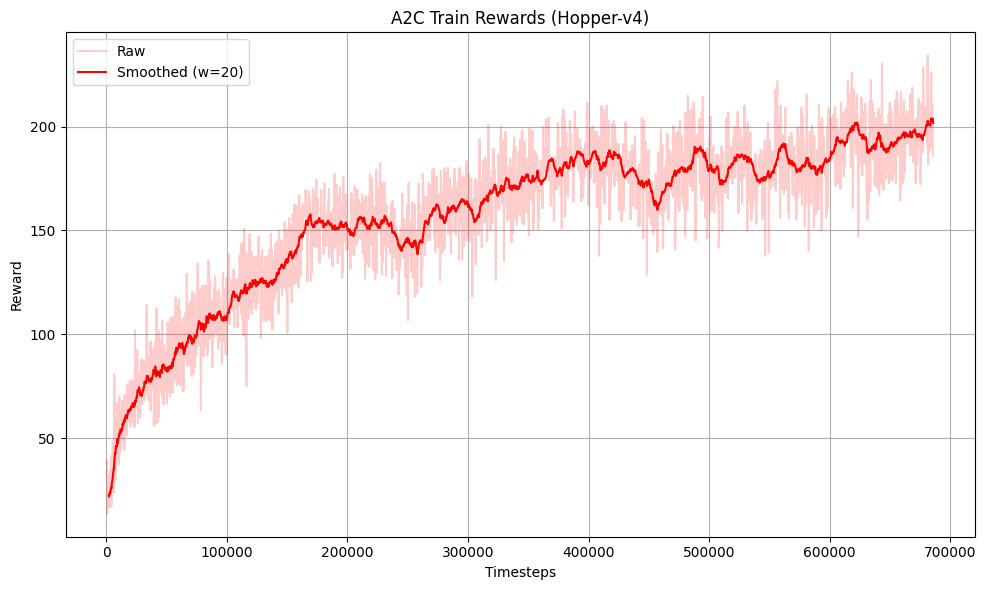

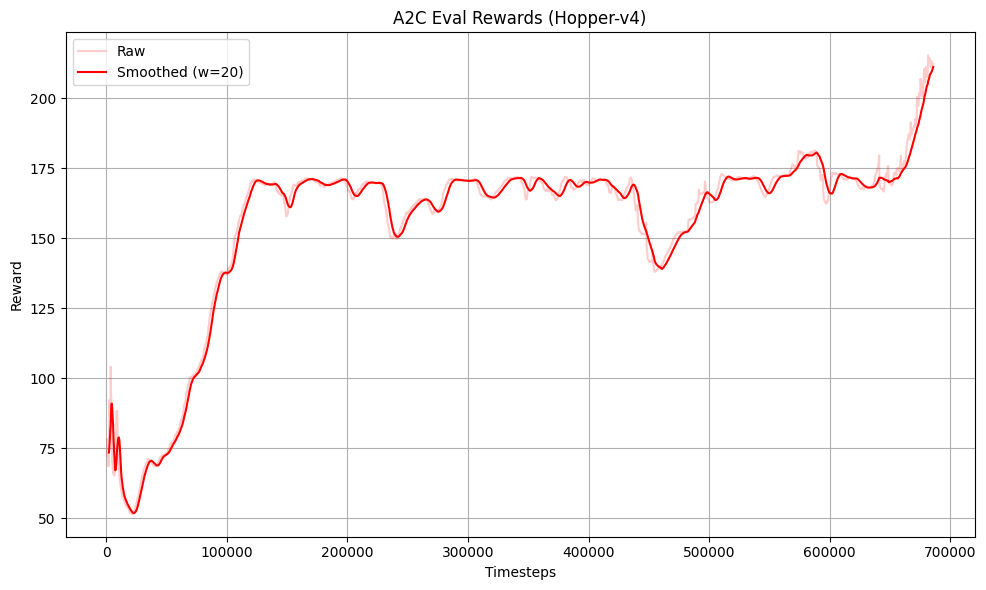

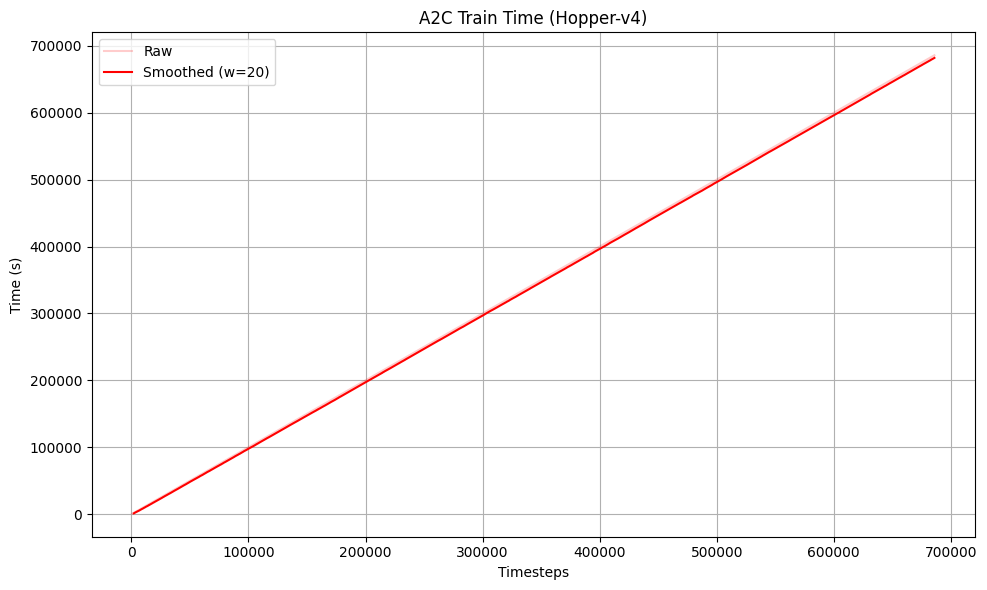

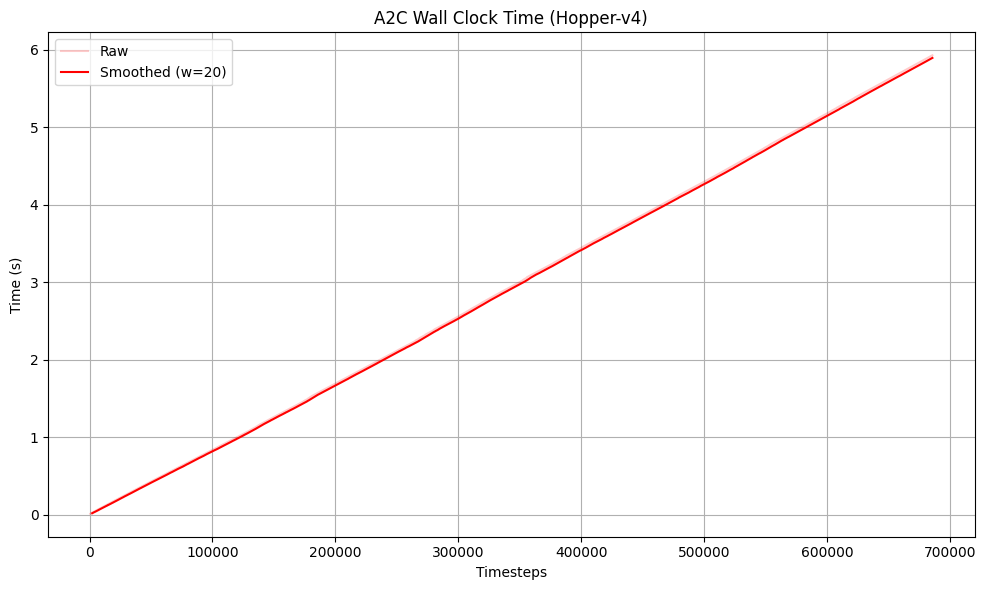

In [528]:
window = 20

for qty_idx, (title, ylabel) in enumerate([
    ('A2C Train Rewards (Hopper-v4)', 'Reward'),
    ('A2C Eval Rewards (Hopper-v4)', 'Reward'),
    ('A2C Train Time (Hopper-v4)', 'Time (s)'),
    ('A2C Wall Clock Time (Hopper-v4)', 'Time (s)')
]):
    fig, ax = plt.subplots(figsize=(10, 6))
    min_len = min(len(agent_results['A2C'][run][qty_idx]) for run in range(5))
    min_len_steps = min(len(agent_results['A2C'][run][2]) for run in range(5))
    min_len = min(min_len, min_len_steps)
    raw = np.mean(np.array([agent_results['A2C'][run][qty_idx][:min_len] for run in range(5)]), axis=0)
    steps = np.mean(np.array([agent_results['A2C'][run][2][:min_len] for run in range(5)]), axis=0)
    smoothed = np.convolve(raw, np.ones(window)/window, mode='valid')
    steps_smoothed = steps[window-1:]
    ax.plot(steps, raw, alpha=0.2, color='red', label='Raw')
    ax.plot(steps_smoothed, smoothed, color='red', label=f'Smoothed (w={window})')
    ax.set_title(title)
    ax.set_xlabel('Timesteps')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## A2C Questions [$10 \times 4 = 40$ marks ]

### Q1. What is the advantage function in A2C and why is it used instead of raw returns?



### Q2. How does A2C differ from REINFORCE?



### Q3. Why does A2C use RMSprop instead of Adam, and does the choice matter?



### Q4. Experiment: Compare A2C with different numbers of parallel environments (num_envs = 1, 4, 8, 16). What do you observe?



- A1: The advantage function is defined as follows : A(s,a) = Return - V(S). It centers the target around V(s), thus reducing variance, as returns can be noisy. It also helps in assigning the 'goodness' of an action over another in a given state
- A2: REINFORCE relies on full trajectory returns making it more variate, whereas A2C uses bootstrapped estimates of advantage function, thus it has lower variance but higher bias. REINFORCE is a pure policy gradient based method, whereas A2C is an actor-critic method.
- A3: RMS is preferred since it gives more stable updates in noisy settings, and since A2C is an on policy method with multiple workers it can be noisy.
- A4: 

# Generalized Advantage Estimation (GAE) [50 marks]
<a id="gae"></a>

GAE (Schulman et al., 2016) provides a principled way to balance bias and variance in advantage estimation through a single parameter $\lambda \in [0, 1]$.

**The core idea:**

The 1-step advantage (TD error) is: $\delta_t^V = r_t + \gamma V(s_{t+1}) - V(s_t)$

The GAE advantage is an exponentially-weighted average of multi-step advantages:
$$\hat{A}_t^{\text{GAE}(\gamma, \lambda)} = \sum_{l=0}^{\infty} (\gamma \lambda)^l \delta_{t+l}^V$$

This can be computed recursively:
$$\hat{A}_t = \delta_t + \gamma \lambda \hat{A}_{t+1}$$

**Special cases:**
- $\lambda = 0$: GAE reduces to the 1-step TD advantage $\delta_t^V$ → **low variance, high bias**
- $\lambda = 1$: GAE reduces to the full Monte Carlo advantage → **high variance, low bias**
- $0 < \lambda < 1$: Smooth interpolation between the two extremes

Below we implement a standalone GAE module and demonstrate how different values of $\lambda$ affect learning performance.


In [439]:
# ======================================================================
# GAE Implementation (standalone module)
# ======================================================================

def compute_gae(rewards, values, dones, next_value, gamma, gae_lambda):
    """
    Computes Generalized Advantage Estimation.

    Args:
        rewards    : tensor of shape (T, num_envs) - rewards at each timestep
        values     : tensor of shape (T, num_envs) - V(s_t) predictions
        dones      : tensor of shape (T, num_envs) - done flags
        next_value : tensor of shape (1, num_envs) - V(s_{T}) bootstrap value
        gamma      : discount factor
        gae_lambda : GAE lambda parameter (0=TD, 1=MC)

    Returns:
        advantages : tensor of shape (T, num_envs)
        returns    : tensor of shape (T, num_envs)
    """
    T = rewards.shape[0]
    advantages = torch.zeros_like(rewards)
    last_gae = torch.zeros_like(next_value)
    for t in reversed(range(T)):
        next_non_terminal = 1.0 - dones[t]
        next_val = next_value if t == T - 1 else values[t + 1]
        delta = rewards[t] + gamma * next_val * next_non_terminal - values[t]
        last_gae = delta + gamma * gae_lambda * next_non_terminal * last_gae
        advantages[t] = last_gae
    returns = advantages + values
    return advantages, returns

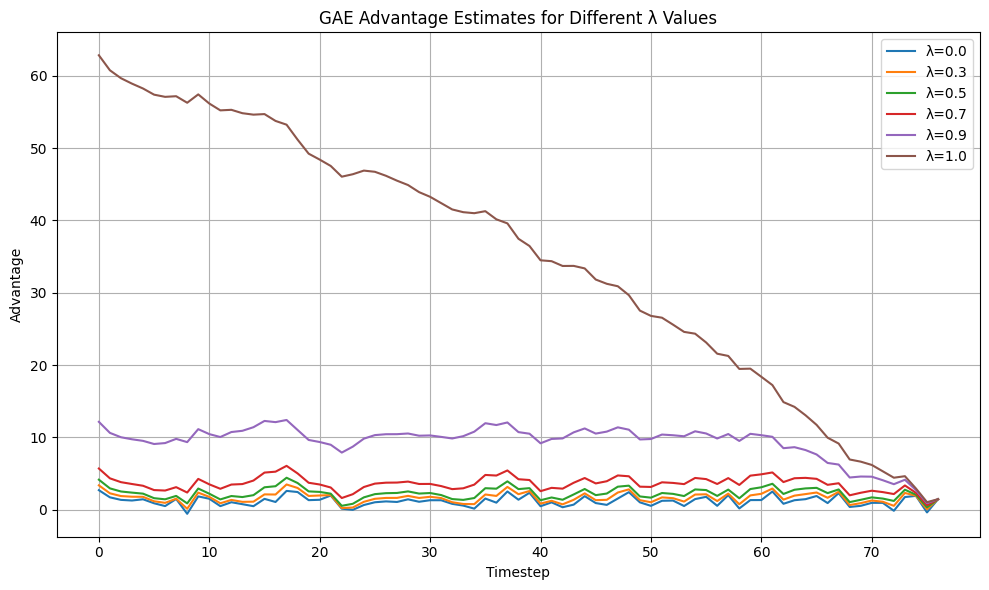

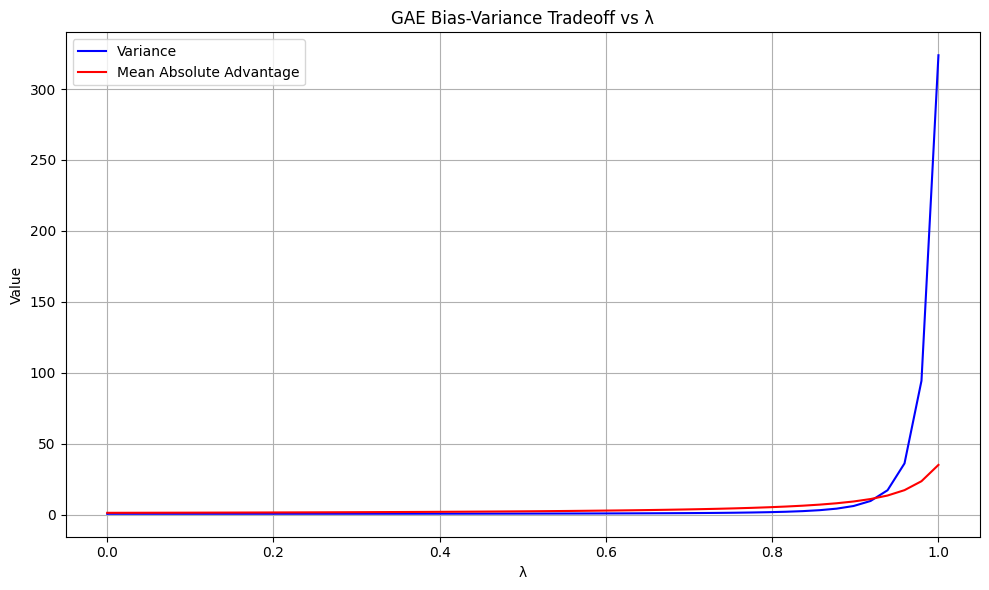

In [443]:
T = 77
torch.manual_seed(101)
np.random.seed(101)

rewards = torch.FloatTensor(np.random.randn(T, 1) * 0.7 + 1.0)
values = torch.FloatTensor(np.cumsum(np.random.randn(T, 1) * 0.2, axis=0))
dones = torch.zeros(T, 1)
dones[-1] = 1.0
next_value = torch.zeros(1, 1)
gamma = 0.99

lambdas = [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]

fig, ax = plt.subplots(figsize=(10, 6))
for lam in lambdas:
    advantages, _ = compute_gae(rewards, values, dones, next_value, gamma, lam)
    ax.plot(advantages.numpy(), label=f'λ={lam}')
ax.set_title('GAE Advantage Estimates for Different λ Values')
ax.set_xlabel('Timestep')
ax.set_ylabel('Advantage')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

lambda_sweep = np.linspace(0, 1, 50)
variances = []
mean_abs = []

for lam in lambda_sweep:
    advantages, _ = compute_gae(rewards, values, dones, next_value, gamma, float(lam))
    variances.append(advantages.var().item())
    mean_abs.append(advantages.abs().mean().item())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lambda_sweep, variances, color='blue', label='Variance')
ax.plot(lambda_sweep, mean_abs, color='red', label='Mean Absolute Advantage')
ax.set_title('GAE Bias-Variance Tradeoff vs λ')
ax.set_xlabel('λ')
ax.set_ylabel('Value')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [530]:
lambdas = [0.1, 0.3, 0.5, 0.7, 0.9, 0.97]
gae_sweep_results = {}
a2c_num_envs = 4
a2c_total_timesteps = 250000
for lam in lambdas:
    print(f"Training A2C with λ={lam}")
    global_agent, ep_rewards_buffer = train_a2c(seed=a2c_seed, use_gae=True, gae_lambda=lam)
    min_eps = min(len(ep_rewards_buffer[w]["train"]) for w in range(a2c_num_envs))
    trainRewardList = np.mean(np.array([ep_rewards_buffer[w]["train"][:min_eps] for w in range(a2c_num_envs)]), axis=0).tolist()
    evalRewardList = np.mean(np.array([ep_rewards_buffer[w]["eval"][:min_eps] for w in range(a2c_num_envs)]), axis=0).tolist()
    stepList = np.mean(np.array([ep_rewards_buffer[w]["steps"][:min_eps] for w in range(a2c_num_envs)]), axis=0).tolist()
    trainTimeList = np.mean(np.array([ep_rewards_buffer[w]["train_time"][:min_eps] for w in range(a2c_num_envs)]), axis=0).tolist()
    wallTimeList = np.mean(np.array([ep_rewards_buffer[w]["wall_time"][:min_eps] for w in range(a2c_num_envs)]), axis=0).tolist()
    gae_sweep_results[lam] = (trainRewardList, evalRewardList, stepList, trainTimeList, wallTimeList)
    agent_results['GAE'][lam] = (trainRewardList, evalRewardList, stepList, trainTimeList, wallTimeList)
    print(f"λ={lam} done")


Training A2C with λ=0.1


/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

λ=0.1 done
Training A2C with λ=0.3


/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

λ=0.3 done
Training A2C with λ=0.5


...

λ=0.7 done
Training A2C with λ=0.9


/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

λ=0.9 done
Training A2C with λ=0.97


/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-pa

λ=0.97 done


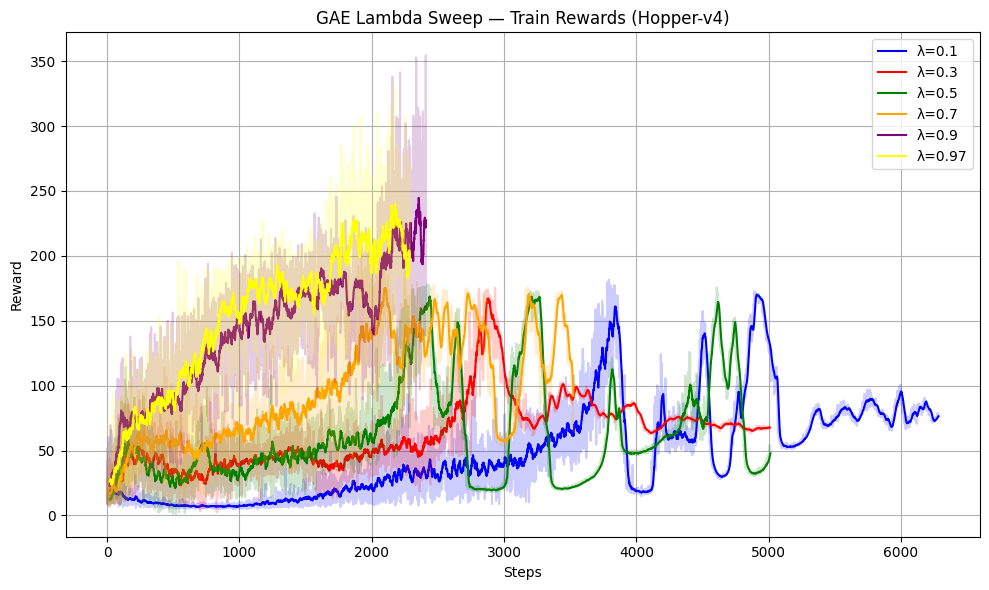

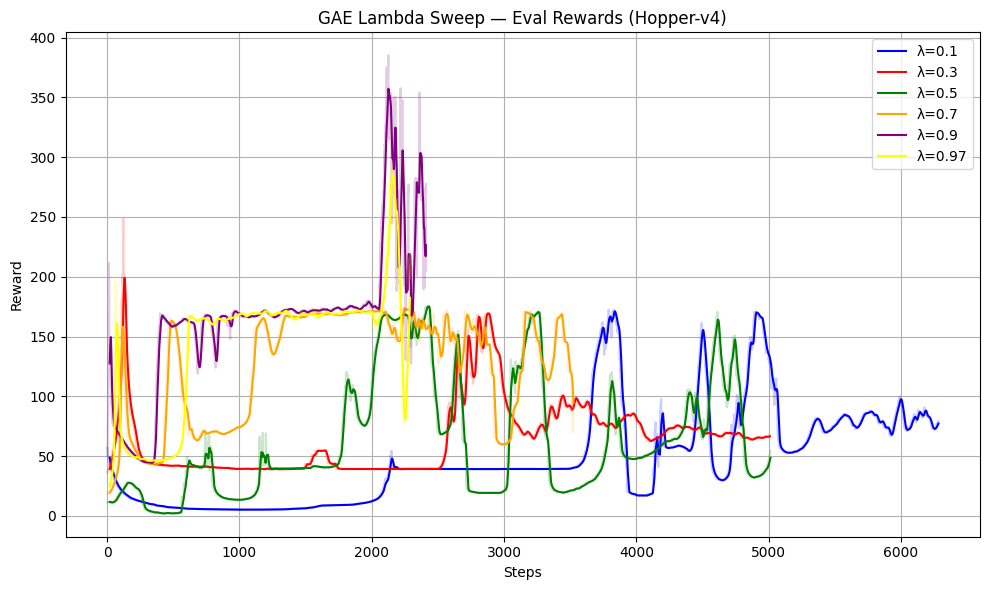

In [542]:
window = 20
colors = ['blue', 'red', 'green', 'orange', 'purple', 'yellow']

for qty_idx, (title, ylabel) in enumerate([
    ('GAE Lambda Sweep — Train Rewards (Hopper-v4)', 'Reward'),
    ('GAE Lambda Sweep — Eval Rewards (Hopper-v4)', 'Reward'),
]):
    fig, ax = plt.subplots(figsize=(10, 6))
    for lam, color in zip(lambdas, colors):
        raw = np.array(gae_sweep_results[lam][qty_idx])
        smoothed = np.convolve(raw, np.ones(window)/window, mode='valid')
        ax.plot(raw, alpha=0.2, color=color)
        ax.plot(range(window-1, len(raw)), smoothed, color=color, label=f'λ={lam}')
    ax.set_title(title)
    ax.set_xlabel('Steps')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


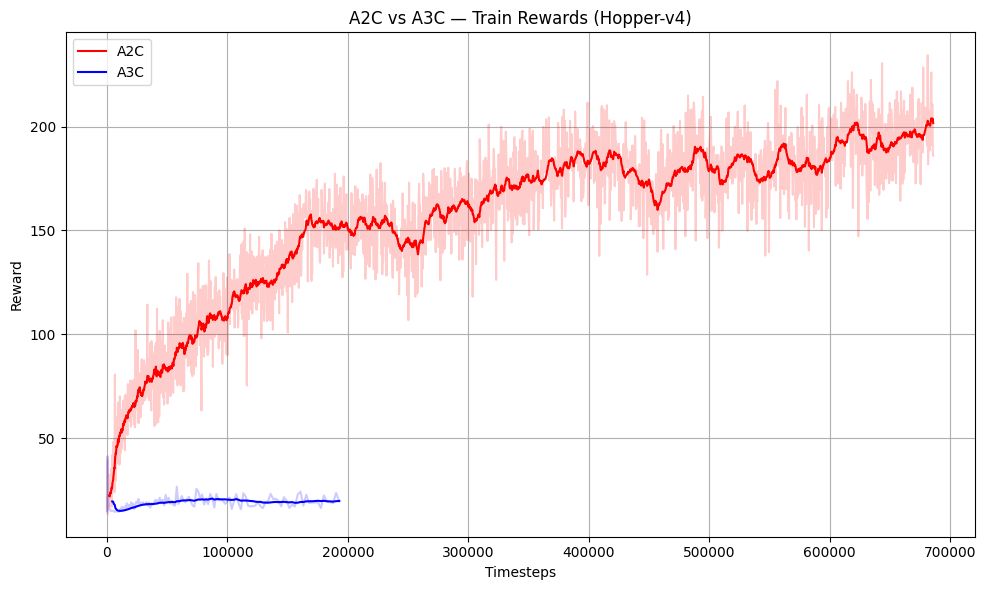

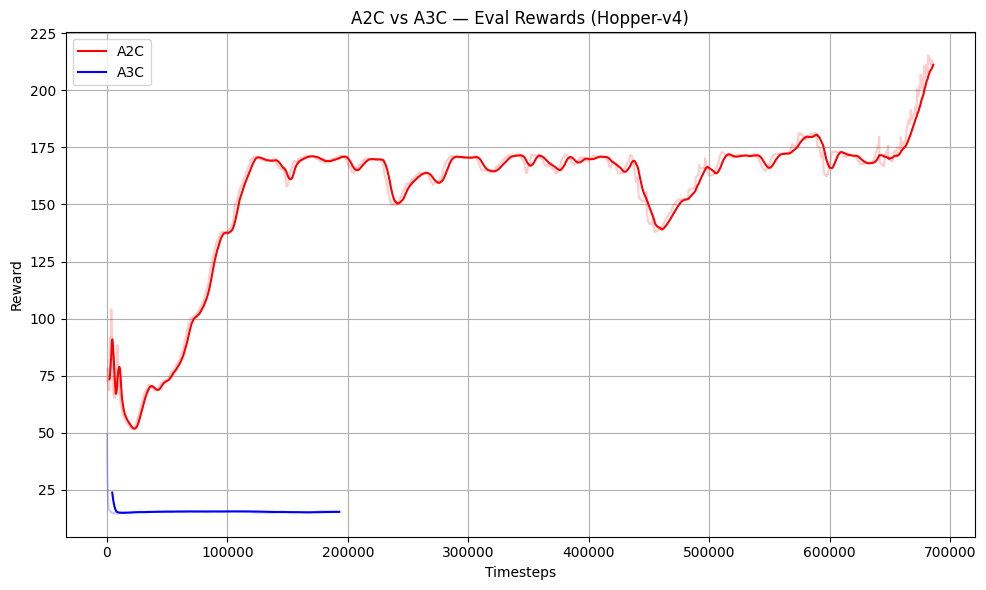

In [543]:
window = 20

for qty_idx, (title, ylabel) in enumerate([
    ('Train Rewards (Hopper-v4)', 'Reward'),
    ('Eval Rewards (Hopper-v4)', 'Reward')
]):
    fig, ax = plt.subplots(figsize=(10, 6))

    for key, color in [('A2C', 'red'), ('A3C', 'blue')]:
        min_len = min(len(agent_results[key][run][qty_idx]) for run in range(5))
        min_len_steps = min(len(agent_results[key][run][2]) for run in range(5))
        min_len = min(min_len, min_len_steps)
        raw = np.mean(np.array([agent_results[key][run][qty_idx][:min_len] for run in range(5)]), axis=0)
        steps = np.mean(np.array([agent_results[key][run][2][:min_len] for run in range(5)]), axis=0)
        smoothed = np.convolve(raw, np.ones(window)/window, mode='valid')
        steps_smoothed = steps[window-1:]
        ax.plot(steps, raw, alpha=0.2, color=color)
        ax.plot(steps_smoothed, smoothed, color=color, label=key)

    ax.set_title(f'A2C vs A3C — {title}')
    ax.set_xlabel('Timesteps')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## GAE Questions [$10 \times 4 = 40$ marks]

### Q1. Derive the GAE formula starting from multi-step advantage estimates.



### Q2. What happens at the extreme values of λ, and what is a good practical default?



### Q3. From the GAE lambda sweep experiment, which lambda values perform best and why?



### Q4. How does GAE relate to TD(λ) from tabular RL?



- A1:

TD residual:
$$\delta_t^V = r_t + \gamma V(s_{t+1}) - V(s_t)$$

$k$-step estimator: 
$$\hat A_t^{(k)} = \sum_{l=0}^{k-1} \gamma^l r_{t+l} + \gamma^k V(s_{t+k}) - V(s_t)$$

$k$-step estimator as a sum of TD residuals:
$$\hat A_t^{(k)} = \sum_{l=0}^{k-1} \gamma^l \delta_{t+l}^V$$

GAE is the exponentially weighted average of these $k$-step estimators:
$$\hat A_t^{\mathrm{GAE}(\gamma,\lambda)} = (1-\lambda)\sum_{k=1}^{\infty}\lambda^{k-1}\hat A_t^{(k)}$$

Substituting the residual sum:
$$\hat A_t^{\mathrm{GAE}(\gamma,\lambda)} = (1-\lambda)\sum_{k=1}^{\infty}\lambda^{k-1} \left(\sum_{l=0}^{k-1}\gamma^l \delta_{t+l}^V\right)$$

This simplifies to :
$$\hat A_t^{\mathrm{GAE}(\gamma,\lambda)} = \sum_{l=0}^{\infty} (\gamma\lambda)^l \delta_{t+l}^V$$



- A2: At extreme values of lambda i.e. 0 or 1, At 0 GAE apporaches the TD(0) estimate whereas as it approaches 1 it approaches Monte Carlo Estimate (full Trajectory). Good practical default is  0.95
- A3: 0.9 and 0.97 reach higher reward 
- A4: Similar to TD(lambda), GAE uses the lambda parameter to control the variance and bias while learning 

# Deep Deterministic Policy Gradient (DDPG) [50 marks]
<a id="ddpg"></a>

Implement the Deep Deterministic Policy Gradient (DDPG) agent. We have studied about DDPG agent in the Lecture. Use the function definitions (given below).

This class implements the DDPG agent, you are required to implement the various methods of this class
as outlined below. Note this class is generic and should work with any permissible Gym environment

```
class DDPG():
    def init(self, env, seed, gamma, tau, bufferSize, batch_size, updateFrequency,
             policyOptimizerFn, valueOptimizerFn,
             policyOptimizerLR,valueOptimizerLR,
             MAX_TRAIN_EPISODES,MAX_EVAL_EPISODE,
             optimizerFn)
    
    def runDDPG(self)
    def trainAgent(self)
    def gaussianStrategy(self, net , s , envActionRange , noiseScaleRatio,
        explorationMax = True)
    def greedyStrategy(self, net , s , envActionRange)
    def trainNetworks(self, experiences)
    def updateNetworks(self, onlineNet, targetNet, tau)
    def evaluateAgent(self)




```

In [360]:
class DDPG():
    def __init__(self, env, seed, gamma, tau, bufferSize, batch_size, updateFrequency,
             policyOptimizerFn, valueOptimizerFn,
             policyOptimizerLR,valueOptimizerLR,
             MAX_TRAIN_EPISODES , MAX_EVAL_EPISODES, hDim = [128, 128, 128], activation=F.relu):
        #this DDPG method
        # 1. creates and initilizes (with seed) the environment, train/eval episodes, gamma, etc.
        # 2. creates and intializes all the variables required for book-keeping values via the initBookKeeping method
        # 3. creates targetValueNetwork , targetPolicyNetwork
        # 4. creates and initializes (with network params) the optimizer function
        # 5. creates onlineValueNetwork, onlinePolicyNetwork
        # 6. Creates the replayBuffer

        #Your code goes in here
        self.env = env
        self.env.reset(seed=seed)
        self.gamma = gamma
        self.tau = tau 
        self.max_train_ep = MAX_TRAIN_EPISODES
        self.max_eval_ep = MAX_EVAL_EPISODES
        self.batch_size = batch_size
        self.updateFrequency = updateFrequency
        inDim = env.observation_space.shape[0]
        outDim = env.action_space.shape[0] * 2
        self.scale = float(env.action_space.high[0])
        
        self.pNetTarget = createPolicyNetwork(inDim,outDim,hDim=hDim, activation=activation)
        self.pNetOnline = createPolicyNetwork(inDim,outDim,hDim=hDim, activation=activation)
        self.pNetTarget.load_state_dict(self.pNetOnline.state_dict())
        self.vNetOnline = createValueNetwork(inDim, 1, outDim//2, hDim=hDim, activation=activation)
        self.vNetTarget = createValueNetwork(inDim, 1, outDim//2, hDim=hDim, activation=activation)
        self.vNetTarget.load_state_dict(self.vNetOnline.state_dict())
        self.pOptimizer = policyOptimizerFn(self.pNetOnline.parameters(), lr = policyOptimizerLR)
        self.vOptimizer = valueOptimizerFn(self.vNetOnline.parameters(), lr = valueOptimizerLR)
        self.buffer = ReplayBuffer(bufferSize, batch_size, seed)
        self.initBookKeeping()


In [361]:
class DDPG(DDPG): 
    def initBookKeeping(self): 
        self.trainRewardList = []
        self.evalRewardList = []
        self.stepList = []
        self.totalSteps = 0
        self.trainTimeList = []
        self.wallTimeList = []
        self.currentTrainReward = 0
        self.currentEvalReward = 0
        self.currentTrainTime = 0
        self.currentWallTime = 0

In [362]:
class DDPG(DDPG): 
    def performBookKeeping(self, train = True):
        if not train: 
            self.evalRewardList.append(self.currentEvalReward)
            return
        self.stepList.append(self.totalSteps)
        self.trainTimeList.append(self.currentTrainTime)
        self.wallTimeList.append(self.currentWallTime)
        self.trainRewardList.append(self.currentTrainReward)
        

In [363]:
class DDPG(DDPG):
    def updateNetworks(self, onlineNet, targetNet, tau):
        for o_p, t_p in zip(onlineNet.parameters() ,targetNet.parameters()):
            t_p.data.copy_(o_p.data * tau + (1-tau)*t_p.data)
            


In [364]:
class DDPG(DDPG):
    def gaussianStrategy (self, net , s , envActionRange , noiseScaleRatio , explorationMax = True ):
        action_low, action_high = envActionRange
        if explorationMax:
            sc = action_high
        else:
            sc = noiseScaleRatio * action_high
        greedyAction = net.selectGreedyAction(s, self.scale)
        noise = np.random.normal(0, sc, size=len(action_high))
        action = greedyAction + noise
        return np.clip(action, action_low, action_high)


In [365]:
class DDPG(DDPG):
    def greedyStrategy (self, net , s , envActionRange ):
        action_low, action_high = envActionRange
        action = net.selectGreedyAction(s, self.scale)
        return np.clip(action, action_low, action_high)


In [366]:
class DDPG(DDPG):
    def runDDPG (self):
        self.trainAgent()
        return self.trainRewardList,self.evalRewardList, self.stepList, self.trainTimeList, self.wallTimeList, self.currentEvalReward


In [367]:

class DDPG(DDPG):
    def trainAgent(self):
        action_range = (self.env.action_space.low, self.env.action_space.high)
        for e in range(self.max_train_ep):
            w_start = time.time()
            state, _ = self.env.reset()
            done = False
            tr = 0
            t_start = time.time()
            while not done:
                action = self.gaussianStrategy(self.pNetOnline, state, action_range, noiseScaleRatio, explorationMax=(self.buffer.length() < minSamples))
                next_state, reward, term, trunc, _ = self.env.step(action)
                done = term or trunc
                self.buffer.store(state, action, reward, next_state, done)
                state = next_state
                tr += reward
                self.totalSteps += 1
                if self.buffer.length() >= minSamples:
                    experiences = self.buffer.sample(self.batch_size)
                    self.trainNetwork(experiences)
                if self.totalSteps % self.updateFrequency == 0:
                    self.updateNetworks(self.pNetOnline, self.pNetTarget, self.tau)
                    self.updateNetworks(self.vNetOnline, self.vNetTarget, self.tau)
                

            t_end = time.time()
            self.currentTrainTime += (t_end - t_start)
            self.currentTrainReward = tr
            self.evaluateAgent()
            
                
            w_end = time.time()
            self.currentWallTime += (w_end - w_start)
            self.performBookKeeping()
            if (e+1) % LOG_EVERY == 0: 
                print(f"Episode: {e+1}, Eval Reward: {self.currentEvalReward}, Train Reward: {self.currentTrainReward}")

        return self.trainRewardList, self.trainTimeList, self.evalRewardList, self.wallTimeList


In [368]:
class DDPG(DDPG):
    def trainNetwork(self, experiences):
        states = torch.FloatTensor(np.array([exp[0] for exp in experiences])).to(device)
        actions = torch.FloatTensor(np.array([exp[1] for exp in experiences])).to(device)
        rewards = torch.FloatTensor(np.array([exp[2] for exp in experiences])).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array([exp[3] for exp in experiences])).to(device)
        dones = torch.FloatTensor(np.array([exp[4] for exp in experiences])).unsqueeze(1).to(device)
        with torch.no_grad():
            next_mu, _ = self.pNetTarget(next_states)
            next_actions = next_mu * self.scale
            next_q = self.vNetTarget(next_states, next_actions)
            target_q = rewards + self.gamma * next_q * (1 - dones)
        q = self.vNetOnline(states, actions)
        error = target_q.detach() - q
        vLoss = (0.5 * (error)**2).mean()
        self.vOptimizer.zero_grad()
        vLoss.backward()
        torch.nn.utils.clip_grad_norm_(self.vNetOnline.parameters(), 1.0)
        self.vOptimizer.step()
        pred_mu, _ = self.pNetOnline(states)
        pred_actions = pred_mu * self.scale
        pLoss = -1.0 * self.vNetOnline(states, pred_actions).mean()
        self.pOptimizer.zero_grad()
        pLoss.backward()
        torch.nn.utils.clip_grad_norm_(self.pNetOnline.parameters(), 1.0)
        self.pOptimizer.step()

In [369]:
class DDPG(DDPG):
    def evaluateAgent(self):
        rewards = []
        action_range = (self.env.action_space.low, self.env.action_space.high)
        for e in range(self.max_eval_ep):
            rs = 0
            state, _ = self.env.reset()
            done = False
            while not done:
                a = self.greedyStrategy(self.pNetOnline, state, action_range)
                state, r, term, trunc, _ = self.env.step(a)
                rs += r
                done = term or trunc
            rewards.append(rs)
        self.currentEvalReward = np.mean(rewards)
        self.performBookKeeping(train=False)

# Twin-Delayed Deep Deterministic Policy Gradient (TD3) [50 marks]
<a id="td3"></a>

Implement the Twin-delayed deep deterministic policy gradient (TD3) agent. We have studied about TD3 agent in the Lecture. Use the function definitions (given below).

This class implements the TD3 agent, you are required to implement the various methods of this class
as outlined below. Note this class is generic and should work with any permissible Gym environment

```
class DDPG():
    def init(env, gamma, tau,
    bufferSize ,
    updateFrequencyPolicy ,
    updateFrequencyValue ,
    trainPolicyFrequency ,
    policyOptimizerFn ,
    valueOptimizerFn ,
    policyOptimizerLR ,
    valueOptimizerLR ,
    MAX TRAIN EPISODES,
    MAX EVAL EPISODE,
    optimizerFn )
    
    def runTD3 (self)
    def trainAgent (self)
    def gaussianStrategy (self, net , s , envActionRange , noiseScaleRatio ,
        explorationMax = True)
    def greedyStrategy (self, net , s , envActionRange)
    def trainNetworks (self,experiences , envActionRange)
    def updateValueNetwork(self, onlineNet, targetNet, tau)
    def updatePolicyNetwork(self, onlineNet, targetNet, tau)
    def evaluateAgent (self)



```

In [370]:
class TD3():
    def __init__(self,env, gamma, tau,
    bufferSize , batch_size,
    updateFrequencyPolicy ,
    updateFrequencyValue ,
    trainPolicyFrequency ,
    policyOptimizerFn ,
    valueOptimizerFn ,
    policyOptimizerLR ,
    valueOptimizerLR ,
    MAX_TRAIN_EPISODES,
    MAX_EVAL_EPISODE,
    hDim=[256,256], activation = F.relu , seed = 101):

        self.env = env
        self.env.reset(seed=seed)
        self.gamma = gamma
        self.tau = tau
        self.max_train_ep = MAX_TRAIN_EPISODES
        self.max_eval_ep = MAX_EVAL_EPISODE
        self.pUpdateFreq = updateFrequencyPolicy
        self.vUpdateFreq = updateFrequencyValue
        self.trainPolicyFrequency = trainPolicyFrequency
        self.scale = float(env.action_space.high[0])
        inDim = env.observation_space.shape[0]
        outDim = env.action_space.shape[0] * 2
        self.pNetOnline = createPolicyNetwork(inDim, outDim, hDim=hDim, activation=activation)
        self.pNetTarget = createPolicyNetwork(inDim, outDim, hDim=hDim, activation=activation)
        self.pNetTarget.load_state_dict(self.pNetOnline.state_dict())
        self.vNet1Online = createValueNetwork(inDim, 1, outDim//2, hDim=hDim, activation=activation)
        self.vNet1Target = createValueNetwork(inDim, 1, outDim//2, hDim=hDim, activation=activation)
        self.vNet1Target.load_state_dict(self.vNet1Online.state_dict())
        self.vNet2Online = createValueNetwork(inDim, 1, outDim//2, hDim=hDim, activation=activation)
        self.vNet2Target = createValueNetwork(inDim, 1, outDim//2, hDim=hDim, activation=activation)
        self.vNet2Target.load_state_dict(self.vNet2Online.state_dict())
        self.pOptimizer = policyOptimizerFn(self.pNetOnline.parameters(), lr=policyOptimizerLR)
        self.vOptimizer1 = valueOptimizerFn(self.vNet1Online.parameters(), lr=valueOptimizerLR)
        self.vOptimizer2 = valueOptimizerFn(self.vNet2Online.parameters(), lr=valueOptimizerLR)

        self.buffer = ReplayBuffer(bufferSize, batch_size, seed)
        self.initBookKeeping()
        



In [371]:
class TD3(TD3): 
    def initBookKeeping(self): 
        self.trainRewardList = []
        self.evalRewardList = []
        self.stepList = []
        self.totalSteps = 0
        self.trainTimeList = []
        self.wallTimeList = []
        self.currentTrainReward = 0
        self.currentEvalReward = 0
        self.currentTrainTime = 0
        self.currentWallTime = 0

In [372]:
class TD3(TD3): 
    def performBookKeeping(self, train=True):
        if not train: 
            self.evalRewardList.append(self.currentEvalReward)
            return
        self.stepList.append(self.totalSteps)
        self.trainTimeList.append(self.currentTrainTime)
        self.wallTimeList.append(self.currentWallTime)
        self.trainRewardList.append(self.currentTrainReward)
        
        

In [373]:
class TD3(TD3):
    def updateValueNetwork(self, onlineNet, targetNet, tau):
        for o_p, t_p in zip(onlineNet.parameters(), targetNet.parameters()):
            t_p.data.copy_(tau * o_p.data + (1 - tau) * t_p.data)


In [374]:
class TD3(TD3):
    def updatePolicyNetwork(self, onlineNet, targetNet, tau):
       for o_p, t_p in zip(onlineNet.parameters(), targetNet.parameters()):
            t_p.data.copy_(tau * o_p.data + (1 - tau) * t_p.data)


In [375]:
class TD3(TD3):
    def gaussianStrategy (self, net , s , envActionRange , noiseScaleRatio ,
        explorationMax = True ):
        action_low, action_high = envActionRange
        sc = action_high if explorationMax else noiseScaleRatio * action_high
        greedyAction = net.selectGreedyAction(s, self.scale)
        noise = np.random.normal(0, sc, size=len(action_high))
        action = greedyAction + noise
        return np.clip(action, action_low, action_high)

In [376]:
class TD3(TD3):
    def greedyStrategy (self, net , s , envActionRange ):
        action_low, action_high = envActionRange
        action = net.selectGreedyAction(s, self.scale)
        return np.clip(action, action_low, action_high)

In [377]:
class TD3(TD3):
    def runTD3 (self):
        self.trainAgent()
        return self.trainRewardList, self.evalRewardList, self.stepList, self.trainTimeList, self.wallTimeList, self.currentEvalReward


In [378]:
class TD3(TD3):
    def trainAgent(self):
        action_range = (self.env.action_space.low, self.env.action_space.high)
        for e in range(self.max_train_ep):
            w_start = time.time()
            state, _ = self.env.reset()
            done = False
            tr = 0
            t_start = time.time()
            while not done:
                action = self.gaussianStrategy(
                    self.pNetOnline, state, action_range,
                    noiseScaleRatio,
                    explorationMax=(self.buffer.length() < minSamples)
                )
                next_state, reward, term, trunc, _ = self.env.step(action)
                done = term or trunc
                self.buffer.store(state, action, reward, next_state, done)
                state = next_state
                tr += reward
                self.totalSteps += 1
                if self.buffer.length() >= minSamples:
                    experiences = self.buffer.sample(batch_size)
                    self.trainNetwork(experiences, action_range)
                if self.totalSteps % self.pUpdateFreq == 0:
                    self.updatePolicyNetwork(self.pNetOnline, self.pNetTarget, self.tau)
                if self.totalSteps % self.vUpdateFreq == 0:
                    self.updateValueNetwork(self.vNet1Online, self.vNet1Target, self.tau)
                    self.updateValueNetwork(self.vNet2Online, self.vNet2Target, self.tau)
                    
            t_end = time.time()
            self.currentTrainTime += (t_end - t_start)
            self.currentTrainReward = tr
            self.evaluateAgent()
            w_end = time.time()
            self.currentWallTime += (w_end - w_start)
            self.performBookKeeping()
            if (e+1)%LOG_EVERY == 0: 
                print(f"Episode: {e+1}, EVAL_REWARD: {self.currentEvalReward}, TRAIN_REWARD: {self.currentTrainReward}")


In [379]:
class TD3(TD3):
    def trainNetwork(self,experiences , envActionRange):
        action_low, action_high = envActionRange
        action_low_t = torch.FloatTensor(action_low).to(device)
        action_high_t = torch.FloatTensor(action_high).to(device)
        states = torch.FloatTensor(np.array([exp[0] for exp in experiences])).to(device)
        actions = torch.FloatTensor(np.array([exp[1] for exp in experiences])).to(device)
        rewards = torch.FloatTensor(np.array([exp[2] for exp in experiences])).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array([exp[3] for exp in experiences])).to(device)
        dones = torch.FloatTensor(np.array([exp[4] for exp in experiences])).unsqueeze(1).to(device)

        with torch.no_grad():
            max_actions, _ = self.pNetTarget(next_states)
            max_actions *= self.scale
            noise = (action_high_t - action_low_t) * torch.randn_like(max_actions)
            noise = torch.max(torch.min(noise, action_high_t), action_low_t)
            max_actions += noise
            max_actions = torch.max(torch.min(max_actions, action_high_t), action_low_t)
            max_q1 = self.vNet1Target(next_states, max_actions)
            max_q2 = self.vNet2Target(next_states, max_actions)
            max_q = torch.min(max_q1, max_q2)
            targets = rewards + self.gamma * max_q * (1 - dones)

        q1 = self.vNet1Online(states, actions)
        q2 = self.vNet2Online(states, actions)
        error1 = targets.detach() - q1
        error2 = targets.detach() - q2
        vLoss = (0.5 * error1**2).mean() + (0.5 * error2**2).mean()
        self.vOptimizer1.zero_grad()
        self.vOptimizer2.zero_grad()
        vLoss.backward()
        torch.nn.utils.clip_grad_norm_(self.vNet1Online.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(self.vNet2Online.parameters(), 1.0)
        self.vOptimizer1.step()
        self.vOptimizer2.step()

        if self.totalSteps % self.trainPolicyFrequency == 0:
            max_actions_p, _ = self.pNetOnline(next_states)
            max_actions_p = max_actions_p * self.scale
            max_q_p = self.vNet1Online(next_states, max_actions_p)
            pLoss = -1.0 * max_q_p.mean()
            self.pOptimizer.zero_grad()
            pLoss.backward()
            torch.nn.utils.clip_grad_norm_(self.pNetOnline.parameters(), 1.0)
            self.pOptimizer.step()
            

In [380]:
class TD3(TD3):
    def evaluateAgent(self):
        rewards = []
        action_range = (self.env.action_space.low, self.env.action_space.high)
        for e in range(self.max_eval_ep):
            rs = 0
            state, _ = self.env.reset()
            done = False
            while not done:
                action = self.greedyStrategy(self.pNetOnline, state, action_range)
                state, r, term, trunc, _ = self.env.step(action)
                rs += r
                done = term or trunc
            rewards.append(rs)
        self.currentEvalReward = np.mean(rewards)
        self.performBookKeeping(train=False)


# Soft Actor-Critic (SAC) [ 50 marks ]

SAC is an off-policy maximum entropy deep RL algorithm for continuous action spaces. It maintains two online Q-networks and two target Q-networks to mitigate overestimation bias, and uses a squashed Gaussian policy with automatic entropy tuning.

### Key Ideas

**1. Stochastic Policy (Squashed Gaussian)**  
The network learns $\mu$ and $\sigma$; samples $u \sim \mathcal{N}(\mu, \sigma)$, applies $a = \tanh(u)$, then rescales to the environment action range.

**2. Log-probability correction for tanh squashing:**

$$\log \pi(a \mid s) = \log p(u \mid s) - \sum_{i=0}^{D} \log(1 - \tanh^2(u_i))$$

**3. Policy Loss (maximize Q, maximize entropy):**

$$J_\pi(\phi) = -\, \mathbb{E}_{s \sim \mathcal{U}(D),\, \hat{a} \sim \pi} \left[ \min_k Q(s, \hat{a};\, \theta^k) - \alpha \log \pi(\hat{a} \mid s;\, \phi) \right]$$

**4. Automatic Entropy Tuning (learn $\alpha$):**

$$J(\alpha) = -\, \mathbb{E}_{s \sim \mathcal{U}(D),\, \hat{a} \sim \pi} \left[ \alpha \left( \mathcal{H} + \log \pi(\hat{a} \mid s;\, \phi) \right) \right]$$

where $\mathcal{H} = -|\mathcal{A}| = -\prod \text{shape}(a_\text{env})$

**5. Soft Bellman Backup (critic target):**

$$\text{target\_q} = r + \gamma \cdot \left( \min_k Q_{\text{target},k}(s', a') - \alpha \log \pi(a' \mid s') \right) \cdot (1 - \text{done})$$

**6. Soft (Polyak) Target Update:**

$$\theta_{\text{target}} \leftarrow (1 - \tau)\, \theta_{\text{target}} + \tau\, \theta_{\text{online}}$$



### Task

Implement the SAC agent using the class structure below.

In [396]:
class ValueNetwork(nn.Module):
    def __init__(self, stateDim, actionDim, hiddenDims=[128,128], activationFn=F.relu):
        super().__init__()
        self.activation = activationFn
        self.l0 = nn.Linear(stateDim + actionDim, hiddenDims[0])
        self.layers = nn.ModuleList()
        for i in range(len(hiddenDims) - 1):
            self.layers.append(nn.Linear(hiddenDims[i], hiddenDims[i+1]))
        self.ln = nn.Linear(hiddenDims[-1], 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        x = self.activation(self.l0(x))
        for layer in self.layers:
            x = self.activation(layer(x))
        return self.ln(x)

In [397]:
class PolicyNetwork(nn.Module):

    def __init__(self, stateDim, actionRange, hiddenDims=[128,128],
                 activationFn=F.relu, logSTD_min=-20, logSTD_max=2):
        super().__init__()
        self.activation = activationFn
        self.logSTD_min = logSTD_min
        self.logSTD_max = logSTD_max
        self.action_low, self.action_high = actionRange
        self.action_low = torch.FloatTensor(self.action_low).to(device)
        self.action_high = torch.FloatTensor(self.action_high).to(device)
        self.logAlpha = torch.zeros(1, requires_grad=True, device=device)

        self.l0 = nn.Linear(stateDim, hiddenDims[0])
        self.layers = nn.ModuleList()
        for i in range(len(hiddenDims) - 1):
            self.layers.append(nn.Linear(hiddenDims[i], hiddenDims[i+1]))
        self.mean = nn.Linear(hiddenDims[-1], len(self.action_high))
        self.logSTD = nn.Linear(hiddenDims[-1], len(self.action_high))
   
    def rescale(self, x):
        min_val, max_val = -1, 1
        t = (self.action_high - self.action_low) / (max_val - min_val)
        return (x - min_val) * t + self.action_low

    def forward(self, state):
        s = torch.FloatTensor(state).to(device) 
        x = self.activation(self.l0(s))
        for layer in self.layers:
            x = self.activation(layer(x))
        mean = self.mean(x)
        logSTD = self.logSTD(x).clamp(self.logSTD_min, self.logSTD_max)
        pi_s = torch.distributions.Normal(mean, logSTD.exp())
        u = pi_s.rsample()
        a = torch.tanh(u)
        a_env = self.rescale(a)
        a_greedy = self.rescale(torch.tanh(mean))
        log_prob = pi_s.log_prob(u) - torch.log(1 - a**2 + 1e-6)
        log_prob = log_prob.sum(dim=1, keepdim=True)
        return a_env, a_greedy, log_prob

    

In [398]:

class ReplayBuffer:
    def __init__(self, bufferSize):
        self.buffer = [None] * bufferSize
        self.max_size = bufferSize
        self.idx = 0
        self.size = 0

    def store(self, transition):
        self.buffer[self.idx] = transition
        
        self.idx = (self.idx + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batchSize):
        inds = np.random.choice(self.size, size=batchSize, replace=False)
        return [self.buffer[i] for i in inds]

    def length(self):
        
        return self.size

        

In [409]:
class SAC:
    def __init__(self, env, gamma, tau,
                 bufferSize, entropyLR, updateFrequency,
                 policyOptimizerFn, valueOptimizerFn_1, valueOptimizerFn_2,
                 policyOptimizerLR, valueOptimizerLR,
                 alphaOptimizerFn,
                 MAX_TRAIN_EPISODES, MAX_EVAL_EPISODE,
                 hDims, batchSize, minSamples, activation=F.relu, seed=101):
        self.env = env
        self.env.reset(seed=seed)
        self.gamma = gamma
        self.tau = tau
        self.max_train_ep = MAX_TRAIN_EPISODES
        self.max_eval_ep = MAX_EVAL_EPISODE
        self.updateFrequency = updateFrequency
        self.batchSize = batchSize
        self.minSamples = minSamples
        inDim = env.observation_space.shape[0]
        act_dim = env.action_space.shape[0]
        self.action_range = (env.action_space.low, env.action_space.high)

        self.pNet = PolicyNetwork(inDim, self.action_range, hDims, activation)
        self.pNet.to(device)

        self.vNet1Online = ValueNetwork(inDim, act_dim, hDims, activation)
        self.vNet1Target = ValueNetwork(inDim, act_dim, hDims, activation)
        self.vNet1Target.load_state_dict(self.vNet1Online.state_dict())

        self.vNet2Online = ValueNetwork(inDim, act_dim, hDims, activation)
        self.vNet2Target = ValueNetwork(inDim, act_dim, hDims, activation)
        self.vNet2Target.load_state_dict(self.vNet2Online.state_dict())

        for net in [self.vNet1Online, self.vNet1Target,
                    self.vNet2Online, self.vNet2Target]:
            net.to(device)

        self.pOptimizer = policyOptimizerFn(self.pNet.parameters(), lr=policyOptimizerLR)
        self.vOptimizer1 = valueOptimizerFn_1(self.vNet1Online.parameters(), lr=valueOptimizerLR)
        self.vOptimizer2 = valueOptimizerFn_2(self.vNet2Online.parameters(), lr=valueOptimizerLR)
        self.alphaOptimizer = alphaOptimizerFn([self.pNet.logAlpha], lr=entropyLR)

        self.buffer = ReplayBuffer(bufferSize)
        self.updateValueNetworks(self.tau)
        self.initBookKeeping()

    def initBookKeeping(self):
        self.trainRewardList = []
        self.evalRewardList = []
        self.stepList = []
        self.totalSteps = 0
        self.trainTimeList = []
        self.wallTimeList = []
        self.currentTrainReward = 0
        self.currentEvalReward = 0
        self.currentTrainTime = 0
        self.currentWallTime = 0

    def performBookKeeping(self, train=True):
        if not train:
            self.evalRewardList.append(self.currentEvalReward)
            return
        self.stepList.append(self.totalSteps)
        self.trainTimeList.append(self.currentTrainTime)
        self.wallTimeList.append(self.currentWallTime)
        self.trainRewardList.append(self.currentTrainReward)

    def selectRandomAction(self, envActionRange):
        action_low, action_high = envActionRange
        return np.random.uniform(action_low, action_high)

    def updateValueNetworks(self, tau):
        for o_p, t_p in zip(self.vNet1Online.parameters(), self.vNet1Target.parameters()):
            t_p.data.copy_((1 - tau) * t_p.data + tau * o_p.data)
        for o_p, t_p in zip(self.vNet2Online.parameters(), self.vNet2Target.parameters()):
            t_p.data.copy_((1 - tau) * t_p.data + tau * o_p.data)

    def trainNetworks(self, experiences, envActionRange, episode):
        action_low, action_high = envActionRange
        states = torch.FloatTensor(np.array([e[0] for e in experiences])).to(device)
        actions = torch.FloatTensor(np.array([e[1] for e in experiences])).to(device)
        rewards = torch.FloatTensor(np.array([e[2] for e in experiences])).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array([e[3] for e in experiences])).to(device)
        dones = torch.FloatTensor(np.array([e[4] for e in experiences])).unsqueeze(1).to(device)

        curr_actions, _, logp = self.pNet(states)
        targetEntropy = -1.0 * np.prod(action_high.shape)
        alpha_target = (logp + targetEntropy).detach()
        aLoss = -(self.pNet.logAlpha * alpha_target).mean()
        self.alphaOptimizer.zero_grad()
        aLoss.backward()
        self.alphaOptimizer.step()

        alpha = self.pNet.logAlpha.exp()
        q1 = self.vNet1Online(states, curr_actions)
        q2 = self.vNet2Online(states, curr_actions)
        q = torch.min(q1, q2)
        pLoss = (alpha * logp - q).mean()
        self.pOptimizer.zero_grad()
        pLoss.backward()
        torch.nn.utils.clip_grad_norm_(self.pNet.parameters(), 1.0)
        self.pOptimizer.step()

        with torch.no_grad():
            pred_actions, _, logp_p = self.pNet(next_states)
            q1_pa = self.vNet1Target(next_states, pred_actions)
            q2_pa = self.vNet2Target(next_states, pred_actions)
            q_p = torch.min(q1_pa, q2_pa)
            target_q = rewards + self.gamma * (q_p - alpha * logp_p) * (1 - dones)

        q1_oa = self.vNet1Online(states, actions)
        q2_oa = self.vNet2Online(states, actions)
        q1Loss = (0.5 * (q1_oa - target_q)**2).mean()
        q2Loss = (0.5 * (q2_oa - target_q)**2).mean()

        self.vOptimizer1.zero_grad()
        q1Loss.backward()
        torch.nn.utils.clip_grad_norm_(self.vNet1Online.parameters(), 1.0)
        self.vOptimizer1.step()

        self.vOptimizer2.zero_grad()
        q2Loss.backward()
        torch.nn.utils.clip_grad_norm_(self.vNet2Online.parameters(), 1.0)
        self.vOptimizer2.step()

    def trainAgent(self):
        self.updateValueNetworks(self.tau)
        for e in range(self.max_train_ep):
            w_start = time.time()
            state, _ = self.env.reset()
            done = False
            tr = 0
            t_start = time.time()
            while not done:
                if self.buffer.length() < self.minSamples:
                    action = self.selectRandomAction(self.action_range)
                else:
                    action, _, _ = self.pNet(
                        torch.FloatTensor(state).reshape(1, -1).to(device)
                    )
                    action = action.detach().cpu().numpy().reshape(-1)
                next_state, reward, term, trunc, _ = self.env.step(action)
                done = term or trunc
                self.buffer.store((state, action, reward, next_state, done))
                state = next_state
                tr += reward
                self.totalSteps += 1
                if self.buffer.length() > self.minSamples:
                    experiences = self.buffer.sample(self.batchSize)
                    self.trainNetworks(experiences, self.action_range, e)
                if self.totalSteps % self.updateFrequency == 0:
                    self.updateValueNetworks(self.tau)
            t_end = time.time()
            self.currentTrainTime += (t_end - t_start)
            self.currentTrainReward = tr
            self.evaluateAgent()
            w_end = time.time()
            self.currentWallTime += (w_end - w_start)
            self.performBookKeeping()
            if (e+1) % LOG_EVERY == 0: 
                print(f"Episode: {e+1}, EVAL_REWARD: {self.currentEvalReward}, TRAIN_REWARD: {self.currentTrainReward}")

    def evaluateAgent(self):
        rewards = []
        for e in range(self.max_eval_ep):
            rs = 0
            state, _ = self.env.reset()
            done = False
            while not done:
                _, a_greedy, _ = self.pNet(
                    torch.FloatTensor(state).reshape(1, -1).to(device)
                )
                action = a_greedy.detach().cpu().numpy().reshape(-1)
                state, r, term, trunc, _ = self.env.step(action)
                rs += r
                done = term or trunc
            rewards.append(rs)
        self.currentEvalReward = np.mean(rewards)
        self.performBookKeeping(train=False)

    def runSAC(self):
        self.trainAgent()
        return self.trainRewardList, self.evalRewardList, self.stepList, self.trainTimeList, self.wallTimeList


In [411]:

# We evaluate the SAC agent on multiple continuous-control


# Environments used in this experiment
env_names = [
    "HalfCheetah-v4"

]

# Number of independent training runs per environment
num_runs = 5
seed = 101

# For each environment:
'''  1. Train the SAC agent for multiple runs
  2. Collect training rewards
  3. Compute mean and standard deviation'''

for env_name in env_names:
    print(f"\n===== Environment: {env_name} =====")
    all_rewards = []
    for run in range(num_runs):
        ts  = time.time()
        print(f"Run {run+1}")
        env = gym.make(env_name)
        agent = SAC(
            env=env,
            gamma=0.99,
            tau=0.005,
            bufferSize=50000,
            entropyLR=0.0005,
            updateFrequency=2,
            policyOptimizerFn=torch.optim.Adam,
            valueOptimizerFn_1=torch.optim.Adam,
            valueOptimizerFn_2=torch.optim.Adam,
            policyOptimizerLR=0.0005,
            valueOptimizerLR=0.0005,
            alphaOptimizerFn=torch.optim.Adam,
            MAX_TRAIN_EPISODES=150,
            MAX_EVAL_EPISODE=1,
            hDims=[256, 256],
            batchSize=128,
            minSamples=1000, 
            seed = seed + run
        )
        results = agent.runSAC()
        all_rewards.append(results[0])
        agent_results['SAC'][run] = results
        te  = time.time()
        print(f"RUN: {run} completed, TIME: {te-ts}")
        
all_rewards = np.array(all_rewards)
mean_rewards = np.mean(all_rewards, axis=0)
std_rewards = np.std(all_rewards, axis=0)
print(f"Finished {env_name}")


===== Environment: HalfCheetah-v4 =====
Run 1
Episode: 10, EVAL_REWARD: -85.64918382004646, TRAIN_REWARD: -143.9424692427234
Episode: 20, EVAL_REWARD: 175.0232813725769, TRAIN_REWARD: 62.783692008628776
Episode: 30, EVAL_REWARD: 778.2829208420305, TRAIN_REWARD: 766.4573248028832
Episode: 40, EVAL_REWARD: 1043.3807532490885, TRAIN_REWARD: 987.2494430391157
Episode: 50, EVAL_REWARD: 925.24057352892, TRAIN_REWARD: 1051.716316758236
Episode: 60, EVAL_REWARD: 1199.4271321407011, TRAIN_REWARD: 1206.3020529108235
Episode: 70, EVAL_REWARD: 1486.1365747007158, TRAIN_REWARD: 1367.0930154439147
Episode: 80, EVAL_REWARD: 1496.4417844171155, TRAIN_REWARD: 1397.9544431951863
Episode: 90, EVAL_REWARD: 2081.3179983808195, TRAIN_REWARD: 1945.1862124228924
Episode: 100, EVAL_REWARD: 3376.345095495236, TRAIN_REWARD: 1676.641557265545
Episode: 110, EVAL_REWARD: 3992.2337169112225, TRAIN_REWARD: 3359.3838870084896
Episode: 120, EVAL_REWARD: 2785.168999526869, TRAIN_REWARD: 2104.6007157744607
Episode: 130,

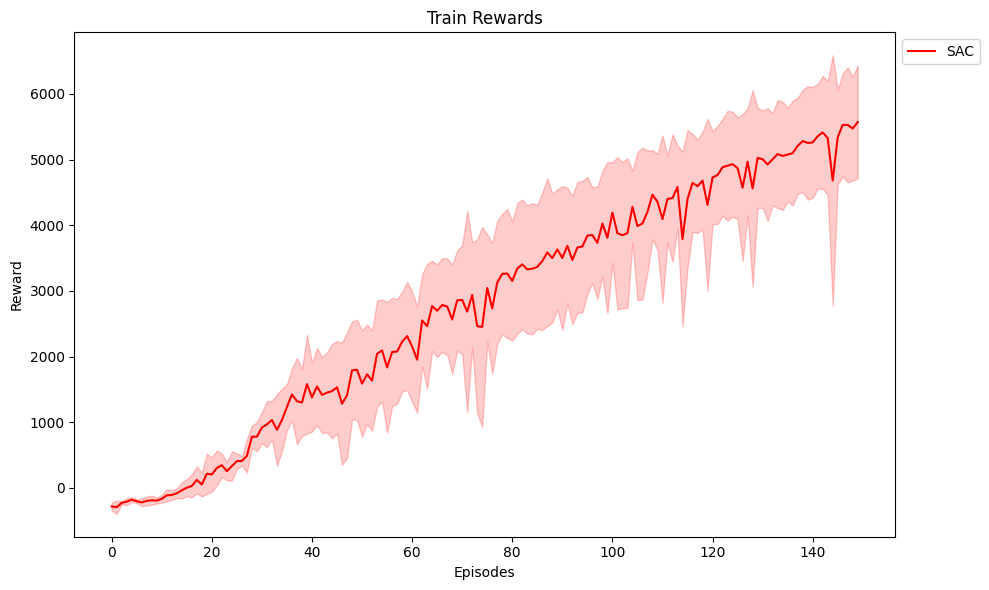

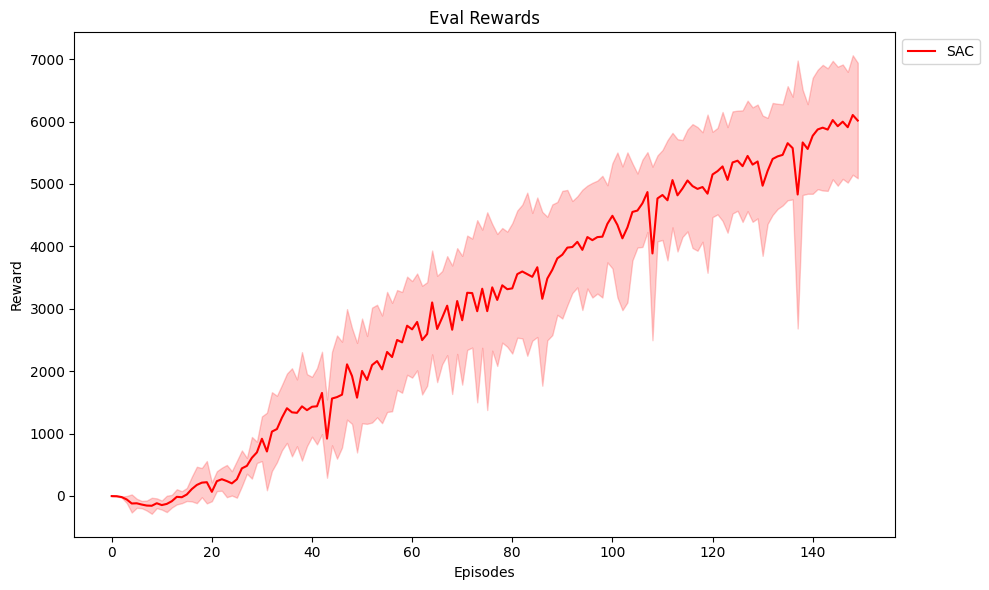

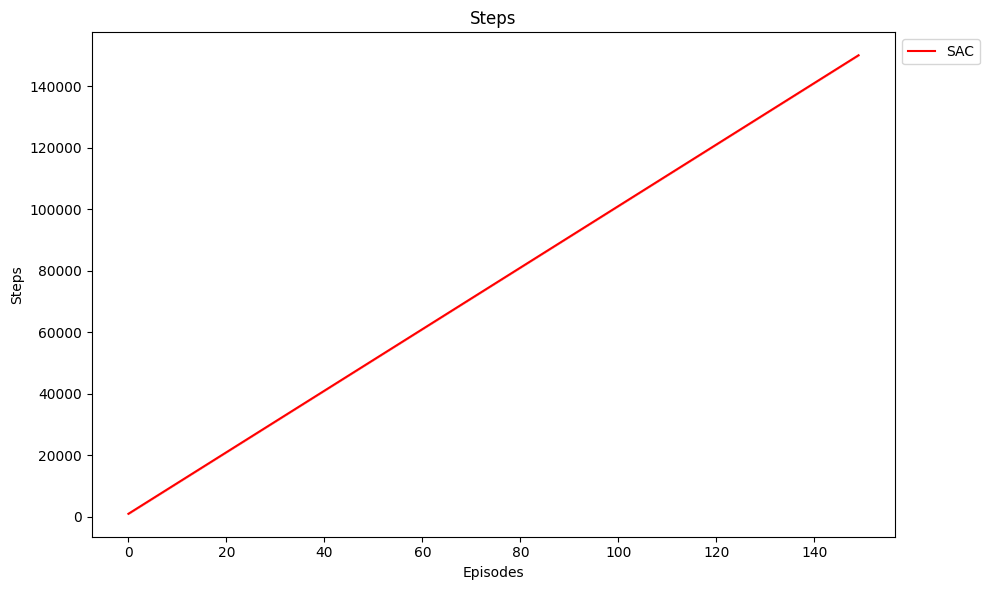

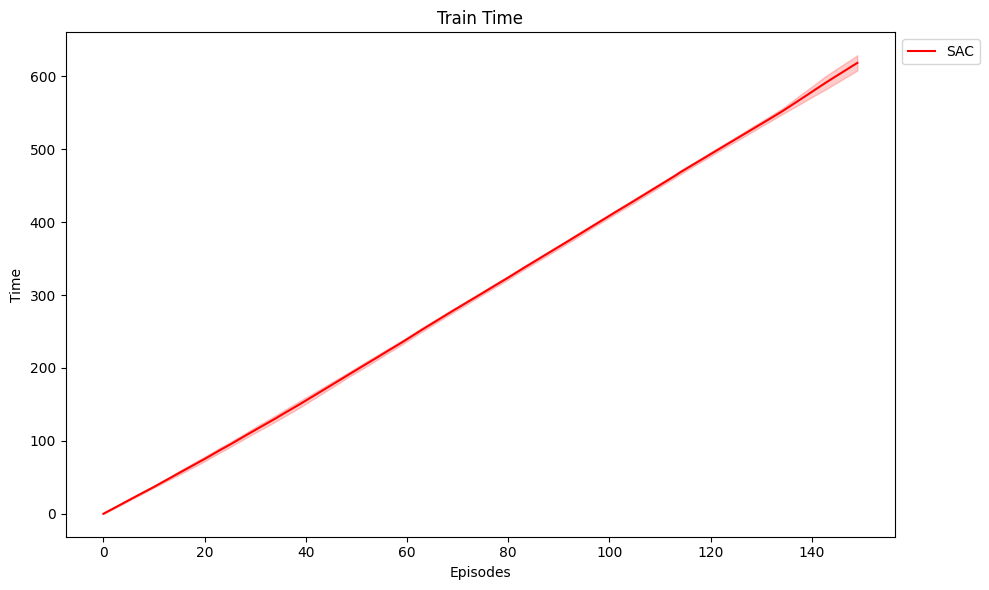

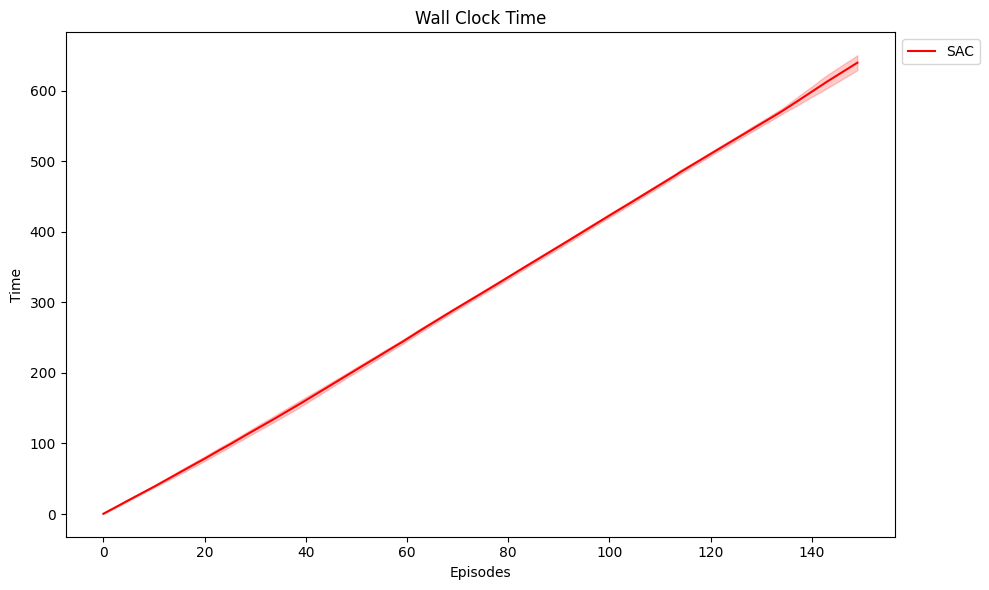

In [412]:
plotAgents(agent_results, keys=['SAC'], qty_idx=0, colors=['red'], title='Train Rewards', y_label='Reward')
plotAgents(agent_results, keys=['SAC'], qty_idx=1, colors=['red'], title='Eval Rewards', y_label='Reward')
plotAgents(agent_results, keys=['SAC'], qty_idx=2, colors=['red'], title='Steps', y_label='Steps')
plotAgents(agent_results, keys=['SAC'], qty_idx=3, colors=['red'], title='Train Time', y_label='Time')
plotAgents(agent_results, keys=['SAC'], qty_idx=4, colors=['red'], title='Wall Clock Time', y_label='Time')

## ANALYSIS
- Both mean train reward and mean eval reward show a clean upward trend, implying the model is learning
- Both mean train reward and mean eval reward have similar plots, implying the model neither underfits nor overfits.
- Train Time is significantly higher than other methods, this can be attributed to the multiple networks.
- Smooth improvement over episodes can be attributed to the exploration rewarding nature of SAC
- Stability is attributed to the twin network usage
- SAC is well-suited for continuous control tasks like HalfCheetah, and the graphs match that expectation.


## Plot all the graph across on Half Cheetah environment and write an analysis report.


# PPO [50 marks]
<a id="PPO"></a>

PPO have quite a few key implementation details.
Please Refer:
"Proximal Policy Optimization Algorithms" [PPO](https://arxiv.org/abs/1707.06347) and
"Implementation Matters in Deep RL: A Case Study on PPO and TRPO" [Implementation Matters](https://openreview.net/forum?id=r1etN1rtPB)

Lets finish things off with an easy implementation of PPO!
A easy way to check you implementation details is running your implementation on some easier environment first and make sure it converges.

In [476]:
#All imports here
## Feel free to add or remove

import os
import random
import time

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.categorical import Categorical

In [500]:
# PPO Hyperparameters (multiprocessing version)

ppo_gym_id = "HalfCheetah-v4"
ppo_learning_rate = 3e-4
ppo_seed = 101
ppo_total_timesteps = 1500000

ppo_num_workers = 4
ppo_num_steps = 256

ppo_gamma = 0.99
ppo_gae_lambda = 0.95

ppo_update_epochs = 10
ppo_num_minibatches = 4

ppo_clip_coef = 0.2
ppo_clip_vloss = True

ppo_ent_coef = 0.01
ppo_vf_coef = 0.5
ppo_max_grad_norm = 0.5

ppo_norm_adv = True
ppo_anneal_lr = True
ppo_target_kl = None

ppo_batch_size = ppo_num_workers * ppo_num_steps
ppo_minibatch_size = ppo_batch_size // ppo_num_minibatches

print(f"PPO: batch={ppo_batch_size}, minibatch={ppo_minibatch_size}")


PPO: batch=1024, minibatch=256


In [501]:
ppo_module_code = '''
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import gymnasium as gym
import time

def compute_gae(rewards, values, dones, next_value, gamma, gae_lambda):
    T = rewards.shape[0]
    advantages = torch.zeros_like(rewards)
    last_gae = torch.zeros_like(next_value)
    for t in reversed(range(T)):
        next_non_terminal = 1.0 - dones[t]
        next_val = next_value if t == T-1 else values[t+1]
        delta = rewards[t] + gamma * next_val * next_non_terminal - values[t]
        last_gae = delta + gamma * gae_lambda * next_non_terminal * last_gae
        advantages[t] = last_gae
    returns = advantages + values
    return advantages, returns

def evaluate_ppo_worker(agent, env_id, seed):
    env = gym.make(env_id)
    s, _ = env.reset(seed=seed)
    done = False
    tr = 0
    while not done:
        s_t = torch.FloatTensor(s).reshape(1, -1)
        with torch.no_grad():
            action, _, _, _ = agent.get_action_and_value(s_t)
        a = action.detach().cpu().numpy().reshape(-1)
        s, r, term, trunc, _ = env.step(a)
        done = term or trunc
        tr += r
    env.close()
    return tr

class PPOAgent(nn.Module):
    def __init__(self, obs_dim, act_dim, is_discrete=False,
                 action_high=None, action_low=None):
        super().__init__()
        self.is_discrete = is_discrete
        hDim = [64, 64]

        critic_layers = [nn.Linear(obs_dim, hDim[0]), nn.Tanh()]
        for i in range(len(hDim)-1):
            critic_layers += [nn.Linear(hDim[i], hDim[i+1]), nn.Tanh()]
        critic_layers += [nn.Linear(hDim[-1], 1)]
        self.critic = nn.Sequential(*critic_layers)

        actor_layers = [nn.Linear(obs_dim, hDim[0]), nn.Tanh()]
        for i in range(len(hDim)-1):
            actor_layers += [nn.Linear(hDim[i], hDim[i+1]), nn.Tanh()]
        if is_discrete:
            actor_layers += [nn.Linear(hDim[-1], act_dim)]
            self.actor = nn.Sequential(*actor_layers)
        else:
            actor_layers += [nn.Linear(hDim[-1], act_dim)]
            self.actor_mean = nn.Sequential(*actor_layers)
            self.actor_log_std = nn.Parameter(torch.zeros(1, act_dim))
            if action_high is not None:
                self.action_scale = torch.FloatTensor((action_high - action_low) / 2.0)
                self.action_bias = torch.FloatTensor((action_high + action_low) / 2.0)
            else:
                self.action_scale = torch.ones(act_dim)
                self.action_bias = torch.zeros(act_dim)

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        if self.is_discrete:
            logits = self.actor(x)
            dist = torch.distributions.Categorical(logits=logits)
            if action is None:
                action = dist.sample()
            return action, dist.log_prob(action), dist.entropy(), self.critic(x)
        else:
            mu = self.actor_mean(x)
            log_std = self.actor_log_std.expand_as(mu)
            std = torch.exp(log_std)
            dist = torch.distributions.Normal(mu, std)
            if action is None:
                action = dist.sample()
            log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)
            entropy = dist.entropy().sum(dim=-1, keepdim=True)
            return action, log_prob, entropy, self.critic(x)

def ppo_worker(worker_id, global_agent,
               env_id, seed, num_steps, num_updates,
               shared_obs, shared_actions, shared_logprobs,
               shared_rewards, shared_dones, shared_values,
               shared_next_obs, shared_next_done,
               collect_barrier, update_barrier, ep_queue):
    torch.manual_seed(seed + worker_id)
    env = gym.make(env_id)
    env.reset(seed=seed + worker_id)
    is_discrete = isinstance(env.action_space, gym.spaces.Discrete)

    s, _ = env.reset()
    done = False
    ep_reward = 0.0
    ep_steps = 0
    episode_count = 0
    total_steps = 0
    w_start = time.time()

    for update in range(num_updates):
        for step in range(num_steps):
            s_t = torch.FloatTensor(s).reshape(1, -1)
            with torch.no_grad():
                action, log_p, _, value = global_agent.get_action_and_value(s_t)
            a = action.detach().cpu().numpy().reshape(-1)
            s_next, r, term, trunc, _ = env.step(a)
            done = term or trunc
            ep_reward += r
            ep_steps += 1
            total_steps += 1

            shared_obs[worker_id, step] = torch.FloatTensor(s)
            shared_actions[worker_id, step] = action.squeeze(0).detach()
            shared_logprobs[worker_id, step] = log_p.squeeze().detach()
            shared_rewards[worker_id, step] = r
            shared_dones[worker_id, step] = float(done)
            shared_values[worker_id, step] = value.squeeze().detach()

            s = s_next
            if done:
                eval_reward = evaluate_ppo_worker(global_agent, env_id, seed + worker_id)
                w_end = time.time()
                episode_count += 1
                ep_queue.put((worker_id, episode_count, ep_reward, eval_reward,
                              total_steps, 0.0, w_end - w_start))
                if episode_count % 10 == 0:
                    print(f"Worker {worker_id} | Episode {episode_count} | "
                          f"Train Reward: {ep_reward:.2f} | Eval Reward: {eval_reward:.2f}")
                s, _ = env.reset()
                ep_reward = 0.0
                ep_steps = 0
                w_start = time.time()
                done = False

        shared_next_obs[worker_id] = torch.FloatTensor(s)
        shared_next_done[worker_id] = float(done)

        collect_barrier.wait()
        update_barrier.wait()

    env.close()
'''

with open('ppo_worker_module.py', 'w', encoding='utf-8') as f:
    f.write(ppo_module_code)
print("ppo_worker_module.py written to:", __import__('os').getcwd())

ppo_worker_module.py written to: /Users/aryanarora/Desktop/rl/assign5


In [502]:
from ppo_worker_module import PPOAgent, ppo_worker, compute_gae


In [503]:
def train_ppo(env_id=ppo_gym_id, seed=ppo_seed,
              total_timesteps=ppo_total_timesteps,
              num_workers=ppo_num_workers, num_steps=ppo_num_steps,
              lr=ppo_learning_rate, gamma=ppo_gamma,
              gae_lambda=ppo_gae_lambda, update_epochs=ppo_update_epochs,
              num_minibatches=ppo_num_minibatches,
              clip_coef=ppo_clip_coef, clip_vloss=ppo_clip_vloss,
              ent_coef=ppo_ent_coef, vf_coef=ppo_vf_coef,
              max_grad_norm=ppo_max_grad_norm, norm_adv=ppo_norm_adv,
              anneal_lr=ppo_anneal_lr, target_kl=ppo_target_kl):
    env=gym.make(env_id)
    is_discrete = isinstance(env.action_space, gym.spaces.Discrete)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n if is_discrete else env.action_space.shape[0]
    action_high = None if is_discrete else env.action_space.high
    action_low = None if is_discrete else env.action_space.low
    env.close()

    global_agent = PPOAgent(obs_dim, act_dim, is_discrete, action_high, action_low)
    global_agent.share_memory()
    optimizer = torch.optim.Adam(global_agent.parameters(), lr=lr, eps=1e-5)

    num_updates = total_timesteps // (num_workers * num_steps)
    batch_size = num_workers * num_steps
    minibatch_size = batch_size // num_minibatches

    shared_obs = torch.zeros(num_workers, num_steps, obs_dim).share_memory_()
    shared_actions = torch.zeros(num_workers, num_steps, act_dim).share_memory_()
    shared_logprobs = torch.zeros(num_workers, num_steps).share_memory_()
    shared_rewards = torch.zeros(num_workers, num_steps).share_memory_()
    shared_dones = torch.zeros(num_workers, num_steps).share_memory_()
    shared_values = torch.zeros(num_workers, num_steps).share_memory_()
    shared_next_obs = torch.zeros(num_workers, obs_dim).share_memory_()
    shared_next_done = torch.zeros(num_workers).share_memory_()

    collect_barrier = mp.Barrier(num_workers + 1)
    update_barrier = mp.Barrier(num_workers + 1)
    ep_queue = mp.Queue()

    workers = []
    for worker_id in range(num_workers):
        p = mp.Process(
            target=ppo_worker,
            args=(worker_id, global_agent,
                  env_id, seed, num_steps, num_updates,
                  shared_obs, shared_actions, shared_logprobs,
                  shared_rewards, shared_dones, shared_values,
                  shared_next_obs, shared_next_done,
                  collect_barrier, update_barrier, ep_queue)
        )
        p.start()
        workers.append(p)

    ep_rewards_buffer = {w: {"train": [], "eval": [], "steps": [], "train_time": [], "wall_time": []} for w in range(num_workers)}
    cumTrainTime = 0.0
    cumWallTime = 0.0
    totalSteps = 0

    for update in range(num_updates):
        w_start = time.time()

        if anneal_lr:
            frac = 1.0 - update / num_updates
            optimizer.param_groups[0]['lr'] = frac * lr

        collect_barrier.wait()

        t_start = time.time()

        obs_b = shared_obs.reshape(-1, obs_dim)
        actions_b = shared_actions.reshape(-1, act_dim)
        logps_b = shared_logprobs.reshape(-1)
        rewards_b = shared_rewards.reshape(-1)
        dones_b = shared_dones.reshape(-1)
        values_b = shared_values.reshape(-1)

        with torch.no_grad():
            next_values = global_agent.get_value(shared_next_obs).squeeze(-1)

        advantages, returns = compute_gae(
            shared_rewards.T,
            shared_values.T,
            shared_dones.T,
            next_values.unsqueeze(0),
            gamma, gae_lambda
        )
        advantages = advantages.T.reshape(-1)
        returns    = returns.T.reshape(-1)

        b_inds = np.arange(batch_size)
        for epoch in range(update_epochs):
            np.random.shuffle(b_inds)
            for start in range(0, batch_size, minibatch_size):
                end = start + minibatch_size
                mb_inds = b_inds[start:end]

                mb_obs = obs_b[mb_inds]
                mb_actions = actions_b[mb_inds]
                mb_logps = logps_b[mb_inds]
                mb_advs = advantages[mb_inds]
                mb_returns = returns[mb_inds]
                mb_values = values_b[mb_inds]

                if norm_adv:
                    mb_advs = (mb_advs - mb_advs.mean()) / (mb_advs.std() + 1e-8)

                _, new_logps, entropy, new_values = global_agent.get_action_and_value(mb_obs, mb_actions)
                new_logps = new_logps.squeeze()
                new_values = new_values.squeeze()
                entropy = entropy.squeeze()

                ratios = torch.exp(new_logps - mb_logps)
                pi = mb_advs * ratios
                pi_clipped = mb_advs * torch.clamp(ratios, 1.0 - clip_coef, 1.0 + clip_coef)
                pLoss = -torch.mean(torch.min(pi, pi_clipped))

                if clip_vloss:
                    vs_clipped = mb_values + torch.clamp(new_values - mb_values, -clip_coef, clip_coef)
                    vLoss_unclipped = (new_values - mb_returns)**2
                    vLoss_clipped = (vs_clipped - mb_returns)**2
                    vLoss = 0.5 * torch.mean(torch.max(vLoss_unclipped, vLoss_clipped))
                else:
                    vLoss = 0.5 * torch.mean((new_values - mb_returns)**2)

                entropyLoss = -torch.mean(entropy)
                totalLoss   = pLoss + vf_coef * vLoss + ent_coef * entropyLoss

                optimizer.zero_grad()
                totalLoss.backward()
                torch.nn.utils.clip_grad_norm_(global_agent.parameters(), max_grad_norm)
                optimizer.step()

            if target_kl is not None:
                with torch.no_grad():
                    _, new_logps_all, _, _ = global_agent.get_action_and_value(obs_b, actions_b)
                    kl = torch.mean(logps_b - new_logps_all.squeeze())
                    if kl > target_kl:
                        break

        t_end = time.time()
        cumTrainTime += t_end - t_start
        totalSteps   += num_workers * num_steps

        update_barrier.wait()

        w_end = time.time()
        cumWallTime += w_end - w_start

        while not ep_queue.empty():
            worker_id, ep_num, ep_r, eval_r, ep_steps, ep_tr_t, ep_w_t = ep_queue.get()
            d = ep_rewards_buffer[worker_id]
            d["train"].append(ep_r)
            d["eval"].append(eval_r)
            d["steps"].append(totalSteps)
            d["train_time"].append(cumTrainTime)
            d["wall_time"].append(cumWallTime)

    for p in workers:
        p.join()

    while not ep_queue.empty():
        worker_id, ep_num, ep_r, eval_r, ep_steps, ep_tr_t, ep_w_t = ep_queue.get()
        d = ep_rewards_buffer[worker_id]
        d["train"].append(ep_r)
        d["eval"].append(eval_r)
        d["steps"].append(totalSteps)
        d["train_time"].append(cumTrainTime)
        d["wall_time"].append(cumWallTime)

    return global_agent, ep_rewards_buffer

In [506]:
for run in range(5):
    print(f"Run {run+1} | Seed {ppo_seed+run}")
    ts = time.time()
    global_agent, ep_rewards_buffer = train_ppo(seed=ppo_seed+run)
    min_eps = min(len(ep_rewards_buffer[w]["train"]) for w in range(ppo_num_workers))
    trainRewardList = np.mean(np.array([ep_rewards_buffer[w]["train"][:min_eps] for w in range(ppo_num_workers)]), axis=0).tolist()
    evalRewardList  = np.mean(np.array([ep_rewards_buffer[w]["eval"][:min_eps] for w in range(ppo_num_workers)]), axis=0).tolist()
    stepList        = np.mean(np.array([ep_rewards_buffer[w]["steps"][:min_eps] for w in range(ppo_num_workers)]), axis=0).tolist()
    trainTimeList   = np.mean(np.array([ep_rewards_buffer[w]["train_time"][:min_eps] for w in range(ppo_num_workers)]), axis=0).tolist()
    wallTimeList    = np.mean(np.array([ep_rewards_buffer[w]["wall_time"][:min_eps] for w in range(ppo_num_workers)]), axis=0).tolist()
    agent_results["PPO"][run] = (trainRewardList, evalRewardList, stepList, trainTimeList, wallTimeList)
    te = time.time()
    print(f"Run {run+1} done, Time : {te-ts}")

Run 1 | Seed 101


/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/li

Worker 2 | Episode 10 | Train Reward: -477.17 | Eval Reward: -437.56
Worker 2 | Episode 20 | Train Reward: -444.75 | Eval Reward: -413.26
Worker 2 | Episode 30 | Train Reward: -377.67 | Eval Reward: -352.13
Worker 2 | Episode 40 | Train Reward: -157.43 | Eval Reward: -242.70
Worker 2 | Episode 50 | Train Reward: 125.72 | Eval Reward: 56.55
Worker 2 | Episode 60 | Train Reward: 119.49 | Eval Reward: 242.06
Worker 2 | Episode 70 | Train Reward: 231.32 | Eval Reward: 323.32
Worker 2 | Episode 80 | Train Reward: 423.63 | Eval Reward: 520.18
Worker 2 | Episode 90 | Train Reward: 597.16 | Eval Reward: 573.11
Worker 2 | Episode 100 | Train Reward: 579.53 | Eval Reward: 535.24
Worker 2 | Episode 110 | Train Reward: 734.02 | Eval Reward: 729.53
Worker 2 | Episode 120 | Train Reward: 762.24 | Eval Reward: 771.29
Worker 2 | Episode 130 | Train Reward: 846.50 | Eval Reward: 811.43
Worker 2 | Episode 140 | Train Reward: 842.43 | Eval Reward: 835.12
Worker 2 | Episode 150 | Train Reward: 812.29 | Ev

/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/li

Worker 2 | Episode 10 | Train Reward: -434.14 | Eval Reward: -612.51
Worker 2 | Episode 20 | Train Reward: -424.46 | Eval Reward: -447.27
Worker 2 | Episode 30 | Train Reward: -297.13 | Eval Reward: -360.85
Worker 2 | Episode 40 | Train Reward: -330.77 | Eval Reward: -138.48
Worker 2 | Episode 50 | Train Reward: 61.35 | Eval Reward: -100.38
Worker 2 | Episode 60 | Train Reward: 56.56 | Eval Reward: 117.86
Worker 2 | Episode 70 | Train Reward: 339.11 | Eval Reward: 493.68
Worker 2 | Episode 80 | Train Reward: 853.67 | Eval Reward: 404.80
Worker 2 | Episode 90 | Train Reward: 835.34 | Eval Reward: 549.91
Worker 2 | Episode 100 | Train Reward: 461.12 | Eval Reward: 1828.48
Worker 2 | Episode 110 | Train Reward: 1232.92 | Eval Reward: 555.82
Worker 2 | Episode 120 | Train Reward: 924.00 | Eval Reward: 708.02
Worker 2 | Episode 130 | Train Reward: 783.45 | Eval Reward: 704.98
Worker 2 | Episode 140 | Train Reward: 1116.44 | Eval Reward: 1759.79
Worker 2 | Episode 150 | Train Reward: 1551.24

...

Worker 1 | Episode 10 | Train Reward: -502.19 | Eval Reward: -541.75
Worker 1 | Episode 20 | Train Reward: -429.26 | Eval Reward: -431.73
Worker 1 | Episode 30 | Train Reward: -330.84 | Eval Reward: -322.00
Worker 1 | Episode 40 | Train Reward: -263.09 | Eval Reward: -178.73
Worker 1 | Episode 50 | Train Reward: -77.60 | Eval Reward: 9.48
Worker 1 | Episode 60 | Train Reward: 148.31 | Eval Reward: 262.56
Worker 1 | Episode 70 | Train Reward: 371.33 | Eval Reward: 437.74
Worker 1 | Episode 80 | Train Reward: 525.54 | Eval Reward: 349.85
Worker 1 | Episode 90 | Train Reward: 589.51 | Eval Reward: 442.25
Worker 1 | Episode 100 | Train Reward: -313.63 | Eval Reward: 691.13
Worker 1 | Episode 110 | Train Reward: 212.62 | Eval Reward: 681.90
Worker 1 | Episode 120 | Train Reward: 496.89 | Eval Reward: 420.02
Worker 1 | Episode 130 | Train Reward: 184.60 | Eval Reward: 471.44
Worker 1 | Episode 140 | Train Reward: 732.43 | Eval Reward: 657.42
Worker 1 | Episode 150 | Train Reward: 614.09 | Ev

/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/li

Worker 0 | Episode 10 | Train Reward: -536.70 | Eval Reward: -616.30
Worker 0 | Episode 20 | Train Reward: -441.16 | Eval Reward: -337.33
Worker 0 | Episode 30 | Train Reward: -311.02 | Eval Reward: -295.28
Worker 0 | Episode 40 | Train Reward: -292.31 | Eval Reward: -285.78
Worker 0 | Episode 50 | Train Reward: 60.54 | Eval Reward: 45.23
Worker 0 | Episode 60 | Train Reward: 136.42 | Eval Reward: 162.38
Worker 0 | Episode 70 | Train Reward: 452.47 | Eval Reward: 734.71
Worker 0 | Episode 80 | Train Reward: 633.25 | Eval Reward: 777.48
Worker 0 | Episode 90 | Train Reward: 908.35 | Eval Reward: 704.89
Worker 0 | Episode 100 | Train Reward: 1389.14 | Eval Reward: 1242.64
Worker 0 | Episode 110 | Train Reward: 1692.54 | Eval Reward: 1203.66
Worker 0 | Episode 120 | Train Reward: 1795.75 | Eval Reward: 2138.31
Worker 0 | Episode 130 | Train Reward: 498.41 | Eval Reward: 1028.96
Worker 0 | Episode 140 | Train Reward: 1490.84 | Eval Reward: 1089.22
Worker 0 | Episode 150 | Train Reward: 218

/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/Users/aryanarora/Desktop/rl/drl2/li

Worker 1 | Episode 10 | Train Reward: -555.01 | Eval Reward: -535.88
Worker 1 | Episode 20 | Train Reward: -411.80 | Eval Reward: -447.43
Worker 1 | Episode 30 | Train Reward: -240.44 | Eval Reward: -243.01
Worker 1 | Episode 40 | Train Reward: -62.67 | Eval Reward: 82.15
Worker 1 | Episode 50 | Train Reward: -21.69 | Eval Reward: 234.20
Worker 1 | Episode 60 | Train Reward: 62.44 | Eval Reward: -328.96
Worker 1 | Episode 70 | Train Reward: 305.02 | Eval Reward: 264.61
Worker 1 | Episode 80 | Train Reward: -49.69 | Eval Reward: 228.62
Worker 1 | Episode 90 | Train Reward: 601.44 | Eval Reward: 413.12
Worker 1 | Episode 100 | Train Reward: 884.81 | Eval Reward: 770.90
Worker 1 | Episode 110 | Train Reward: 863.45 | Eval Reward: 609.06
Worker 1 | Episode 120 | Train Reward: 1044.12 | Eval Reward: 1018.42
Worker 1 | Episode 130 | Train Reward: 1107.24 | Eval Reward: 1467.85
Worker 1 | Episode 140 | Train Reward: 638.70 | Eval Reward: 1403.27
Worker 1 | Episode 150 | Train Reward: 1019.25 

# Experiments and Plots [$20 \times 5=100$ marks]
<a id="experiments"></a>

Run the VPG, REINFORCE on Pendulum and DDPG, TD3, PPO, on Half Cheetah.

Plot the following for each of the environment separately. Note based on different hyper-parameters and strategies you use, you can have multiple plots for each of the below.

As you are aware from your past experience, single run of the agent over the environment results in plots that have lot of variance and look very noisy. One way to overcome this is to create several different instances of the environment using different seeds and then average out the results across these and plot these. For all the plots below, you this strategy. You need to run 5 different instances of the environment for each agent. As you have seen in the lecture slides, we plot the maximum and minimum values around the mean in the plots, so this gives us the shaded plot with the mean curve in the between. In this assignment, you are required to do the same. Generate plots with envelop between maximum and minimum value
For each of the quantity of interest, plot each of the agent within the same plot using different colors for the envelop. Choose colors such that that there is clear contrast between the plots corresponding to different agents.

1. Plot mean train rewards vs episodes
2. Plot mean evaluation rewards vs episodes
3. Plot total steps vs episode
4. Plot train time vs episode
5. Plot wall clock time vs episode
6. Based on plots what are your observations about DDPG and TD3, compare the two algorithms.
7. What is the advatage of PPO over DDPG or TD3?

In [392]:
env = gym.make(agents['REINFORCE']['env'])
agent = agents['REINFORCE']
seed = agent['seed']
for run in range(5):
    ts = time.time()
    rein = REINFORCE(env=env, seed=seed+run, gamma=agent['gamma'], optimizerFn=agent['optimizerFn'], optimizerLR=agent['optimizerLR'],
                     MAX_TRAIN_EPISODES=agent['MAX_TRAIN_EPISODES'], MAX_EVAL_EPISODES=agent['MAX_EVAL_EPISODES'], hDim=agent['hDim'], 
                     activation=agent['activation'])
    results = rein.runREINFORCE()
    agent_results['REINFORCE'][run] = results
    te = time.time()
    print(f"==========RUN: {run} completed, TIME : {te-ts}==========")

Episode: 10, Eval Reward: -1238.2246118992196, Train Reward: -1426.5889741214987
Episode: 20, Eval Reward: -1038.554223329501, Train Reward: -1444.2317507825778
Episode: 30, Eval Reward: -1839.2154884056988, Train Reward: -1774.6249142220615
Episode: 40, Eval Reward: -1585.921473000566, Train Reward: -1072.1340653477837
Episode: 50, Eval Reward: -1334.7257722835166, Train Reward: -1591.9152844257533
Episode: 60, Eval Reward: -1336.6217667876438, Train Reward: -1350.562863292434
Episode: 70, Eval Reward: -1529.3501546166963, Train Reward: -1165.5856736923006
Episode: 80, Eval Reward: -1750.3651358294933, Train Reward: -983.9776608757334
Episode: 90, Eval Reward: -1461.013061402972, Train Reward: -1111.1809796291132
Episode: 100, Eval Reward: -1665.109434522698, Train Reward: -1762.3539560262197
Episode: 110, Eval Reward: -1432.199562551754, Train Reward: -1454.1151885926377
Episode: 120, Eval Reward: -1747.4722868777524, Train Reward: -1006.1909008310236
Episode: 130, Eval Reward: -1918

In [391]:
env = gym.make(agents['VPG']['env'])
agent = agents['VPG']
seed = agent['seed']
for run in range(5):
    ts = time.time()
    vpg = VPG(env=env, seed=seed+run, gamma=agent['gamma'], beta = agent['beta'], optimizerFn=agent['optimizerFn'], optimizerLR=agent['optimizerLR'], 
              vOptimizerFn = agent['vOptimizerFn'], MAX_TRAIN_EPISODES=agent['MAX_TRAIN_EPISODES'], 
              MAX_EVAL_EPISODES=agent['MAX_EVAL_EPISODES'], hDim=agent['hDim'], activation=agent['activation'])
    results = vpg.runVPG()
    te = time.time()
    agent_results['VPG'][run] = results
    print(f"==========RUN: {run} completed, TIME : {te-ts}==========")

Episode: 10, Eval Reward: -1317.120403342437, Train Reward: -1269.2309295598552
Episode: 20, Eval Reward: -1298.7418768954487, Train Reward: -1521.1811985251734
Episode: 30, Eval Reward: -1858.589724221637, Train Reward: -1539.0266893973767
Episode: 40, Eval Reward: -1615.6088900520654, Train Reward: -1437.355085527713
Episode: 50, Eval Reward: -1405.3923853436397, Train Reward: -1551.6199009854788
Episode: 60, Eval Reward: -1214.4616971980004, Train Reward: -1590.2843647007426
Episode: 70, Eval Reward: -1494.1960866614374, Train Reward: -975.3324591414863
Episode: 80, Eval Reward: -1821.0078041446766, Train Reward: -1075.9204656539491
Episode: 90, Eval Reward: -1495.6980652564048, Train Reward: -1176.7798765786902
Episode: 100, Eval Reward: -1735.73372814489, Train Reward: -1566.3894566776526
Episode: 110, Eval Reward: -1466.5060842648713, Train Reward: -1390.7451039245918
Episode: 120, Eval Reward: -1778.549463355761, Train Reward: -1074.980985171333
Episode: 130, Eval Reward: -1894.

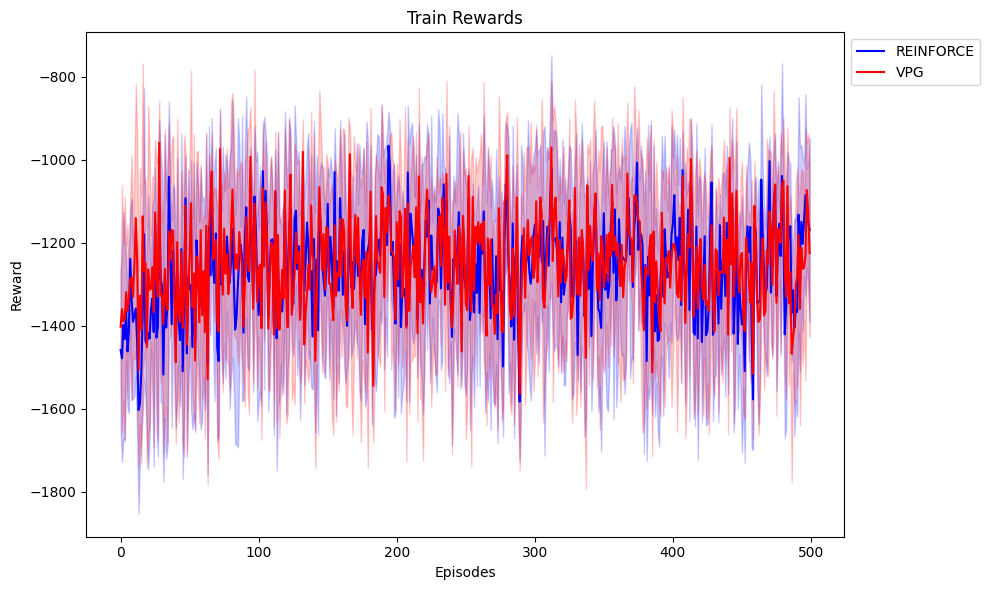

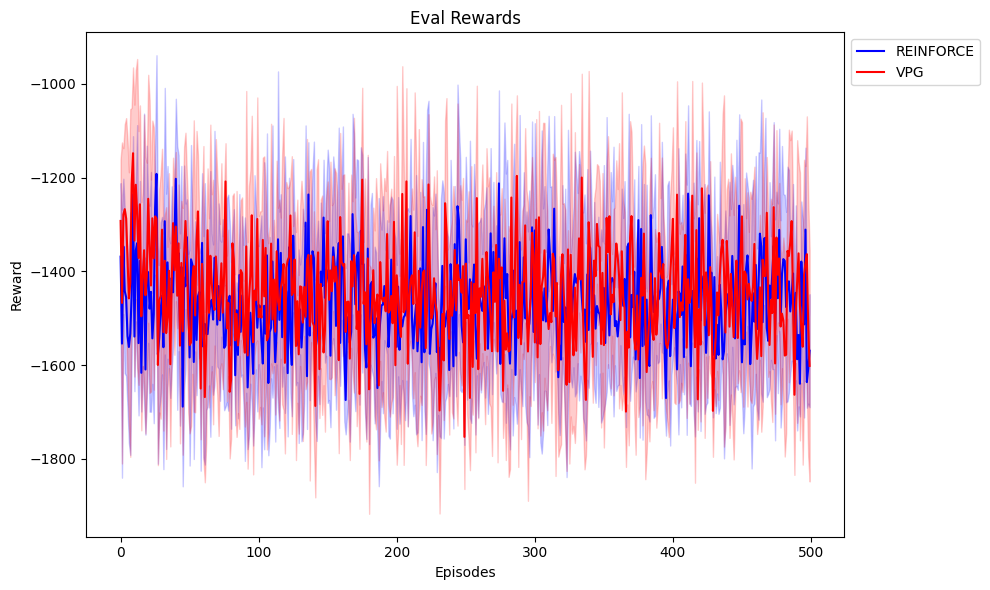

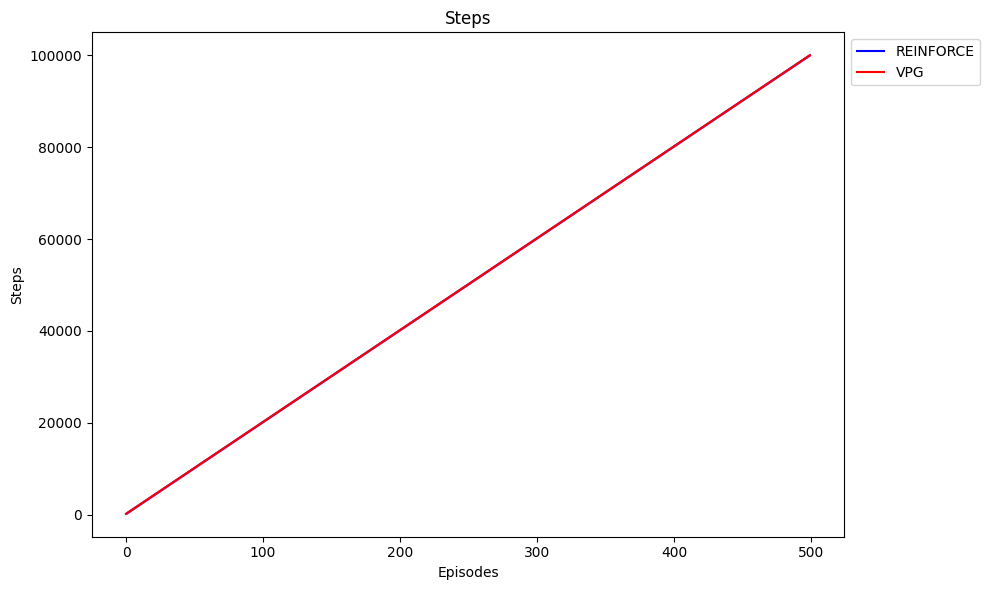

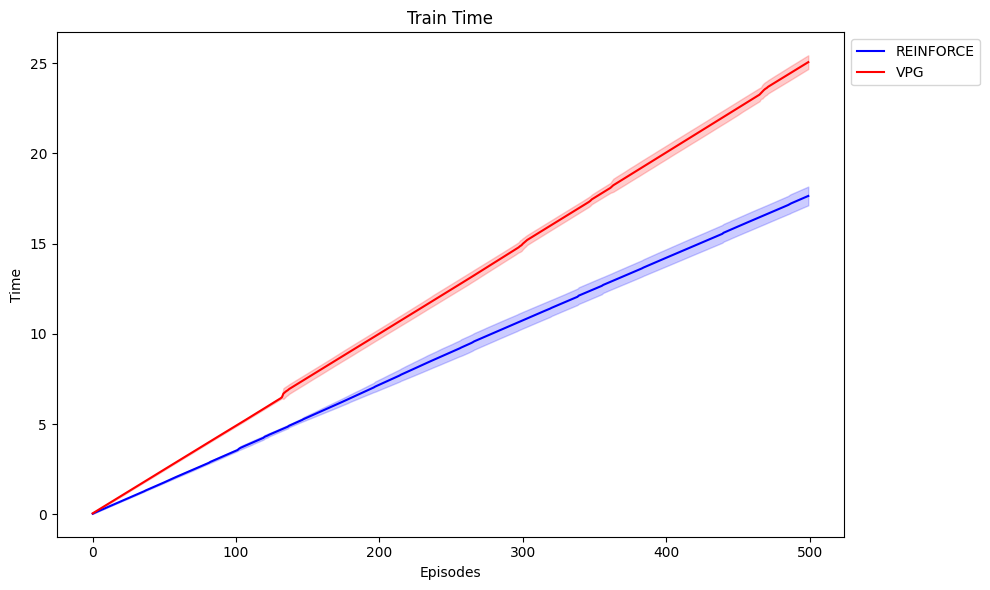

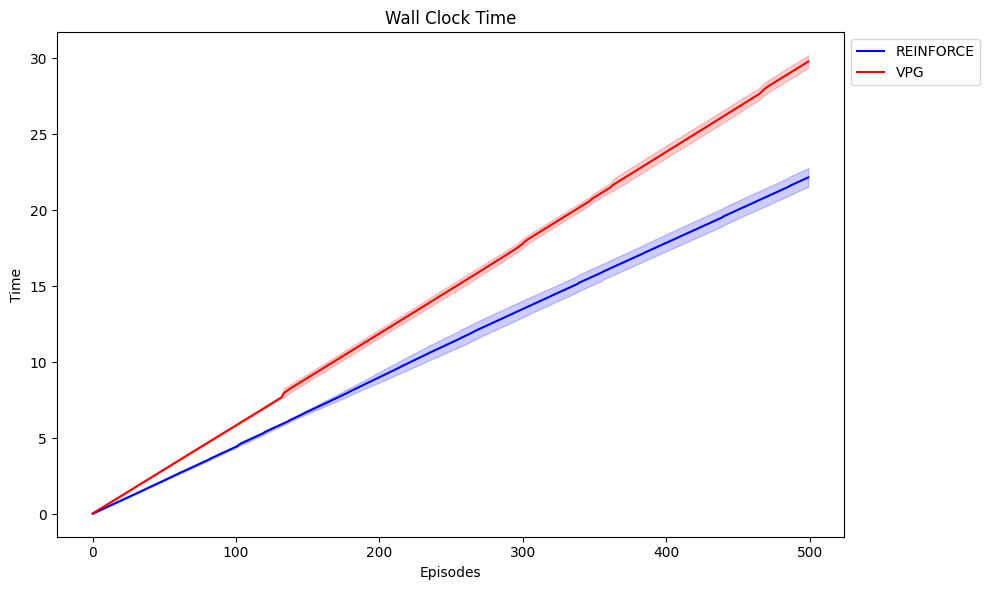

In [485]:
plotAgents(agent_results, keys=['REINFORCE', 'VPG'], qty_idx=0, colors=['blue', 'red'], title='Train Rewards', y_label='Reward')
plotAgents(agent_results, keys=['REINFORCE', 'VPG'], qty_idx=1, colors=['blue', 'red'], title='Eval Rewards', y_label='Reward')
plotAgents(agent_results, keys=['REINFORCE', 'VPG'], qty_idx=2, colors=['blue', 'red'], title='Steps', y_label='Steps')
plotAgents(agent_results, keys=['REINFORCE', 'VPG'], qty_idx=3, colors=['blue', 'red'], title='Train Time', y_label='Time')
plotAgents(agent_results, keys=['REINFORCE', 'VPG'], qty_idx=4, colors=['blue', 'red'], title='Wall Clock Time', y_label='Time')

In [498]:
env = gym.make(agents['DDPG']['env'])
agent = agents['DDPG']
seed = agent['seed']
noiseScaleRatio = agent['noiseScaleRatio']
minSamples = agent['minSamples']
for run in range(5):
    ts = time.time()
    ddpg = DDPG(env=env, seed=seed+run, gamma=agent['gamma'], tau=agent['tau'], bufferSize=agent['bufferSize'], 
                batch_size=agent['batch_size'], updateFrequency=agent['updateFrequency'],policyOptimizerFn=agent['policyOptimizerFn'],
                valueOptimizerFn=agent['valueOptimizerFn'], policyOptimizerLR=agent['policyOptimizerLR'], 
                valueOptimizerLR=agent['valueOptimizerLR'], MAX_TRAIN_EPISODES=agent['MAX_TRAIN_EPISODES'],
                MAX_EVAL_EPISODES=agent['MAX_EVAL_EPISODES'], hDim=agent['hDim'], activation=agent['activation'])
    results = ddpg.runDDPG()
    agent_results['DDPG'][run] = results
    te = time.time()
    print(f"Run {run} done, Time: {te - ts}")

Episode: 10, Eval Reward: -2.8828994511677735, Train Reward: 92.87673672125548
Episode: 20, Eval Reward: 832.8713479685865, Train Reward: 535.7003818435244
Episode: 30, Eval Reward: 967.7626155574765, Train Reward: 812.419261022232
Episode: 40, Eval Reward: 276.88419578721425, Train Reward: 88.47727820747028
Episode: 50, Eval Reward: 1036.374601344155, Train Reward: 1085.24355475855
Episode: 60, Eval Reward: 1286.8520322075992, Train Reward: 1305.6721273393832
Episode: 70, Eval Reward: 1411.1267315054474, Train Reward: 1328.1989226614892
Episode: 80, Eval Reward: 1336.5593400022915, Train Reward: 1366.273611659466
Episode: 90, Eval Reward: 1465.7502254272445, Train Reward: 1356.2599211624579
Episode: 100, Eval Reward: 1384.3184873193102, Train Reward: 1388.148631950664
Episode: 110, Eval Reward: 1435.046791513188, Train Reward: 1326.1120090592306
Episode: 120, Eval Reward: 1498.4203870873496, Train Reward: 1361.8166488748052
Episode: 130, Eval Reward: 1275.911119218451, Train Reward: 1

In [390]:
env = gym.make(agents['TD3']['env'])
agent = agents['TD3']
seed = agent['seed']
noiseScaleRatio = agent['noiseScaleRatio']
minSamples = agent['minSamples']
batch_size = agent['batch_size']
agent_results['TD3'] = {}
for run in range(5):
    t_s = time.time()
    td3 = TD3(env=env, gamma=agent['gamma'], tau=agent['tau'], bufferSize=agent['bufferSize'], batch_size=agent['batch_size'], 
              updateFrequencyPolicy=agent['updateFrequencyPolicy'], updateFrequencyValue=agent['updateFrequencyValue'], 
              trainPolicyFrequency=agent['trainPolicyFrequency'], policyOptimizerFn=agent['policyOptimizerFn'],
              valueOptimizerFn=agent['valueOptimizerFn'], policyOptimizerLR=agent['policyOptimizerLR'],
              valueOptimizerLR=agent['valueOptimizerLR'], MAX_TRAIN_EPISODES=agent['MAX_TRAIN_EPISODES'],
              MAX_EVAL_EPISODE=agent['MAX_EVAL_EPISODE'], hDim=agent['hDim'], activation=agent['activation'])
    results = td3.runTD3()
    agent_results['TD3'][run] = results
    t_e = time.time()
    print(f"TD3 RUN:  {run} completed, TIME: {t_e - t_s}")

Episode: 10, EVAL_REWARD: -245.17986516433098, TRAIN_REWARD: -247.40474763203278
Episode: 20, EVAL_REWARD: 222.49305896974477, TRAIN_REWARD: 236.08044246873507
Episode: 30, EVAL_REWARD: 686.4471582241749, TRAIN_REWARD: 89.80516153378589
Episode: 40, EVAL_REWARD: 825.465966282851, TRAIN_REWARD: 741.941014433691
Episode: 50, EVAL_REWARD: 879.8169981549581, TRAIN_REWARD: 288.8753856416332
Episode: 60, EVAL_REWARD: 592.9018869241879, TRAIN_REWARD: 661.761968853277
Episode: 70, EVAL_REWARD: 634.0876015077179, TRAIN_REWARD: 664.4406415602348
Episode: 80, EVAL_REWARD: 1201.4447221721352, TRAIN_REWARD: 1046.8704007796857
Episode: 90, EVAL_REWARD: 1161.7482372126908, TRAIN_REWARD: 1081.2417912633412
Episode: 100, EVAL_REWARD: 1211.719266775243, TRAIN_REWARD: 1155.6861887414545
Episode: 110, EVAL_REWARD: -666.1115107071507, TRAIN_REWARD: 1137.7124551350123
Episode: 120, EVAL_REWARD: 1261.1158166262348, TRAIN_REWARD: 1075.5166205262826
Episode: 130, EVAL_REWARD: 1052.6113121515584, TRAIN_REWARD: 

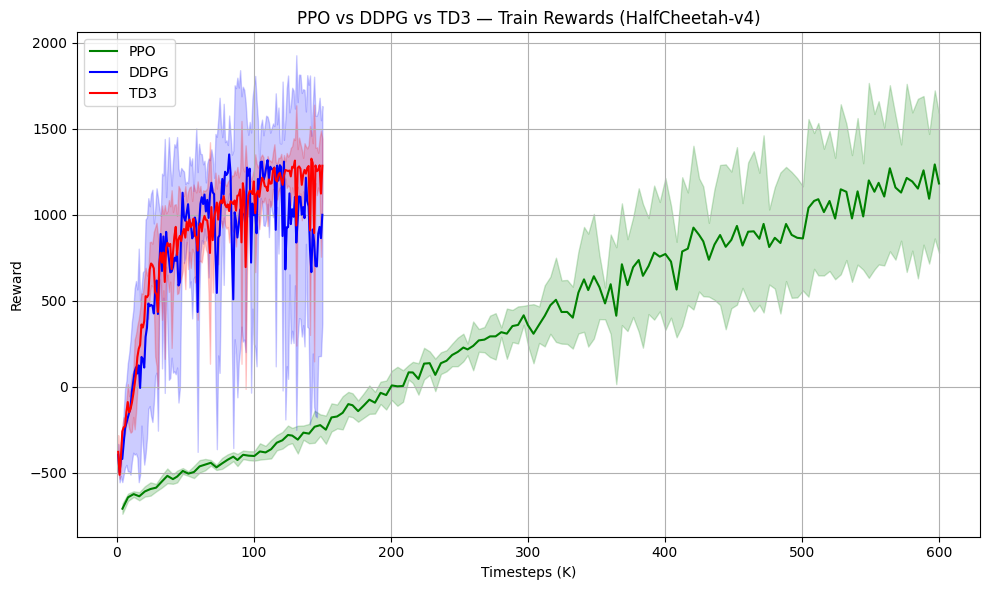

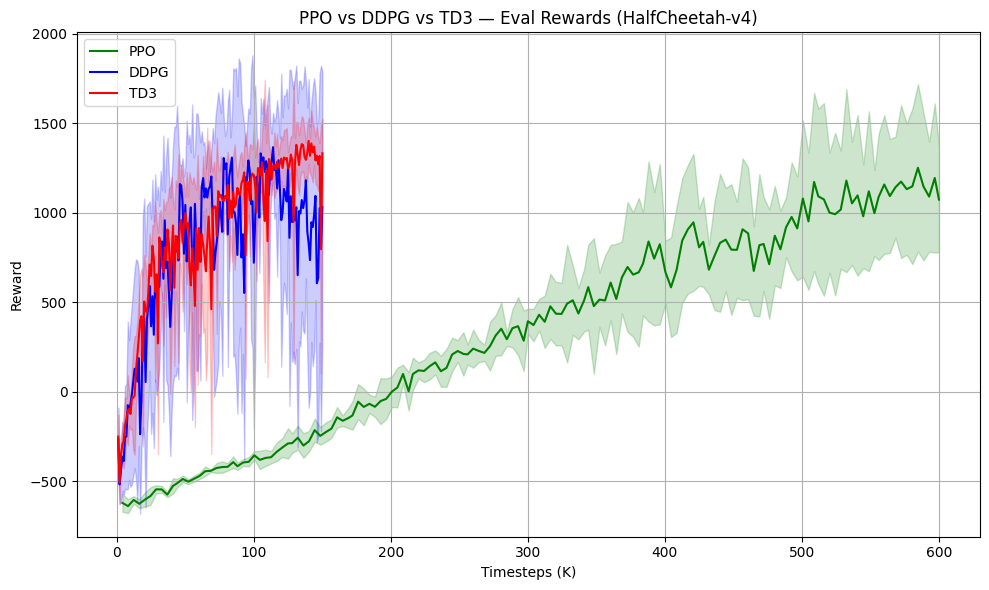

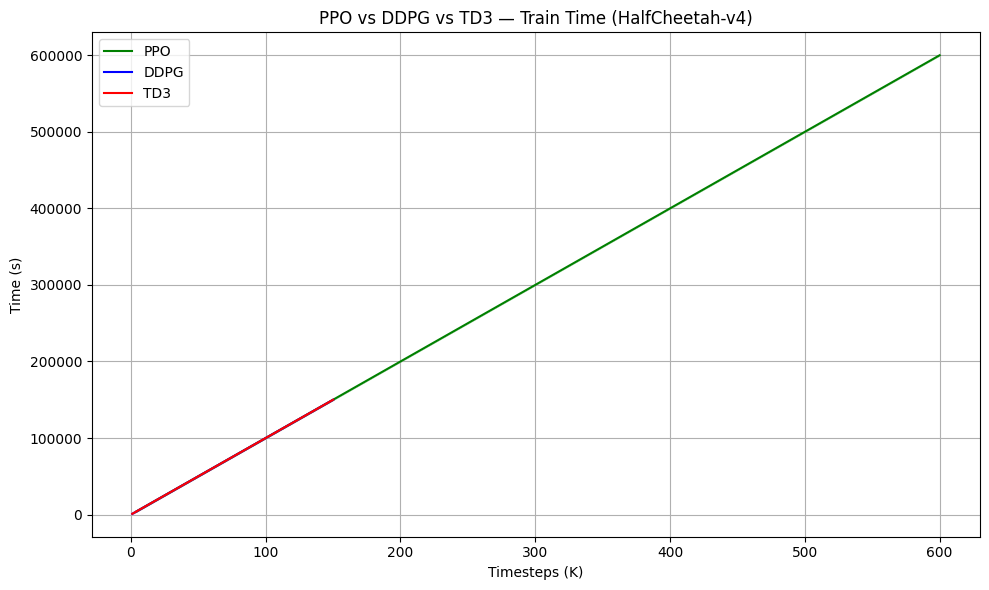

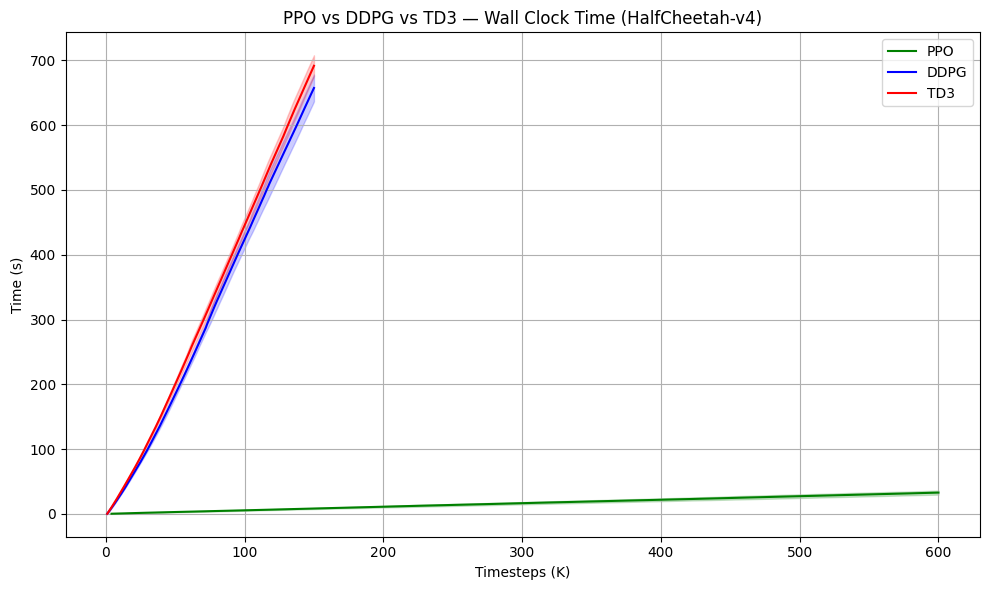

In [510]:
for qty_idx, (title, ylabel) in enumerate([
    ('Train Rewards (HalfCheetah-v4)', 'Reward'),
    ('Eval Rewards (HalfCheetah-v4)', 'Reward'),
    ('Train Time (HalfCheetah-v4)', 'Time (s)'),
    ('Wall Clock Time (HalfCheetah-v4)', 'Time (s)')
]):
    fig, ax = plt.subplots(figsize=(10, 6))
    min_eps_global = min(
        min(len(agent_results[key][run][qty_idx]) for run in range(len(agent_results[key])))
        for key in ['PPO', 'DDPG', 'TD3'] if len(agent_results[key]) > 0
    )
    for key, color in [('PPO', 'green'), ('DDPG', 'blue'), ('TD3', 'red')]:
        if len(agent_results[key]) == 0:
            continue
        min_len = min(
            min(len(agent_results[key][run][qty_idx]) for run in range(len(agent_results[key]))),
            min(len(agent_results[key][run][2]) for run in range(len(agent_results[key]))),
            min_eps_global
        )
        raw = np.array([agent_results[key][run][qty_idx][:min_len] for run in range(len(agent_results[key]))])
        steps = np.mean(np.array([agent_results[key][run][2][:min_len] for run in range(len(agent_results[key]))]), axis=0) / 1000
        mean_raw = raw.mean(axis=0)
        std_raw = raw.std(axis=0)
        ax.plot(steps, mean_raw, color=color, label=key)
        ax.fill_between(steps, mean_raw - std_raw, mean_raw + std_raw, alpha=0.2, color=color)
    ax.set_title(f'PPO vs DDPG vs TD3 — {title}')
    ax.set_xlabel('Timesteps (K)')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

In [531]:
torch.save(agent_results, 'agent_results.pt')

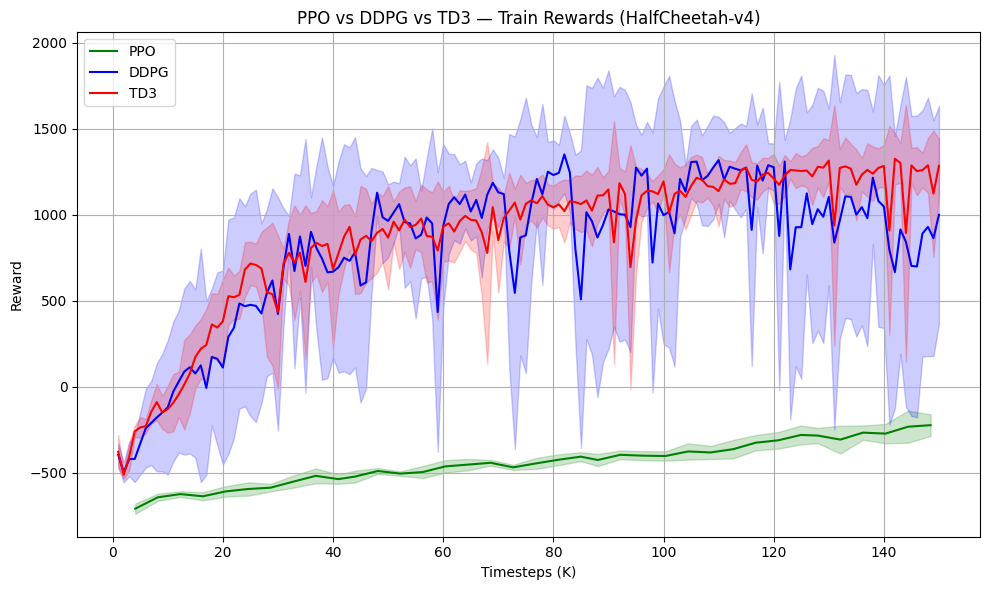

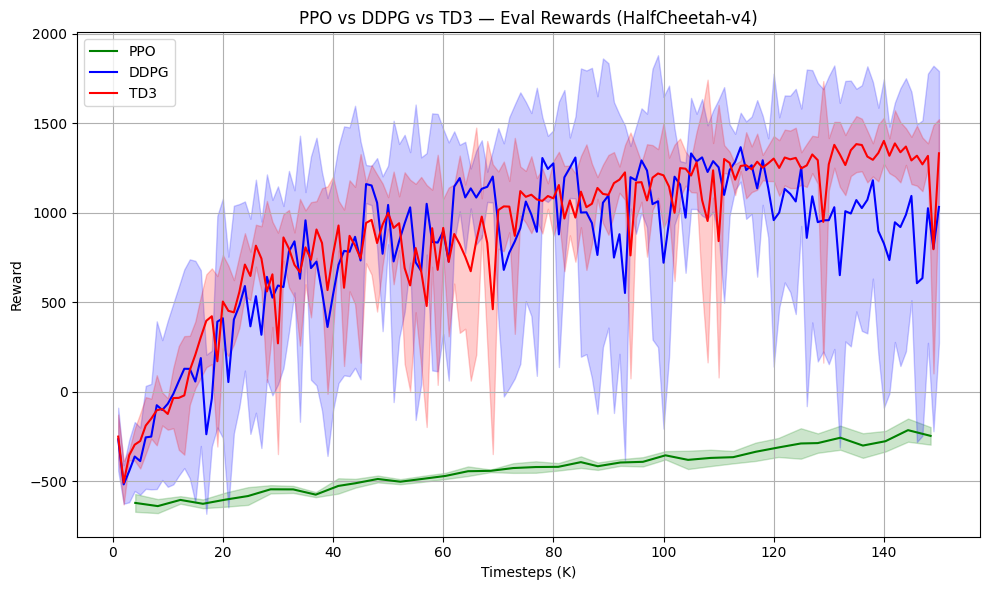

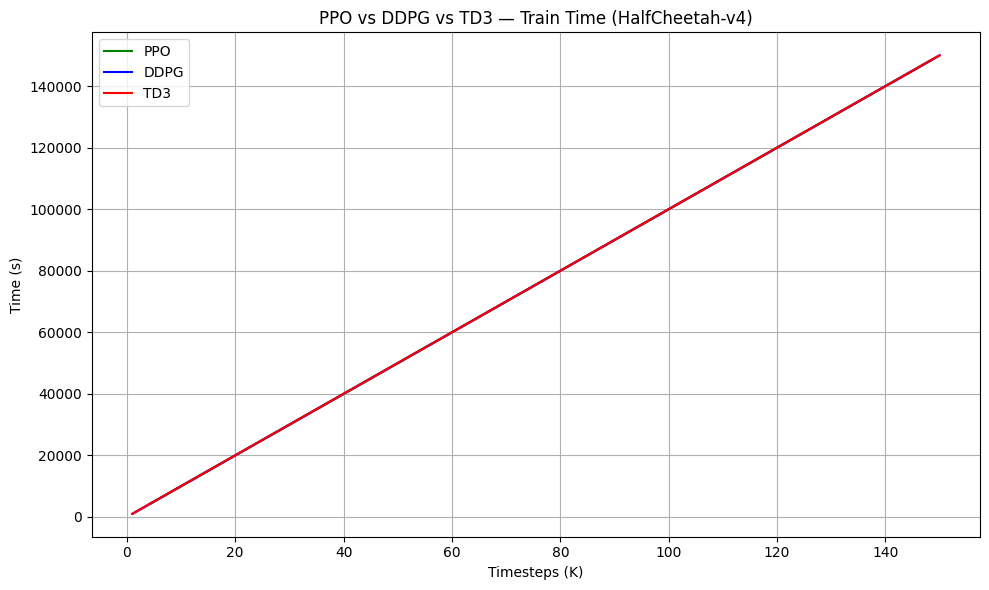

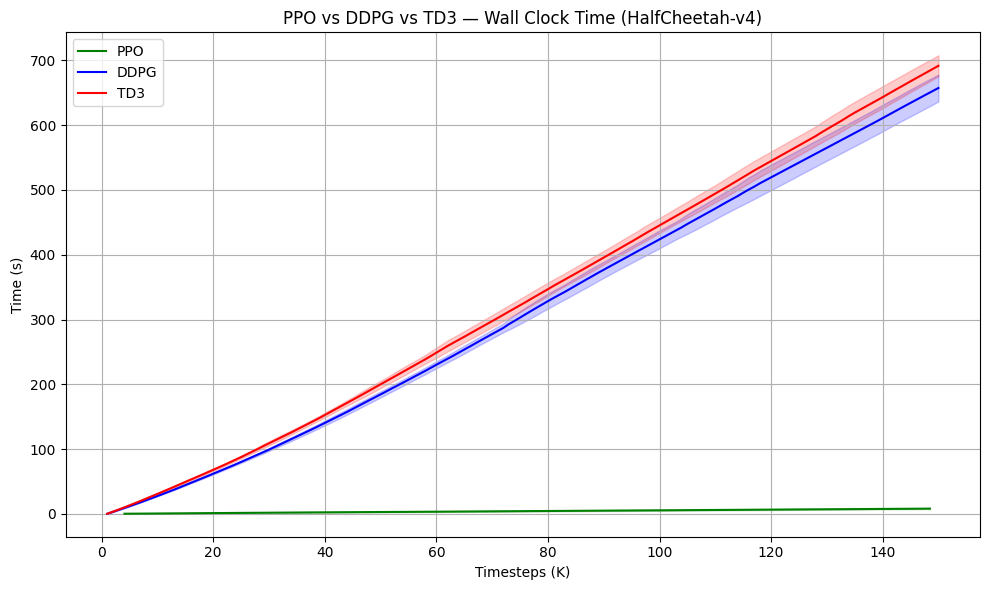

In [511]:
STEP_CUTOFF = 150000

for qty_idx, (title, ylabel) in enumerate([
    ('Train Rewards (HalfCheetah-v4)', 'Reward'),
    ('Eval Rewards (HalfCheetah-v4)', 'Reward'),
    ('Train Time (HalfCheetah-v4)', 'Time (s)'),
    ('Wall Clock Time (HalfCheetah-v4)', 'Time (s)')
]):
    fig, ax = plt.subplots(figsize=(10, 6))
    for key, color in [('PPO', 'green'), ('DDPG', 'blue'), ('TD3', 'red')]:
        if len(agent_results[key]) == 0:
            continue
        raw_list, steps_list = [], []
        for run in range(len(agent_results[key])):
            steps_run = np.array(agent_results[key][run][2])
            qty_run = np.array(agent_results[key][run][qty_idx])
            mask = steps_run <= STEP_CUTOFF
            steps_list.append(steps_run[mask])
            raw_list.append(qty_run[mask])
        min_len = min(len(r) for r in raw_list)
        raw = np.array([r[:min_len] for r in raw_list])
        steps = np.mean(np.array([s[:min_len] for s in steps_list]), axis=0) / 1000
        mean_raw = raw.mean(axis=0)
        std_raw = raw.std(axis=0)
        ax.plot(steps, mean_raw, color=color, label=key)
        ax.fill_between(steps, mean_raw - std_raw, mean_raw + std_raw, alpha=0.2, color=color)
    ax.set_title(f'PPO vs DDPG vs TD3 — {title}')
    ax.set_xlabel('Timesteps (K)')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## ANALYTICAL QUESTIONS
- DDPG and TD3:
  - DDPG has higher variance than TD3, which is consistent with theory. Since TD3 was an improvement upon DDPG's instability, the variance clearly reflects that
  - It is also important to note that stability comes at cost of additional wall clock time, due to the twin network usage by TD3
  - TD3 is more robust due to the delayed updates.
- PPO vs DDPG and TD3:
  - As it can be seen in the earlier extended version of the graph PPO requires more steps in comparison to TD3 and DDPG
  - Thus PPO is less sample efficient in comparison.
  - It is also important to note the advantage, even though it requires more steps, it requires drastically less wall time, thus making it faster.
  - The extended version also reached higher rewards for approximately same amount of time.
  - Being an on policy , gradient method, PPO is much faster to tune and more stable than other two. 